<a href="https://colab.research.google.com/github/bsenursahin/QAFS/blob/master/mBERT%26XLM_R%26BERTurk.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q transformers[sentencepiece] datasets scikit-learn accelerate seaborn openpyxl

In [ ]:

import re
import numpy as np
import pandas as pd
from datasets import load_dataset
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42

LABEL_MAP_3 = {
    'Negative': 0, 'negative': 0, 'Olumsuz': 0, 'olumsuz': 0,
    'Neutral': 1, 'neutral': 1, 'Nötr': 1, 'nötr': 1, 'Notr': 1, 'notr': 1,
    'Positive': 2, 'positive': 2, 'Olumlu': 2, 'olumlu': 2,
    0: 0, 1: 1, 2: 2,
}

NAMES_3 = ['Negatif', 'Nötr', 'Pozitif']
GOLDEN_PATH = '/content/golden_dataset.xlsx'


# ─────────────────────────────────────────────────────────────────────────────
# TEXT CLEANING
# ─────────────────────────────────────────────────────────────────────────────
def normalize_text(text):
    text = str(text)
    text = text.replace('\u200b', ' ')
    text = text.replace('\xa0', ' ')
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def is_bad_text(text):
    if text is None:
        return True

    t = normalize_text(text)

    if t == '':
        return True
    if t.lower() in {'nan', 'none', 'null'}:
        return True
    if len(t) < 3:
        return True

    # sadece sayı / noktalama / sembol
    if re.fullmatch(r'[\d\W_]+', t):
        return True

    # çok anlamsız sentetik örnekleri ele
    if t.lower().startswith('lorem ipsum'):
        return True

    return False

def make_text_norm(series):
    return (
        series.astype(str)
        .str.lower()
        .str.replace(r'\s+', ' ', regex=True)
        .str.strip()
    )


# ─────────────────────────────────────────────────────────────────────────────
# DATA AUDIT
# ─────────────────────────────────────────────────────────────────────────────
def audit_dataset(df, name):
    print(f'\n{"="*70}')
    print(f'AUDIT | {name}')
    print(f'{"="*70}')
    print(f'Toplam: {len(df)}')
    print(f'Dağılım: {df["label"].value_counts().sort_index().to_dict()}')

    dup_count = df["text_norm"].duplicated().sum()
    print(f'Exact duplicate text: {dup_count}')

    conflict = (
        df.groupby("text_norm")["label"]
        .nunique()
        .reset_index(name="n_labels")
    )
    conflict = conflict[conflict["n_labels"] > 1]
    print(f'Conflicting duplicate text: {len(conflict)}')

    if len(conflict) > 0:
        conflict_keys = set(conflict["text_norm"].tolist())
        flagged = df[df["text_norm"].isin(conflict_keys)].copy()
        flagged.to_csv(f'flagged_conflicts_{name.lower()}.csv', index=False, encoding='utf-8-sig')
        print(f'Kaydedildi: flagged_conflicts_{name.lower()}.csv')


def clean_standard_df(df, text_col, label_col, source_name, drop_conflicts=True):
    df = df.copy()

    df[text_col] = df[text_col].astype(str).map(normalize_text)
    df = df[~df[text_col].map(is_bad_text)].copy()

    df[label_col] = df[label_col].map(LABEL_MAP_3)
    df = df.dropna(subset=[label_col]).copy()
    df[label_col] = df[label_col].astype(int)

    df = df.rename(columns={text_col: 'text', label_col: 'label'})
    df['source'] = source_name
    df['text_norm'] = make_text_norm(df['text'])

    # same text + same label duplicates
    df = df.drop_duplicates(subset=['text_norm', 'label']).reset_index(drop=True)

    # same text + different label conflicts
    if drop_conflicts:
        label_counts = df.groupby('text_norm')['label'].nunique()
        conflict_keys = set(label_counts[label_counts > 1].index)

        if conflict_keys:
            conflict_df = df[df['text_norm'].isin(conflict_keys)].copy()
            conflict_df.to_csv(
                f'flagged_conflicts_{source_name.lower()}.csv',
                index=False,
                encoding='utf-8-sig'
            )
            print(f'{source_name}: conflicting texts removed = {len(conflict_df)}')
            print(f'Kaydedildi: flagged_conflicts_{source_name.lower()}.csv')

            df = df[~df['text_norm'].isin(conflict_keys)].copy()

    return df[['text', 'label', 'source', 'text_norm']].reset_index(drop=True)


# ─────────────────────────────────────────────────────────────────────────────
# LOADERS
# ─────────────────────────────────────────────────────────────────────────────
def load_golden(path):
    df = pd.read_excel(path)
    df.columns = df.columns.str.strip()

    required = {'Review', 'Sentiment'}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f'Golden dataset eksik sütunlar: {missing}')

    df = clean_standard_df(
        df=df,
        text_col='Review',
        label_col='Sentiment',
        source_name='golden'
    )

    print(f'Golden yüklendi: {len(df)} örnek | dağılım: {df["label"].value_counts().sort_index().to_dict()}')
    return df


def load_trsa(sample_per_class=20000):
    print(f'TRSAv1 yükleniyor (her sınıftan en fazla {sample_per_class} örnek)...')
    ds = load_dataset('maydogan/Turkish_SentimentAnalysis_TRSAv1', split='train')
    df = ds.to_pandas()

    print(f'TRSAv1 sütunlar: {df.columns.tolist()}')

    required = {'review', 'score'}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f'TRSAv1 beklenen sütunlar yok: {missing}')

    df = clean_standard_df(
        df=df,
        text_col='review',   # DOĞRU METİN SÜTUNU
        label_col='score',   # DOĞRU LABEL SÜTUNU
        source_name='trsa'
    )

    # dengeli örnekleme
    if sample_per_class is not None:
        df = (
            df.groupby('label', group_keys=False)
              .apply(lambda x: x.sample(min(len(x), sample_per_class), random_state=RANDOM_STATE))
              .reset_index(drop=True)
        )

    print(f'TRSAv1 yüklendi: {len(df)} örnek | dağılım: {df["label"].value_counts().sort_index().to_dict()}')
    return df


# ─────────────────────────────────────────────────────────────────────────────
# MERGE + FINAL CLEAN
# ─────────────────────────────────────────────────────────────────────────────
def remove_cross_source_duplicates(df):
    """
    Aynı text hem golden hem TRSA içinde varsa tekilleştir.
    Öncelik: golden kalsın.
    """
    df = df.copy()

    df['source_priority'] = df['source'].map({'golden': 0, 'trsa': 1}).fillna(9)
    df = df.sort_values(['text_norm', 'source_priority']).reset_index(drop=True)

    before = len(df)
    df = df.drop_duplicates(subset=['text_norm'], keep='first').reset_index(drop=True)
    after = len(df)

    print(f'Cross-source duplicate temizliği: {before - after} satır silindi.')
    return df.drop(columns=['source_priority'])


def build_sentiment_dataset(golden_path, sample_per_class=20000, test_size=0.2):
    print('\n--- Veri yükleniyor ---')
    df_golden = load_golden(golden_path)
    df_trsa   = load_trsa(sample_per_class=sample_per_class)

    audit_dataset(df_golden, 'GOLDEN')
    audit_dataset(df_trsa, 'TRSA')

    df_combined = pd.concat([df_golden, df_trsa], ignore_index=True)
    df_combined = remove_cross_source_duplicates(df_combined)

    print(f'\nBirleşik veri: {len(df_combined)} örnek')
    print(f'Dağılım: {df_combined["label"].value_counts().sort_index().to_dict()}')
    print(f'Kaynak: {df_combined["source"].value_counts().to_dict()}')

    df_train, df_test = train_test_split(
        df_combined,
        test_size=test_size,
        random_state=RANDOM_STATE,
        stratify=df_combined['label']
    )

    # leakage kontrolü
    overlap = set(df_train['text_norm']) & set(df_test['text_norm'])
    print(f'\nSplit → Train: {len(df_train)} | Test: {len(df_test)}')
    if overlap:
        print(f'⚠️ Leakage var: {len(overlap)} ortak text')
    else:
        print('✅ Data leakage yok.')

    # helper sütunlar dışarı alınır
    df_train = df_train.drop(columns=['text_norm']).reset_index(drop=True)
    df_test  = df_test.drop(columns=['text_norm']).reset_index(drop=True)

    # local save
    df_train.to_csv('sentiment_train_clean.csv', index=False, encoding='utf-8-sig')
    df_test.to_csv('sentiment_test_clean.csv', index=False, encoding='utf-8-sig')
    print('Kaydedildi: sentiment_train_clean.csv, sentiment_test_clean.csv')

    return df_train, df_test


# ─────────────────────────────────────────────────────────────────────────────
# RUN
# ─────────────────────────────────────────────────────────────────────────────
df_train_3, df_test_3 = build_sentiment_dataset(
    golden_path=GOLDEN_PATH,
    sample_per_class=20000,
    test_size=0.2

)

print(f'\nFinal train shape: {df_train_3.shape}')
print(f'Final test shape : {df_test_3.shape}')
print('\nTrain dağılımı:', df_train_3["label"].value_counts().sort_index().to_dict())
print('Test dağılımı :', df_test_3["label"].value_counts().sort_index().to_dict())


--- Veri yükleniyor ---
Golden yüklendi: 7940 örnek | dağılım: {0: 2844, 1: 2747, 2: 2349}
TRSAv1 yükleniyor (her sınıftan en fazla 20000 örnek)...
TRSAv1 sütunlar: ['id', 'score', 'review']
trsa: conflicting texts removed = 1966
Kaydedildi: flagged_conflicts_trsa.csv
TRSAv1 yüklendi: 60000 örnek | dağılım: {0: 20000, 1: 20000, 2: 20000}

AUDIT | GOLDEN
Toplam: 7940
Dağılım: {0: 2844, 1: 2747, 2: 2349}
Exact duplicate text: 0
Conflicting duplicate text: 0

AUDIT | TRSA
Toplam: 60000
Dağılım: {0: 20000, 1: 20000, 2: 20000}
Exact duplicate text: 0
Conflicting duplicate text: 0
Cross-source duplicate temizliği: 1 satır silindi.

Birleşik veri: 67939 örnek
Dağılım: {0: 22843, 1: 22747, 2: 22349}
Kaynak: {'trsa': 59999, 'golden': 7940}

Split → Train: 54351 | Test: 13588
✅ Data leakage yok.
Kaydedildi: sentiment_train_clean.csv, sentiment_test_clean.csv

Final train shape: (54351, 3)
Final test shape : (13588, 3)

Train dağılımı: {0: 18274, 1: 18198, 2: 17879}
Test dağılımı : {0: 4569, 1: 

Device: cuda
GPU   : NVIDIA A100-SXM4-80GB
VRAM  : 85.1 GB
transformers version: 5.5.4

--- Loading datasets ---
Golden loaded: 7940 | {0: 2844, 1: 2747, 2: 2349}
TRSAv1 loading... sample_per_class=20000
TRSAv1 columns: ['id', 'score', 'review']
trsa: conflicting texts removed = 1966
Saved: /content/flagged_conflicts_trsa.csv
TRSAv1 loaded: 60000 | {0: 20000, 1: 20000, 2: 20000}

AUDIT | GOLDEN
Total: 7940
Label dist: {0: 2844, 1: 2747, 2: 2349}
Exact duplicate text: 0
Conflicting duplicate text: 0

AUDIT | TRSA
Total: 60000
Label dist: {0: 20000, 1: 20000, 2: 20000}
Exact duplicate text: 0
Conflicting duplicate text: 0
Cross-source duplicates removed: 1

Combined total: 67939
Combined label dist: {0: 22843, 1: 22747, 2: 22349}
Sources: {'trsa': 59999, 'golden': 7940}
Saved: /content/combined_clean_sentiment.csv

--- Split summary ---
Train: 48915
Val  : 5436
Test : 13588
Train label dist: {0: 16446, 1: 16378, 2: 16091}
Val   label dist: {0: 1828, 1: 1820, 2: 1788}
Test  label dist: {0

config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/60.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/445M [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Best model saved to: /content/drive/MyDrive/berturk_sentiment_best


Map:   0%|          | 0/13588 [00:00<?, ? examples/s]


--- Final test evaluation ---


{
  "accuracy": 84.8,
  "f1": 84.88,
  "precision": 85.0,
  "recall": 84.82,
  "train_seconds": 323.2,
  "inference_ms_per_text": 0.72
}
Saved: /content/berturk_test_predictions.csv
Saved: /content/berturk_errors.csv


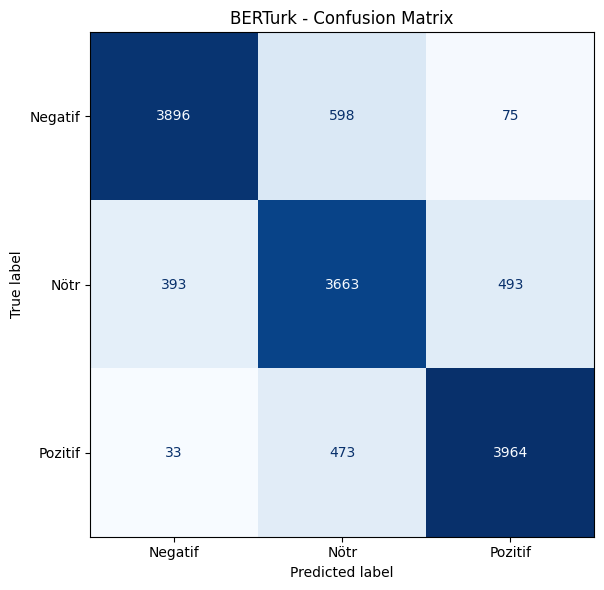

Saved: /content/berturk_confusion_matrix.png


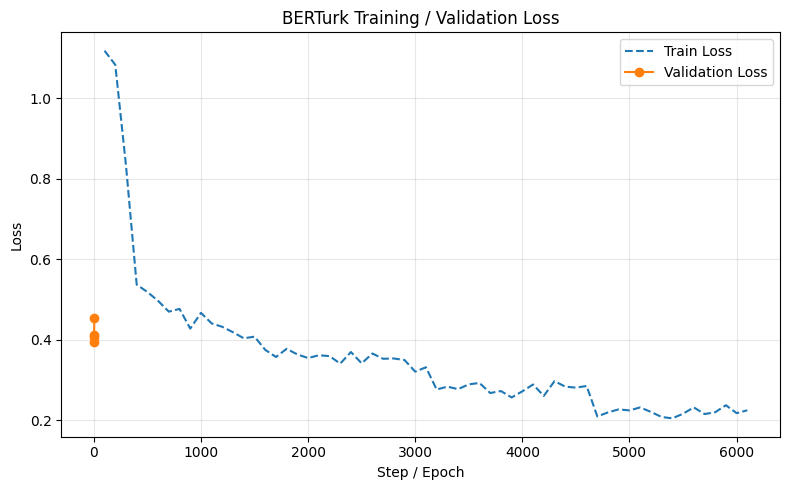

Saved: /content/berturk_loss_curve.png

FINAL SUMMARY
  Model      Task  Accuracy    F1  Precision  Recall  Inference(ms)  TrainSeconds  TrainSize  ValSize  TestSize
BERTurk Sentiment      84.8 84.88       85.0   84.82           0.72         323.2      48915     5436     13588

Saved: /content/berturk_results.csv


In [ ]:
# ============================================================
# CLEAN BERTurk SENTIMENT PIPELINE - FINAL VERSION
# TRSAv1 + Golden Dataset
# 3-class sentiment only
# ============================================================

!pip install -q -U transformers[sentencepiece] datasets scikit-learn accelerate openpyxl safetensors

import os
import re
import gc
import math
import json
import time
import random
import shutil
import warnings
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from inspect import signature
from datasets import Dataset, load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    EarlyStoppingCallback,
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

warnings.filterwarnings("ignore")

# ============================================================
# 0) SETTINGS
# ============================================================

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")
if DEVICE == "cuda":
    print(f"GPU   : {torch.cuda.get_device_name(0)}")
    print(f"VRAM  : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

MODEL_NAME = "dbmdz/bert-base-turkish-cased"
GOLDEN_PATH = "/content/golden_dataset.xlsx"

MAX_LENGTH = 128
TRAIN_BATCH_SIZE = 32
EVAL_BATCH_SIZE = 128
NUM_EPOCHS = 4
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.1
EARLY_STOPPING_PATIENCE = 2

TRSA_SAMPLE_PER_CLASS = 20000   # None yaparsan temizlenen TRSAv1'in tamamını kullanır
TEST_SIZE = 0.20
VAL_SIZE_WITHIN_TRAIN = 0.10

OUTPUT_DIR = "/content/drive/MyDrive/berturk_sentiment_run"
BEST_MODEL_DIR = "/content/drive/MyDrive/berturk_sentiment_best"

CLEAR_HF_CACHE_FIRST = False    # True yaparsan modeli baştan temiz indirir

LABEL_MAP_3 = {
    "Negative": 0, "negative": 0, "Olumsuz": 0, "olumsuz": 0,
    "Neutral": 1, "neutral": 1, "Nötr": 1, "nötr": 1, "Notr": 1, "notr": 1,
    "Positive": 2, "positive": 2, "Olumlu": 2, "olumlu": 2,
    0: 0, 1: 1, 2: 2,
}
ID2LABEL = {0: "Negative", 1: "Neutral", 2: "Positive"}
LABEL2ID = {"Negative": 0, "Neutral": 1, "Positive": 2}
CLASS_NAMES = ["Negatif", "Nötr", "Pozitif"]

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(BEST_MODEL_DIR, exist_ok=True)

# ============================================================
# 1) OPTIONAL CACHE CLEAN
# ============================================================

def clear_hf_model_cache(model_name):
    safe_name = model_name.replace("/", "--")
    cache_dir = os.path.expanduser(f"~/.cache/huggingface/hub/models--{safe_name}")
    if os.path.exists(cache_dir):
        shutil.rmtree(cache_dir)
        print(f"Deleted HF cache: {cache_dir}")
    else:
        print("HF cache not found, skipping.")

if CLEAR_HF_CACHE_FIRST:
    clear_hf_model_cache(MODEL_NAME)

# ============================================================
# 2) TEXT CLEANING
# ============================================================

def normalize_text(text):
    text = str(text)
    text = text.replace("\u200b", " ")
    text = text.replace("\xa0", " ")
    text = re.sub(r"\s+", " ", text).strip()
    return text

def is_bad_text(text):
    if text is None:
        return True

    t = normalize_text(text)

    if t == "":
        return True
    if t.lower() in {"nan", "none", "null"}:
        return True
    if len(t) < 3:
        return True

    # sadece sayı / noktalama / sembol
    if re.fullmatch(r"[\d\W_]+", t):
        return True

    # anlamsız sentetik örnek
    if t.lower().startswith("lorem ipsum"):
        return True

    return False

def make_text_norm(series):
    return (
        series.astype(str)
        .str.lower()
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
    )

# ============================================================
# 3) DATA CLEANING / AUDIT
# ============================================================

def clean_standard_df(df, text_col, label_col, source_name, drop_conflicts=True):
    df = df.copy()

    df[text_col] = df[text_col].astype(str).map(normalize_text)
    df = df[~df[text_col].map(is_bad_text)].copy()

    df[label_col] = df[label_col].map(LABEL_MAP_3)
    df = df.dropna(subset=[label_col]).copy()
    df[label_col] = df[label_col].astype(int)

    df = df.rename(columns={text_col: "text", label_col: "label"})
    df["source"] = source_name
    df["text_norm"] = make_text_norm(df["text"])

    # aynı text + aynı label tekrarları
    df = df.drop_duplicates(subset=["text_norm", "label"]).reset_index(drop=True)

    # aynı text + farklı label çakışmaları
    if drop_conflicts:
        label_counts = df.groupby("text_norm")["label"].nunique()
        conflict_keys = set(label_counts[label_counts > 1].index)

        if conflict_keys:
            conflict_df = df[df["text_norm"].isin(conflict_keys)].copy()
            conflict_path = f"/content/flagged_conflicts_{source_name.lower()}.csv"
            conflict_df.to_csv(conflict_path, index=False, encoding="utf-8-sig")
            print(f"{source_name}: conflicting texts removed = {len(conflict_df)}")
            print(f"Saved: {conflict_path}")

            df = df[~df["text_norm"].isin(conflict_keys)].copy()

    return df[["text", "label", "source", "text_norm"]].reset_index(drop=True)

def audit_dataset(df, name):
    print(f"\n{'='*70}")
    print(f"AUDIT | {name}")
    print(f"{'='*70}")
    print(f"Total: {len(df)}")
    print(f"Label dist: {df['label'].value_counts().sort_index().to_dict()}")

    dup_count = df["text_norm"].duplicated().sum()
    print(f"Exact duplicate text: {dup_count}")

    conflict = (
        df.groupby("text_norm")["label"]
        .nunique()
        .reset_index(name="n_labels")
    )
    conflict = conflict[conflict["n_labels"] > 1]
    print(f"Conflicting duplicate text: {len(conflict)}")

def remove_cross_source_duplicates(df):
    """
    Aynı text hem golden hem TRSA içinde varsa golden kalsın.
    """
    df = df.copy()
    df["source_priority"] = df["source"].map({"golden": 0, "trsa": 1}).fillna(9)
    df = df.sort_values(["text_norm", "source_priority"]).reset_index(drop=True)

    before = len(df)
    df = df.drop_duplicates(subset=["text_norm"], keep="first").reset_index(drop=True)
    after = len(df)

    print(f"Cross-source duplicates removed: {before - after}")
    return df.drop(columns=["source_priority"])

# ============================================================
# 4) LOAD DATASETS
# ============================================================

def load_golden(path):
    df = pd.read_excel(path)
    df.columns = df.columns.str.strip()

    required = {"Review", "Sentiment"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Golden dataset missing columns: {missing}")

    df = clean_standard_df(
        df=df,
        text_col="Review",
        label_col="Sentiment",
        source_name="golden",
        drop_conflicts=True
    )

    print(f"Golden loaded: {len(df)} | {df['label'].value_counts().sort_index().to_dict()}")
    return df

def load_trsa(sample_per_class=20000):
    print(f"TRSAv1 loading... sample_per_class={sample_per_class}")
    ds = load_dataset("maydogan/Turkish_SentimentAnalysis_TRSAv1", split="train")
    df = ds.to_pandas()

    print(f"TRSAv1 columns: {df.columns.tolist()}")

    required = {"review", "score"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"TRSAv1 expected columns missing: {missing}")

    df = clean_standard_df(
        df=df,
        text_col="review",   # doğru text sütunu
        label_col="score",   # doğru label sütunu
        source_name="trsa",
        drop_conflicts=True
    )

    if sample_per_class is not None:
        df = (
            df.groupby("label", group_keys=False)
              .apply(lambda x: x.sample(min(len(x), sample_per_class), random_state=SEED))
              .reset_index(drop=True)
        )

    print(f"TRSAv1 loaded: {len(df)} | {df['label'].value_counts().sort_index().to_dict()}")
    return df

# ============================================================
# 5) BUILD CLEAN DATASET
# ============================================================

def build_sentiment_dataset(golden_path, sample_per_class=20000):
    print("\n--- Loading datasets ---")
    df_golden = load_golden(golden_path)
    df_trsa = load_trsa(sample_per_class=sample_per_class)

    audit_dataset(df_golden, "GOLDEN")
    audit_dataset(df_trsa, "TRSA")

    df_combined = pd.concat([df_golden, df_trsa], ignore_index=True)
    df_combined = remove_cross_source_duplicates(df_combined)

    print(f"\nCombined total: {len(df_combined)}")
    print(f"Combined label dist: {df_combined['label'].value_counts().sort_index().to_dict()}")
    print(f"Sources: {df_combined['source'].value_counts().to_dict()}")

    return df_combined

# ============================================================
# 6) TRAIN / VAL / TEST SPLIT
# ============================================================

def split_train_val_test(df):
    df_train_full, df_test = train_test_split(
        df,
        test_size=TEST_SIZE,
        random_state=SEED,
        stratify=df["label"],
    )

    df_train, df_val = train_test_split(
        df_train_full,
        test_size=VAL_SIZE_WITHIN_TRAIN,
        random_state=SEED,
        stratify=df_train_full["label"],
    )

    overlap_train_test = set(df_train["text_norm"]) & set(df_test["text_norm"])
    overlap_train_val = set(df_train["text_norm"]) & set(df_val["text_norm"])
    overlap_val_test = set(df_val["text_norm"]) & set(df_test["text_norm"])

    print("\n--- Split summary ---")
    print(f"Train: {len(df_train)}")
    print(f"Val  : {len(df_val)}")
    print(f"Test : {len(df_test)}")
    print(f"Train label dist: {df_train['label'].value_counts().sort_index().to_dict()}")
    print(f"Val   label dist: {df_val['label'].value_counts().sort_index().to_dict()}")
    print(f"Test  label dist: {df_test['label'].value_counts().sort_index().to_dict()}")

    assert len(overlap_train_test) == 0, f"Leakage train-test: {len(overlap_train_test)}"
    assert len(overlap_train_val) == 0, f"Leakage train-val: {len(overlap_train_val)}"
    assert len(overlap_val_test) == 0, f"Leakage val-test: {len(overlap_val_test)}"
    print("Leakage check: OK")

    return (
        df_train.reset_index(drop=True),
        df_val.reset_index(drop=True),
        df_test.reset_index(drop=True),
    )

# ============================================================
# 7) TOKENIZATION
# ============================================================

def df_to_hf_dataset(df):
    return Dataset.from_pandas(
        df[["text", "label"]].reset_index(drop=True),
        preserve_index=False
    )

def tokenize_dataset(ds, tokenizer):
    def tokenize_batch(batch):
        return tokenizer(
            batch["text"],
            truncation=True,
            max_length=MAX_LENGTH,
        )
    return ds.map(tokenize_batch, batched=True)

# ============================================================
# 8) METRICS
# ============================================================

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    return {
        "accuracy": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds, average="macro", zero_division=0),
        "precision": precision_score(labels, preds, average="macro", zero_division=0),
        "recall": recall_score(labels, preds, average="macro", zero_division=0),
    }

# ============================================================
# 9) MODEL LOADING
# ============================================================

def load_clean_model_and_tokenizer(model_name):
    tokenizer = AutoTokenizer.from_pretrained(model_name)

    # önce safetensors ile dene
    try:
        model = AutoModelForSequenceClassification.from_pretrained(
            model_name,
            num_labels=3,
            id2label=ID2LABEL,
            label2id=LABEL2ID,
            use_safetensors=True,
        ).to(DEVICE)
        print("Model loaded with safetensors.")
    except Exception as e:
        print("Safetensors load failed, falling back to default loading.")
        print("Reason:", str(e))
        model = AutoModelForSequenceClassification.from_pretrained(
            model_name,
            num_labels=3,
            id2label=ID2LABEL,
            label2id=LABEL2ID,
        ).to(DEVICE)

    return tokenizer, model

# ============================================================
# 10) TRAIN BERTurk
# ============================================================

import transformers
from inspect import signature

print("transformers version:", transformers.__version__)

def build_training_args(train_len):
    steps_per_epoch = max(1, math.ceil(train_len / TRAIN_BATCH_SIZE))
    total_steps = steps_per_epoch * NUM_EPOCHS
    warmup_steps = int(total_steps * WARMUP_RATIO)

    sig = signature(TrainingArguments.__init__).parameters
    kwargs = {}

    # always needed
    kwargs["output_dir"] = OUTPUT_DIR
    kwargs["num_train_epochs"] = NUM_EPOCHS

    # batch size: new vs old names
    if "per_device_train_batch_size" in sig:
        kwargs["per_device_train_batch_size"] = TRAIN_BATCH_SIZE
    elif "per_gpu_train_batch_size" in sig:
        kwargs["per_gpu_train_batch_size"] = TRAIN_BATCH_SIZE

    if "per_device_eval_batch_size" in sig:
        kwargs["per_device_eval_batch_size"] = EVAL_BATCH_SIZE
    elif "per_gpu_eval_batch_size" in sig:
        kwargs["per_gpu_eval_batch_size"] = EVAL_BATCH_SIZE

    # standard training params
    if "learning_rate" in sig:
        kwargs["learning_rate"] = LEARNING_RATE
    if "weight_decay" in sig:
        kwargs["weight_decay"] = WEIGHT_DECAY
    if "warmup_steps" in sig:
        kwargs["warmup_steps"] = warmup_steps
    if "max_grad_norm" in sig:
        kwargs["max_grad_norm"] = 1.0
    if "seed" in sig:
        kwargs["seed"] = SEED
    if "fp16" in sig:
        kwargs["fp16"] = (DEVICE == "cuda")
    if "logging_steps" in sig:
        kwargs["logging_steps"] = 100
    if "report_to" in sig:
        kwargs["report_to"] = "none"
    if "save_total_limit" in sig:
        kwargs["save_total_limit"] = 2
    if "save_safetensors" in sig:
        kwargs["save_safetensors"] = True

    # evaluation mode: different transformers versions use different names
    if "eval_strategy" in sig:
        kwargs["eval_strategy"] = "epoch"
    elif "evaluation_strategy" in sig:
        kwargs["evaluation_strategy"] = "epoch"
    elif "evaluate_during_training" in sig:
        kwargs["evaluate_during_training"] = True
    elif "do_eval" in sig:
        kwargs["do_eval"] = True

    # saving mode
    if "save_strategy" in sig:
        kwargs["save_strategy"] = "epoch"
    elif "save_steps" in sig:
        kwargs["save_steps"] = steps_per_epoch

    # best-model loading
    if "load_best_model_at_end" in sig:
        kwargs["load_best_model_at_end"] = True
    if "metric_for_best_model" in sig:
        kwargs["metric_for_best_model"] = "f1"
    if "greater_is_better" in sig:
        kwargs["greater_is_better"] = True

    args = TrainingArguments(**kwargs)

    print("TrainingArguments keys used:")
    print(sorted(kwargs.keys()))

    return args

def train_berturk(df_train, df_val):
    tokenizer, model = load_clean_model_and_tokenizer(MODEL_NAME)

    train_ds = tokenize_dataset(df_to_hf_dataset(df_train), tokenizer)
    val_ds = tokenize_dataset(df_to_hf_dataset(df_val), tokenizer)

    args = build_training_args(len(train_ds))

    trainer_kwargs = dict(
        model=model,
        args=args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        data_collator=DataCollatorWithPadding(tokenizer=tokenizer),
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=EARLY_STOPPING_PATIENCE)],
    )

    trainer_sig = signature(Trainer.__init__)

    if "processing_class" in trainer_sig.parameters:
        trainer_kwargs["processing_class"] = tokenizer
    elif "tokenizer" in trainer_sig.parameters:
        trainer_kwargs["tokenizer"] = tokenizer

    trainer = Trainer(**trainer_kwargs)

    print("\n--- Training BERTurk ---")
    start = time.time()
    trainer.train()
    train_seconds = round(time.time() - start, 1)

    print(f"Training finished in {train_seconds} sec")

    trainer.save_model(BEST_MODEL_DIR)
    tokenizer.save_pretrained(BEST_MODEL_DIR)
    print(f"Best model saved to: {BEST_MODEL_DIR}")

    return trainer, tokenizer, train_seconds

# ============================================================
# 11) EVALUATE ON TEST
# ============================================================

def evaluate_on_test(trainer, tokenizer, df_test, train_seconds):
    test_ds = tokenize_dataset(df_to_hf_dataset(df_test), tokenizer)

    print("\n--- Final test evaluation ---")
    pred_output = trainer.predict(test_ds)

    logits = pred_output.predictions
    labels = pred_output.label_ids
    preds = np.argmax(logits, axis=-1)

    metrics = {
        "accuracy": round(accuracy_score(labels, preds) * 100, 2),
        "f1": round(f1_score(labels, preds, average="macro", zero_division=0) * 100, 2),
        "precision": round(precision_score(labels, preds, average="macro", zero_division=0) * 100, 2),
        "recall": round(recall_score(labels, preds, average="macro", zero_division=0) * 100, 2),
        "train_seconds": train_seconds,
    }

    model = trainer.model
    model.eval()
    sample_texts = df_test["text"].head(100).tolist()
    t0 = time.time()

    for i in range(0, len(sample_texts), 32):
        enc = tokenizer(
            sample_texts[i:i+32],
            truncation=True,
            max_length=MAX_LENGTH,
            padding=True,
            return_tensors="pt"
        ).to(DEVICE)
        with torch.no_grad():
            _ = model(**enc)

    inf_ms = round((time.time() - t0) / max(len(sample_texts), 1) * 1000, 2)
    metrics["inference_ms_per_text"] = inf_ms

    print(json.dumps(metrics, indent=2, ensure_ascii=False))

    result_df = pd.DataFrame({
        "text": df_test["text"].values,
        "label": labels,
        "pred": preds,
    })
    result_df["label_name"] = result_df["label"].map({0: "Negatif", 1: "Nötr", 2: "Pozitif"})
    result_df["pred_name"] = result_df["pred"].map({0: "Negatif", 1: "Nötr", 2: "Pozitif"})
    result_df["correct"] = (result_df["label"] == result_df["pred"]).astype(int)

    result_df.to_csv("/content/berturk_test_predictions.csv", index=False, encoding="utf-8-sig")
    print("Saved: /content/berturk_test_predictions.csv")

    wrong_df = result_df[result_df["correct"] == 0].copy()
    wrong_df.to_csv("/content/berturk_errors.csv", index=False, encoding="utf-8-sig")
    print("Saved: /content/berturk_errors.csv")

    return metrics, result_df, wrong_df

# ============================================================
# 12) PLOTS
# ============================================================

def plot_confusion(result_df):
    cm = confusion_matrix(result_df["label"], result_df["pred"])
    fig, ax = plt.subplots(figsize=(7, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title("BERTurk - Confusion Matrix")
    plt.tight_layout()
    plt.savefig("/content/berturk_confusion_matrix.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: /content/berturk_confusion_matrix.png")

def plot_loss_curve(trainer):
    log_history = trainer.state.log_history

    train_logs = [x for x in log_history if "loss" in x and "eval_loss" not in x]
    eval_logs = [x for x in log_history if "eval_loss" in x]

    train_steps = [x.get("step", i + 1) for i, x in enumerate(train_logs)]
    train_losses = [x["loss"] for x in train_logs]

    eval_epochs = [x.get("epoch", i + 1) for i, x in enumerate(eval_logs)]
    eval_losses = [x["eval_loss"] for x in eval_logs]

    plt.figure(figsize=(8, 5))
    if train_losses:
        plt.plot(train_steps, train_losses, label="Train Loss", linestyle="--")
    if eval_losses:
        plt.plot(eval_epochs, eval_losses, label="Validation Loss", marker="o")
    plt.title("BERTurk Training / Validation Loss")
    plt.xlabel("Step / Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig("/content/berturk_loss_curve.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: /content/berturk_loss_curve.png")

# ============================================================
# 13) RUN ALL
# ============================================================

df_combined = build_sentiment_dataset(
    golden_path=GOLDEN_PATH,
    sample_per_class=TRSA_SAMPLE_PER_CLASS
)

df_combined.drop(columns=["text_norm"]).to_csv(
    "/content/combined_clean_sentiment.csv",
    index=False,
    encoding="utf-8-sig"
)
print("Saved: /content/combined_clean_sentiment.csv")

df_train, df_val, df_test = split_train_val_test(df_combined)

df_train.drop(columns=["text_norm"]).to_csv("/content/sentiment_train_clean.csv", index=False, encoding="utf-8-sig")
df_val.drop(columns=["text_norm"]).to_csv("/content/sentiment_val_clean.csv", index=False, encoding="utf-8-sig")
df_test.drop(columns=["text_norm"]).to_csv("/content/sentiment_test_clean.csv", index=False, encoding="utf-8-sig")
print("Saved: /content/sentiment_train_clean.csv")
print("Saved: /content/sentiment_val_clean.csv")
print("Saved: /content/sentiment_test_clean.csv")

trainer, tokenizer, train_seconds = train_berturk(df_train, df_val)
metrics, result_df, wrong_df = evaluate_on_test(trainer, tokenizer, df_test, train_seconds)

plot_confusion(result_df)
plot_loss_curve(trainer)

summary_df = pd.DataFrame([{
    "Model": "BERTurk",
    "Task": "Sentiment",
    "Accuracy": metrics["accuracy"],
    "F1": metrics["f1"],
    "Precision": metrics["precision"],
    "Recall": metrics["recall"],
    "Inference(ms)": metrics["inference_ms_per_text"],
    "TrainSeconds": metrics["train_seconds"],
    "TrainSize": len(df_train),
    "ValSize": len(df_val),
    "TestSize": len(df_test),
}])

summary_df.to_csv("/content/berturk_results.csv", index=False, encoding="utf-8-sig")
print("\nFINAL SUMMARY")
print(summary_df.to_string(index=False))
print("\nSaved: /content/berturk_results.csv")

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

Device: cuda
transformers version: 5.5.4
GPU   : NVIDIA A100-SXM4-80GB
VRAM  : 85.1 GB

--- Loading datasets ---
Golden loaded: 7940 | {0: 2844, 1: 2747, 2: 2349}
TRSAv1 loading... sample_per_class=20000
TRSAv1 columns: ['id', 'score', 'review']
trsa: conflicting texts removed = 1966
Saved: /content/flagged_conflicts_trsa.csv
TRSAv1 loaded: 60000 | {0: 20000, 1: 20000, 2: 20000}

AUDIT | GOLDEN
Total: 7940
Label dist: {0: 2844, 1: 2747, 2: 2349}
Exact duplicate text: 0
Conflicting duplicate text: 0

AUDIT | TRSA
Total: 60000
Label dist: {0: 20000, 1: 20000, 2: 20000}
Exact duplicate text: 0
Conflicting duplicate text: 0
Cross-source duplicates removed: 1

Combined total: 67939
Combined label dist: {0: 22843, 1: 22747, 2: 22349}
Sources: {'trsa': 59999, 'golden': 7940}
Saved: /content/combined_clean_sentiment.csv

--- Split summary ---
Train: 48915
Val  : 5436
Test : 13588
Train label dist: {0: 16446, 1: 16378, 2: 16091}
Val   label dist: {0: 1828, 1: 1820, 2: 1788}
Test  label dist: {0

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Best model saved to: /content/mbert_sentiment_best


Map:   0%|          | 0/13588 [00:00<?, ? examples/s]


--- Final test evaluation ---


{
  "accuracy": 82.33,
  "f1": 82.37,
  "precision": 82.45,
  "recall": 82.35,
  "train_seconds": 342.8,
  "inference_ms_per_text": 0.75
}
Saved: /content/mbert_test_predictions.csv
Saved: /content/mbert_errors.csv


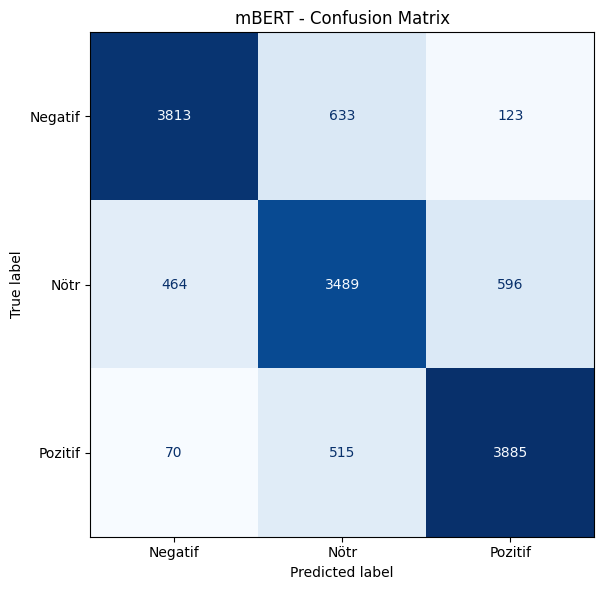

Saved: /content/mbert_confusion_matrix.png


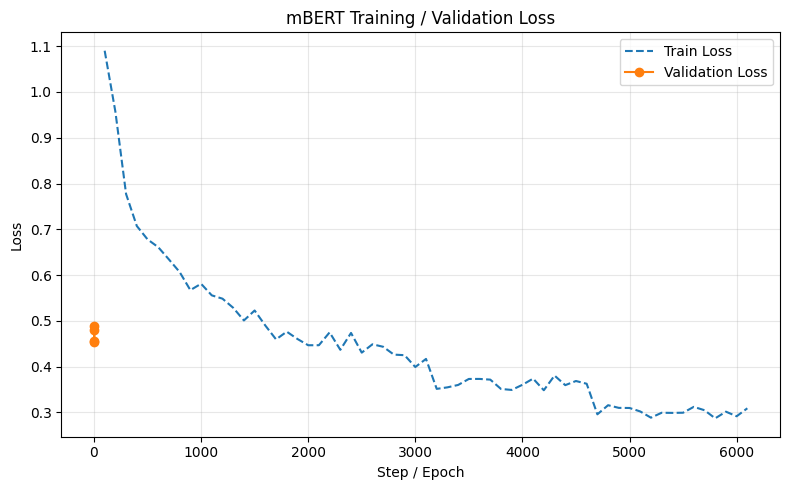

Saved: /content/mbert_loss_curve.png

FINAL SUMMARY
Model      Task  Accuracy    F1  Precision  Recall  Inference(ms)  TrainSeconds  TrainSize  ValSize  TestSize
mBERT Sentiment     82.33 82.37      82.45   82.35           0.75         342.8      48915     5436     13588

Saved: /content/mbert_results.csv


In [ ]:
# ============================================================
# CLEAN mBERT SENTIMENT PIPELINE - FINAL VERSION
# TRSAv1 + Golden Dataset
# 3-class sentiment only
# ============================================================

!pip install -q -U transformers[sentencepiece] datasets scikit-learn accelerate openpyxl safetensors

import os
import re
import gc
import math
import json
import time
import random
import shutil
import warnings
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import transformers

from inspect import signature
from datasets import Dataset, load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    EarlyStoppingCallback,
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

warnings.filterwarnings("ignore")

# ============================================================
# 0) SETTINGS
# ============================================================

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")
print("transformers version:", transformers.__version__)
if DEVICE == "cuda":
    print(f"GPU   : {torch.cuda.get_device_name(0)}")
    print(f"VRAM  : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

MODEL_NAME = "bert-base-multilingual-cased"
GOLDEN_PATH = "/content/golden_dataset.xlsx"

MAX_LENGTH = 128
TRAIN_BATCH_SIZE = 32
EVAL_BATCH_SIZE = 128
NUM_EPOCHS = 4
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.1
EARLY_STOPPING_PATIENCE = 2

TRSA_SAMPLE_PER_CLASS = 20000   # None yaparsan temizlenen TRSAv1'in tamamını kullanır
TEST_SIZE = 0.20
VAL_SIZE_WITHIN_TRAIN = 0.10

OUTPUT_DIR = "/content/mbert_sentiment_run"
BEST_MODEL_DIR = "/content/mbert_sentiment_best"

CLEAR_HF_CACHE_FIRST = False

LABEL_MAP_3 = {
    "Negative": 0, "negative": 0, "Olumsuz": 0, "olumsuz": 0,
    "Neutral": 1, "neutral": 1, "Nötr": 1, "nötr": 1, "Notr": 1, "notr": 1,
    "Positive": 2, "positive": 2, "Olumlu": 2, "olumlu": 2,
    0: 0, 1: 1, 2: 2,
}
ID2LABEL = {0: "Negative", 1: "Neutral", 2: "Positive"}
LABEL2ID = {"Negative": 0, "Neutral": 1, "Positive": 2}
CLASS_NAMES = ["Negatif", "Nötr", "Pozitif"]

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(BEST_MODEL_DIR, exist_ok=True)

# ============================================================
# 1) OPTIONAL CACHE CLEAN
# ============================================================

def clear_hf_model_cache(model_name):
    safe_name = model_name.replace("/", "--")
    cache_dir = os.path.expanduser(f"~/.cache/huggingface/hub/models--{safe_name}")
    if os.path.exists(cache_dir):
        shutil.rmtree(cache_dir)
        print(f"Deleted HF cache: {cache_dir}")
    else:
        print("HF cache not found, skipping.")

if CLEAR_HF_CACHE_FIRST:
    clear_hf_model_cache(MODEL_NAME)

# ============================================================
# 2) TEXT CLEANING
# ============================================================

def normalize_text(text):
    text = str(text)
    text = text.replace("\u200b", " ")
    text = text.replace("\xa0", " ")
    text = re.sub(r"\s+", " ", text).strip()
    return text

def is_bad_text(text):
    if text is None:
        return True

    t = normalize_text(text)

    if t == "":
        return True
    if t.lower() in {"nan", "none", "null"}:
        return True
    if len(t) < 3:
        return True
    if re.fullmatch(r"[\d\W_]+", t):
        return True
    if t.lower().startswith("lorem ipsum"):
        return True

    return False

def make_text_norm(series):
    return (
        series.astype(str)
        .str.lower()
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
    )

# ============================================================
# 3) DATA CLEANING / AUDIT
# ============================================================

def clean_standard_df(df, text_col, label_col, source_name, drop_conflicts=True):
    df = df.copy()

    df[text_col] = df[text_col].astype(str).map(normalize_text)
    df = df[~df[text_col].map(is_bad_text)].copy()

    df[label_col] = df[label_col].map(LABEL_MAP_3)
    df = df.dropna(subset=[label_col]).copy()
    df[label_col] = df[label_col].astype(int)

    df = df.rename(columns={text_col: "text", label_col: "label"})
    df["source"] = source_name
    df["text_norm"] = make_text_norm(df["text"])

    df = df.drop_duplicates(subset=["text_norm", "label"]).reset_index(drop=True)

    if drop_conflicts:
        label_counts = df.groupby("text_norm")["label"].nunique()
        conflict_keys = set(label_counts[label_counts > 1].index)

        if conflict_keys:
            conflict_df = df[df["text_norm"].isin(conflict_keys)].copy()
            conflict_path = f"/content/flagged_conflicts_{source_name.lower()}.csv"
            conflict_df.to_csv(conflict_path, index=False, encoding="utf-8-sig")
            print(f"{source_name}: conflicting texts removed = {len(conflict_df)}")
            print(f"Saved: {conflict_path}")

            df = df[~df["text_norm"].isin(conflict_keys)].copy()

    return df[["text", "label", "source", "text_norm"]].reset_index(drop=True)

def audit_dataset(df, name):
    print(f"\n{'='*70}")
    print(f"AUDIT | {name}")
    print(f"{'='*70}")
    print(f"Total: {len(df)}")
    print(f"Label dist: {df['label'].value_counts().sort_index().to_dict()}")

    dup_count = df["text_norm"].duplicated().sum()
    print(f"Exact duplicate text: {dup_count}")

    conflict = (
        df.groupby("text_norm")["label"]
        .nunique()
        .reset_index(name="n_labels")
    )
    conflict = conflict[conflict["n_labels"] > 1]
    print(f"Conflicting duplicate text: {len(conflict)}")

def remove_cross_source_duplicates(df):
    df = df.copy()
    df["source_priority"] = df["source"].map({"golden": 0, "trsa": 1}).fillna(9)
    df = df.sort_values(["text_norm", "source_priority"]).reset_index(drop=True)

    before = len(df)
    df = df.drop_duplicates(subset=["text_norm"], keep="first").reset_index(drop=True)
    after = len(df)

    print(f"Cross-source duplicates removed: {before - after}")
    return df.drop(columns=["source_priority"])

# ============================================================
# 4) LOAD DATASETS
# ============================================================

def load_golden(path):
    df = pd.read_excel(path)
    df.columns = df.columns.str.strip()

    required = {"Review", "Sentiment"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Golden dataset missing columns: {missing}")

    df = clean_standard_df(
        df=df,
        text_col="Review",
        label_col="Sentiment",
        source_name="golden",
        drop_conflicts=True
    )

    print(f"Golden loaded: {len(df)} | {df['label'].value_counts().sort_index().to_dict()}")
    return df

def load_trsa(sample_per_class=20000):
    print(f"TRSAv1 loading... sample_per_class={sample_per_class}")
    ds = load_dataset("maydogan/Turkish_SentimentAnalysis_TRSAv1", split="train")
    df = ds.to_pandas()

    print(f"TRSAv1 columns: {df.columns.tolist()}")

    required = {"review", "score"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"TRSAv1 expected columns missing: {missing}")

    df = clean_standard_df(
        df=df,
        text_col="review",
        label_col="score",
        source_name="trsa",
        drop_conflicts=True
    )

    if sample_per_class is not None:
        df = (
            df.groupby("label", group_keys=False)
              .apply(lambda x: x.sample(min(len(x), sample_per_class), random_state=SEED))
              .reset_index(drop=True)
        )

    print(f"TRSAv1 loaded: {len(df)} | {df['label'].value_counts().sort_index().to_dict()}")
    return df

# ============================================================
# 5) BUILD CLEAN DATASET
# ============================================================

def build_sentiment_dataset(golden_path, sample_per_class=20000):
    print("\n--- Loading datasets ---")
    df_golden = load_golden(golden_path)
    df_trsa = load_trsa(sample_per_class=sample_per_class)

    audit_dataset(df_golden, "GOLDEN")
    audit_dataset(df_trsa, "TRSA")

    df_combined = pd.concat([df_golden, df_trsa], ignore_index=True)
    df_combined = remove_cross_source_duplicates(df_combined)

    print(f"\nCombined total: {len(df_combined)}")
    print(f"Combined label dist: {df_combined['label'].value_counts().sort_index().to_dict()}")
    print(f"Sources: {df_combined['source'].value_counts().to_dict()}")

    return df_combined

# ============================================================
# 6) TRAIN / VAL / TEST SPLIT
# ============================================================

def split_train_val_test(df):
    df_train_full, df_test = train_test_split(
        df,
        test_size=TEST_SIZE,
        random_state=SEED,
        stratify=df["label"],
    )

    df_train, df_val = train_test_split(
        df_train_full,
        test_size=VAL_SIZE_WITHIN_TRAIN,
        random_state=SEED,
        stratify=df_train_full["label"],
    )

    overlap_train_test = set(df_train["text_norm"]) & set(df_test["text_norm"])
    overlap_train_val = set(df_train["text_norm"]) & set(df_val["text_norm"])
    overlap_val_test = set(df_val["text_norm"]) & set(df_test["text_norm"])

    print("\n--- Split summary ---")
    print(f"Train: {len(df_train)}")
    print(f"Val  : {len(df_val)}")
    print(f"Test : {len(df_test)}")
    print(f"Train label dist: {df_train['label'].value_counts().sort_index().to_dict()}")
    print(f"Val   label dist: {df_val['label'].value_counts().sort_index().to_dict()}")
    print(f"Test  label dist: {df_test['label'].value_counts().sort_index().to_dict()}")

    assert len(overlap_train_test) == 0, f"Leakage train-test: {len(overlap_train_test)}"
    assert len(overlap_train_val) == 0, f"Leakage train-val: {len(overlap_train_val)}"
    assert len(overlap_val_test) == 0, f"Leakage val-test: {len(overlap_val_test)}"
    print("Leakage check: OK")

    return (
        df_train.reset_index(drop=True),
        df_val.reset_index(drop=True),
        df_test.reset_index(drop=True),
    )

# ============================================================
# 7) TOKENIZATION
# ============================================================

def df_to_hf_dataset(df):
    return Dataset.from_pandas(
        df[["text", "label"]].reset_index(drop=True),
        preserve_index=False
    )

def tokenize_dataset(ds, tokenizer):
    def tokenize_batch(batch):
        return tokenizer(
            batch["text"],
            truncation=True,
            max_length=MAX_LENGTH,
        )
    return ds.map(tokenize_batch, batched=True)

# ============================================================
# 8) METRICS
# ============================================================

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    return {
        "accuracy": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds, average="macro", zero_division=0),
        "precision": precision_score(labels, preds, average="macro", zero_division=0),
        "recall": recall_score(labels, preds, average="macro", zero_division=0),
    }

# ============================================================
# 9) MODEL LOADING
# ============================================================

def load_clean_model_and_tokenizer(model_name):
    tokenizer = AutoTokenizer.from_pretrained(model_name)

    try:
        model = AutoModelForSequenceClassification.from_pretrained(
            model_name,
            num_labels=3,
            id2label=ID2LABEL,
            label2id=LABEL2ID,
            use_safetensors=True,
        ).to(DEVICE)
        print("Model loaded with safetensors.")
    except Exception as e:
        print("Safetensors load failed, falling back to default loading.")
        print("Reason:", str(e))
        model = AutoModelForSequenceClassification.from_pretrained(
            model_name,
            num_labels=3,
            id2label=ID2LABEL,
            label2id=LABEL2ID,
        ).to(DEVICE)

    return tokenizer, model

# ============================================================
# 10) TRAIN mBERT
# ============================================================

def build_training_args(train_len):
    steps_per_epoch = max(1, math.ceil(train_len / TRAIN_BATCH_SIZE))
    total_steps = steps_per_epoch * NUM_EPOCHS
    warmup_steps = int(total_steps * WARMUP_RATIO)

    sig = signature(TrainingArguments.__init__).parameters
    kwargs = {}

    kwargs["output_dir"] = OUTPUT_DIR
    kwargs["num_train_epochs"] = NUM_EPOCHS

    if "per_device_train_batch_size" in sig:
        kwargs["per_device_train_batch_size"] = TRAIN_BATCH_SIZE
    elif "per_gpu_train_batch_size" in sig:
        kwargs["per_gpu_train_batch_size"] = TRAIN_BATCH_SIZE

    if "per_device_eval_batch_size" in sig:
        kwargs["per_device_eval_batch_size"] = EVAL_BATCH_SIZE
    elif "per_gpu_eval_batch_size" in sig:
        kwargs["per_gpu_eval_batch_size"] = EVAL_BATCH_SIZE

    if "learning_rate" in sig:
        kwargs["learning_rate"] = LEARNING_RATE
    if "weight_decay" in sig:
        kwargs["weight_decay"] = WEIGHT_DECAY
    if "warmup_steps" in sig:
        kwargs["warmup_steps"] = warmup_steps
    if "max_grad_norm" in sig:
        kwargs["max_grad_norm"] = 1.0
    if "seed" in sig:
        kwargs["seed"] = SEED
    if "fp16" in sig:
        kwargs["fp16"] = (DEVICE == "cuda")
    if "logging_steps" in sig:
        kwargs["logging_steps"] = 100
    if "report_to" in sig:
        kwargs["report_to"] = "none"
    if "save_total_limit" in sig:
        kwargs["save_total_limit"] = 2
    if "save_safetensors" in sig:
        kwargs["save_safetensors"] = True

    if "eval_strategy" in sig:
        kwargs["eval_strategy"] = "epoch"
    elif "evaluation_strategy" in sig:
        kwargs["evaluation_strategy"] = "epoch"
    elif "evaluate_during_training" in sig:
        kwargs["evaluate_during_training"] = True
    elif "do_eval" in sig:
        kwargs["do_eval"] = True

    if "save_strategy" in sig:
        kwargs["save_strategy"] = "epoch"
    elif "save_steps" in sig:
        kwargs["save_steps"] = steps_per_epoch

    if "load_best_model_at_end" in sig:
        kwargs["load_best_model_at_end"] = True
    if "metric_for_best_model" in sig:
        kwargs["metric_for_best_model"] = "f1"
    if "greater_is_better" in sig:
        kwargs["greater_is_better"] = True

    args = TrainingArguments(**kwargs)

    print("TrainingArguments keys used:")
    print(sorted(kwargs.keys()))

    return args

def train_mbert(df_train, df_val):
    tokenizer, model = load_clean_model_and_tokenizer(MODEL_NAME)

    train_ds = tokenize_dataset(df_to_hf_dataset(df_train), tokenizer)
    val_ds = tokenize_dataset(df_to_hf_dataset(df_val), tokenizer)

    args = build_training_args(len(train_ds))

    trainer_kwargs = dict(
        model=model,
        args=args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        data_collator=DataCollatorWithPadding(tokenizer=tokenizer),
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=EARLY_STOPPING_PATIENCE)],
    )

    trainer_sig = signature(Trainer.__init__)

    if "processing_class" in trainer_sig.parameters:
        trainer_kwargs["processing_class"] = tokenizer
    elif "tokenizer" in trainer_sig.parameters:
        trainer_kwargs["tokenizer"] = tokenizer

    trainer = Trainer(**trainer_kwargs)

    print("\n--- Training mBERT ---")
    start = time.time()
    trainer.train()
    train_seconds = round(time.time() - start, 1)

    print(f"Training finished in {train_seconds} sec")

    trainer.save_model(BEST_MODEL_DIR)
    tokenizer.save_pretrained(BEST_MODEL_DIR)
    print(f"Best model saved to: {BEST_MODEL_DIR}")

    return trainer, tokenizer, train_seconds

# ============================================================
# 11) EVALUATE ON TEST
# ============================================================

def evaluate_on_test(trainer, tokenizer, df_test, train_seconds):
    test_ds = tokenize_dataset(df_to_hf_dataset(df_test), tokenizer)

    print("\n--- Final test evaluation ---")
    pred_output = trainer.predict(test_ds)

    logits = pred_output.predictions
    labels = pred_output.label_ids
    preds = np.argmax(logits, axis=-1)

    metrics = {
        "accuracy": round(accuracy_score(labels, preds) * 100, 2),
        "f1": round(f1_score(labels, preds, average="macro", zero_division=0) * 100, 2),
        "precision": round(precision_score(labels, preds, average="macro", zero_division=0) * 100, 2),
        "recall": round(recall_score(labels, preds, average="macro", zero_division=0) * 100, 2),
        "train_seconds": train_seconds,
    }

    model = trainer.model
    model.eval()
    sample_texts = df_test["text"].head(100).tolist()
    t0 = time.time()

    for i in range(0, len(sample_texts), 32):
        enc = tokenizer(
            sample_texts[i:i+32],
            truncation=True,
            max_length=MAX_LENGTH,
            padding=True,
            return_tensors="pt"
        ).to(DEVICE)
        with torch.no_grad():
            _ = model(**enc)

    inf_ms = round((time.time() - t0) / max(len(sample_texts), 1) * 1000, 2)
    metrics["inference_ms_per_text"] = inf_ms

    print(json.dumps(metrics, indent=2, ensure_ascii=False))

    result_df = pd.DataFrame({
        "text": df_test["text"].values,
        "label": labels,
        "pred": preds,
    })
    result_df["label_name"] = result_df["label"].map({0: "Negatif", 1: "Nötr", 2: "Pozitif"})
    result_df["pred_name"] = result_df["pred"].map({0: "Negatif", 1: "Nötr", 2: "Pozitif"})
    result_df["correct"] = (result_df["label"] == result_df["pred"]).astype(int)

    result_df.to_csv("/content/mbert_test_predictions.csv", index=False, encoding="utf-8-sig")
    print("Saved: /content/mbert_test_predictions.csv")

    wrong_df = result_df[result_df["correct"] == 0].copy()
    wrong_df.to_csv("/content/mbert_errors.csv", index=False, encoding="utf-8-sig")
    print("Saved: /content/mbert_errors.csv")

    return metrics, result_df, wrong_df

# ============================================================
# 12) PLOTS
# ============================================================

def plot_confusion(result_df):
    cm = confusion_matrix(result_df["label"], result_df["pred"])
    fig, ax = plt.subplots(figsize=(7, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title("mBERT - Confusion Matrix")
    plt.tight_layout()
    plt.savefig("/content/mbert_confusion_matrix.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: /content/mbert_confusion_matrix.png")

def plot_loss_curve(trainer):
    log_history = trainer.state.log_history

    train_logs = [x for x in log_history if "loss" in x and "eval_loss" not in x]
    eval_logs = [x for x in log_history if "eval_loss" in x]

    train_steps = [x.get("step", i + 1) for i, x in enumerate(train_logs)]
    train_losses = [x["loss"] for x in train_logs]

    eval_epochs = [x.get("epoch", i + 1) for i, x in enumerate(eval_logs)]
    eval_losses = [x["eval_loss"] for x in eval_logs]

    plt.figure(figsize=(8, 5))
    if train_losses:
        plt.plot(train_steps, train_losses, label="Train Loss", linestyle="--")
    if eval_losses:
        plt.plot(eval_epochs, eval_losses, label="Validation Loss", marker="o")
    plt.title("mBERT Training / Validation Loss")
    plt.xlabel("Step / Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig("/content/mbert_loss_curve.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: /content/mbert_loss_curve.png")

# ============================================================
# 13) RUN ALL
# ============================================================

df_combined = build_sentiment_dataset(
    golden_path=GOLDEN_PATH,
    sample_per_class=TRSA_SAMPLE_PER_CLASS
)

df_combined.drop(columns=["text_norm"]).to_csv(
    "/content/combined_clean_sentiment.csv",
    index=False,
    encoding="utf-8-sig"
)
print("Saved: /content/combined_clean_sentiment.csv")

df_train, df_val, df_test = split_train_val_test(df_combined)

df_train.drop(columns=["text_norm"]).to_csv("/content/sentiment_train_clean.csv", index=False, encoding="utf-8-sig")
df_val.drop(columns=["text_norm"]).to_csv("/content/sentiment_val_clean.csv", index=False, encoding="utf-8-sig")
df_test.drop(columns=["text_norm"]).to_csv("/content/sentiment_test_clean.csv", index=False, encoding="utf-8-sig")
print("Saved: /content/sentiment_train_clean.csv")
print("Saved: /content/sentiment_val_clean.csv")
print("Saved: /content/sentiment_test_clean.csv")

trainer, tokenizer, train_seconds = train_mbert(df_train, df_val)
metrics, result_df, wrong_df = evaluate_on_test(trainer, tokenizer, df_test, train_seconds)

plot_confusion(result_df)
plot_loss_curve(trainer)

summary_df = pd.DataFrame([{
    "Model": "mBERT",
    "Task": "Sentiment",
    "Accuracy": metrics["accuracy"],
    "F1": metrics["f1"],
    "Precision": metrics["precision"],
    "Recall": metrics["recall"],
    "Inference(ms)": metrics["inference_ms_per_text"],
    "TrainSeconds": metrics["train_seconds"],
    "TrainSize": len(df_train),
    "ValSize": len(df_val),
    "TestSize": len(df_test),
}])

summary_df.to_csv("/content/mbert_results.csv", index=False, encoding="utf-8-sig")
print("\nFINAL SUMMARY")
print(summary_df.to_string(index=False))
print("\nSaved: /content/mbert_results.csv")

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 23.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 88.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 44.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 124.7 MB/s eta 0:00:00
Device: cuda
transformers version: 5.5.4
GPU   : NVIDIA A100-SXM4-80GB
VRAM  : 85.1 GB

--- Loading datasets ---
Golden loaded: 7940 | {0: 2844, 1: 2747, 2: 2349}
TRSAv1 loading... sample_per_class=20000


README.md:   0%|          | 0.00/708 [00:00<?, ?B/s]

TRSAv1.csv:   0%|          | 0.00/16.1M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/150000 [00:00<?, ? examples/s]

TRSAv1 columns: ['id', 'score', 'review']
trsa: conflicting texts removed = 1966
Saved: /content/flagged_conflicts_trsa.csv
TRSAv1 loaded: 60000 | {0: 20000, 1: 20000, 2: 20000}

AUDIT | GOLDEN
Total: 7940
Label dist: {0: 2844, 1: 2747, 2: 2349}
Exact duplicate text: 0
Conflicting duplicate text: 0

AUDIT | TRSA
Total: 60000
Label dist: {0: 20000, 1: 20000, 2: 20000}
Exact duplicate text: 0
Conflicting duplicate text: 0
Cross-source duplicates removed: 1

Combined total: 67939
Combined label dist: {0: 22843, 1: 22747, 2: 22349}
Sources: {'trsa': 59999, 'golden': 7940}
Saved: /content/combined_clean_sentiment.csv

--- Split summary ---
Train: 48915
Val  : 5436
Test : 13588
Train label dist: {0: 16446, 1: 16378, 2: 16091}
Val   label dist: {0: 1828, 1: 1820, 2: 1788}
Test  label dist: {0: 4569, 1: 4549, 2: 4470}
Leakage check: OK
Saved: /content/sentiment_train_clean.csv
Saved: /content/sentiment_val_clean.csv
Saved: /content/sentiment_test_clean.csv


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Best model saved to: /content/xlmr_sentiment_best


Map:   0%|          | 0/13588 [00:00<?, ? examples/s]


--- Final test evaluation ---


{
  "accuracy": 84.18,
  "f1": 84.21,
  "precision": 84.26,
  "recall": 84.21,
  "train_seconds": 634.0,
  "inference_ms_per_text": 0.7
}
Saved: /content/xlmr_test_predictions.csv
Saved: /content/xlmr_errors.csv


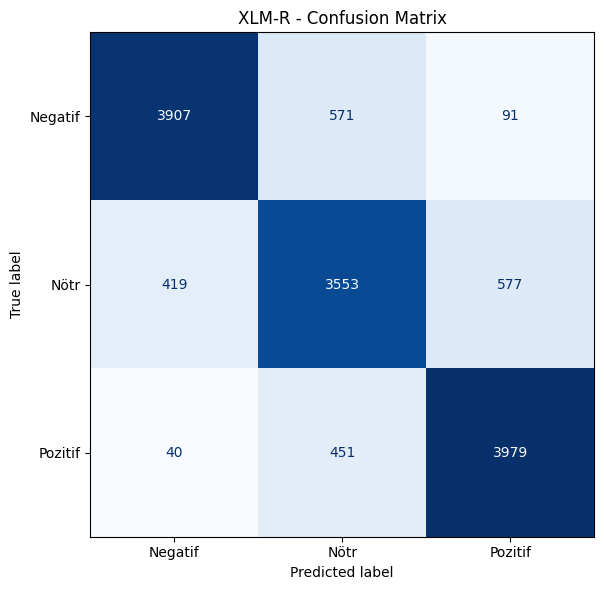

Saved: /content/xlmr_confusion_matrix.png


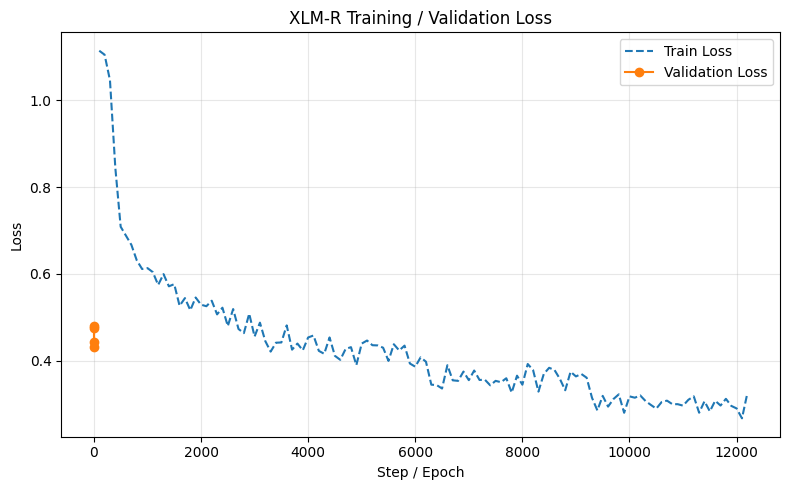

Saved: /content/xlmr_loss_curve.png

FINAL SUMMARY
Model      Task  Accuracy    F1  Precision  Recall  Inference(ms)  TrainSeconds  TrainSize  ValSize  TestSize
XLM-R Sentiment     84.18 84.21      84.26   84.21            0.7         634.0      48915     5436     13588

Saved: /content/xlmr_results.csv


In [ ]:
# ============================================================
# CLEAN XLM-R SENTIMENT PIPELINE - FINAL VERSION
# TRSAv1 + Golden Dataset
# 3-class sentiment only
# ============================================================

!pip install -q -U transformers[sentencepiece] datasets scikit-learn accelerate openpyxl safetensors

import os
import re
import gc
import math
import json
import time
import random
import shutil
import warnings
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import transformers

from inspect import signature
from datasets import Dataset, load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    EarlyStoppingCallback,
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

warnings.filterwarnings("ignore")

# ============================================================
# 0) SETTINGS
# ============================================================

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")
print("transformers version:", transformers.__version__)
if DEVICE == "cuda":
    print(f"GPU   : {torch.cuda.get_device_name(0)}")
    print(f"VRAM  : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

MODEL_NAME = "xlm-roberta-base"
GOLDEN_PATH = "/content/golden_dataset.xlsx"

MAX_LENGTH = 128
TRAIN_BATCH_SIZE = 16
EVAL_BATCH_SIZE = 64
NUM_EPOCHS = 4
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.1
EARLY_STOPPING_PATIENCE = 2

TRSA_SAMPLE_PER_CLASS = 20000
TEST_SIZE = 0.20
VAL_SIZE_WITHIN_TRAIN = 0.10

OUTPUT_DIR = "/content/xlmr_sentiment_run"
BEST_MODEL_DIR = "/content/xlmr_sentiment_best"

CLEAR_HF_CACHE_FIRST = False

LABEL_MAP_3 = {
    "Negative": 0, "negative": 0, "Olumsuz": 0, "olumsuz": 0,
    "Neutral": 1, "neutral": 1, "Nötr": 1, "nötr": 1, "Notr": 1, "notr": 1,
    "Positive": 2, "positive": 2, "Olumlu": 2, "olumlu": 2,
    0: 0, 1: 1, 2: 2,
}
ID2LABEL = {0: "Negative", 1: "Neutral", 2: "Positive"}
LABEL2ID = {"Negative": 0, "Neutral": 1, "Positive": 2}
CLASS_NAMES = ["Negatif", "Nötr", "Pozitif"]

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(BEST_MODEL_DIR, exist_ok=True)

# ============================================================
# 1) OPTIONAL CACHE CLEAN
# ============================================================

def clear_hf_model_cache(model_name):
    safe_name = model_name.replace("/", "--")
    cache_dir = os.path.expanduser(f"~/.cache/huggingface/hub/models--{safe_name}")
    if os.path.exists(cache_dir):
        shutil.rmtree(cache_dir)
        print(f"Deleted HF cache: {cache_dir}")
    else:
        print("HF cache not found, skipping.")

if CLEAR_HF_CACHE_FIRST:
    clear_hf_model_cache(MODEL_NAME)

# ============================================================
# 2) TEXT CLEANING
# ============================================================

def normalize_text(text):
    text = str(text)
    text = text.replace("\u200b", " ")
    text = text.replace("\xa0", " ")
    text = re.sub(r"\s+", " ", text).strip()
    return text

def is_bad_text(text):
    if text is None:
        return True

    t = normalize_text(text)

    if t == "":
        return True
    if t.lower() in {"nan", "none", "null"}:
        return True
    if len(t) < 3:
        return True
    if re.fullmatch(r"[\d\W_]+", t):
        return True
    if t.lower().startswith("lorem ipsum"):
        return True

    return False

def make_text_norm(series):
    return (
        series.astype(str)
        .str.lower()
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
    )

# ============================================================
# 3) DATA CLEANING / AUDIT
# ============================================================

def clean_standard_df(df, text_col, label_col, source_name, drop_conflicts=True):
    df = df.copy()

    df[text_col] = df[text_col].astype(str).map(normalize_text)
    df = df[~df[text_col].map(is_bad_text)].copy()

    df[label_col] = df[label_col].map(LABEL_MAP_3)
    df = df.dropna(subset=[label_col]).copy()
    df[label_col] = df[label_col].astype(int)

    df = df.rename(columns={text_col: "text", label_col: "label"})
    df["source"] = source_name
    df["text_norm"] = make_text_norm(df["text"])

    df = df.drop_duplicates(subset=["text_norm", "label"]).reset_index(drop=True)

    if drop_conflicts:
        label_counts = df.groupby("text_norm")["label"].nunique()
        conflict_keys = set(label_counts[label_counts > 1].index)

        if conflict_keys:
            conflict_df = df[df["text_norm"].isin(conflict_keys)].copy()
            conflict_path = f"/content/flagged_conflicts_{source_name.lower()}.csv"
            conflict_df.to_csv(conflict_path, index=False, encoding="utf-8-sig")
            print(f"{source_name}: conflicting texts removed = {len(conflict_df)}")
            print(f"Saved: {conflict_path}")

            df = df[~df["text_norm"].isin(conflict_keys)].copy()

    return df[["text", "label", "source", "text_norm"]].reset_index(drop=True)

def audit_dataset(df, name):
    print(f"\n{'='*70}")
    print(f"AUDIT | {name}")
    print(f"{'='*70}")
    print(f"Total: {len(df)}")
    print(f"Label dist: {df['label'].value_counts().sort_index().to_dict()}")

    dup_count = df["text_norm"].duplicated().sum()
    print(f"Exact duplicate text: {dup_count}")

    conflict = (
        df.groupby("text_norm")["label"]
        .nunique()
        .reset_index(name="n_labels")
    )
    conflict = conflict[conflict["n_labels"] > 1]
    print(f"Conflicting duplicate text: {len(conflict)}")

def remove_cross_source_duplicates(df):
    df = df.copy()
    df["source_priority"] = df["source"].map({"golden": 0, "trsa": 1}).fillna(9)
    df = df.sort_values(["text_norm", "source_priority"]).reset_index(drop=True)

    before = len(df)
    df = df.drop_duplicates(subset=["text_norm"], keep="first").reset_index(drop=True)
    after = len(df)

    print(f"Cross-source duplicates removed: {before - after}")
    return df.drop(columns=["source_priority"])

# ============================================================
# 4) LOAD DATASETS
# ============================================================

def load_golden(path):
    df = pd.read_excel(path)
    df.columns = df.columns.str.strip()

    required = {"Review", "Sentiment"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Golden dataset missing columns: {missing}")

    df = clean_standard_df(
        df=df,
        text_col="Review",
        label_col="Sentiment",
        source_name="golden",
        drop_conflicts=True
    )

    print(f"Golden loaded: {len(df)} | {df['label'].value_counts().sort_index().to_dict()}")
    return df

def load_trsa(sample_per_class=20000):
    print(f"TRSAv1 loading... sample_per_class={sample_per_class}")
    ds = load_dataset("maydogan/Turkish_SentimentAnalysis_TRSAv1", split="train")
    df = ds.to_pandas()

    print(f"TRSAv1 columns: {df.columns.tolist()}")

    required = {"review", "score"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"TRSAv1 expected columns missing: {missing}")

    df = clean_standard_df(
        df=df,
        text_col="review",
        label_col="score",
        source_name="trsa",
        drop_conflicts=True
    )

    if sample_per_class is not None:
        df = (
            df.groupby("label", group_keys=False)
              .apply(lambda x: x.sample(min(len(x), sample_per_class), random_state=SEED))
              .reset_index(drop=True)
        )

    print(f"TRSAv1 loaded: {len(df)} | {df['label'].value_counts().sort_index().to_dict()}")
    return df

# ============================================================
# 5) BUILD CLEAN DATASET
# ============================================================

def build_sentiment_dataset(golden_path, sample_per_class=20000):
    print("\n--- Loading datasets ---")
    df_golden = load_golden(golden_path)
    df_trsa = load_trsa(sample_per_class=sample_per_class)

    audit_dataset(df_golden, "GOLDEN")
    audit_dataset(df_trsa, "TRSA")

    df_combined = pd.concat([df_golden, df_trsa], ignore_index=True)
    df_combined = remove_cross_source_duplicates(df_combined)

    print(f"\nCombined total: {len(df_combined)}")
    print(f"Combined label dist: {df_combined['label'].value_counts().sort_index().to_dict()}")
    print(f"Sources: {df_combined['source'].value_counts().to_dict()}")

    return df_combined

# ============================================================
# 6) TRAIN / VAL / TEST SPLIT
# ============================================================

def split_train_val_test(df):
    df_train_full, df_test = train_test_split(
        df,
        test_size=TEST_SIZE,
        random_state=SEED,
        stratify=df["label"],
    )

    df_train, df_val = train_test_split(
        df_train_full,
        test_size=VAL_SIZE_WITHIN_TRAIN,
        random_state=SEED,
        stratify=df_train_full["label"],
    )

    overlap_train_test = set(df_train["text_norm"]) & set(df_test["text_norm"])
    overlap_train_val = set(df_train["text_norm"]) & set(df_val["text_norm"])
    overlap_val_test = set(df_val["text_norm"]) & set(df_test["text_norm"])

    print("\n--- Split summary ---")
    print(f"Train: {len(df_train)}")
    print(f"Val  : {len(df_val)}")
    print(f"Test : {len(df_test)}")
    print(f"Train label dist: {df_train['label'].value_counts().sort_index().to_dict()}")
    print(f"Val   label dist: {df_val['label'].value_counts().sort_index().to_dict()}")
    print(f"Test  label dist: {df_test['label'].value_counts().sort_index().to_dict()}")

    assert len(overlap_train_test) == 0, f"Leakage train-test: {len(overlap_train_test)}"
    assert len(overlap_train_val) == 0, f"Leakage train-val: {len(overlap_train_val)}"
    assert len(overlap_val_test) == 0, f"Leakage val-test: {len(overlap_val_test)}"
    print("Leakage check: OK")

    return (
        df_train.reset_index(drop=True),
        df_val.reset_index(drop=True),
        df_test.reset_index(drop=True),
    )

# ============================================================
# 7) TOKENIZATION
# ============================================================

def df_to_hf_dataset(df):
    return Dataset.from_pandas(
        df[["text", "label"]].reset_index(drop=True),
        preserve_index=False
    )

def tokenize_dataset(ds, tokenizer):
    def tokenize_batch(batch):
        return tokenizer(
            batch["text"],
            truncation=True,
            max_length=MAX_LENGTH,
        )
    return ds.map(tokenize_batch, batched=True)

# ============================================================
# 8) METRICS
# ============================================================

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    return {
        "accuracy": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds, average="macro", zero_division=0),
        "precision": precision_score(labels, preds, average="macro", zero_division=0),
        "recall": recall_score(labels, preds, average="macro", zero_division=0),
    }

# ============================================================
# 9) MODEL LOADING
# ============================================================

def load_clean_model_and_tokenizer(model_name):
    tokenizer = AutoTokenizer.from_pretrained(model_name)

    try:
        model = AutoModelForSequenceClassification.from_pretrained(
            model_name,
            num_labels=3,
            id2label=ID2LABEL,
            label2id=LABEL2ID,
            use_safetensors=True,
        ).to(DEVICE)
        print("Model loaded with safetensors.")
    except Exception as e:
        print("Safetensors load failed, falling back to default loading.")
        print("Reason:", str(e))
        model = AutoModelForSequenceClassification.from_pretrained(
            model_name,
            num_labels=3,
            id2label=ID2LABEL,
            label2id=LABEL2ID,
        ).to(DEVICE)

    return tokenizer, model

# ============================================================
# 10) TRAIN XLM-R
# ============================================================

def build_training_args(train_len):
    steps_per_epoch = max(1, math.ceil(train_len / TRAIN_BATCH_SIZE))
    total_steps = steps_per_epoch * NUM_EPOCHS
    warmup_steps = int(total_steps * WARMUP_RATIO)

    sig = signature(TrainingArguments.__init__).parameters
    kwargs = {}

    kwargs["output_dir"] = OUTPUT_DIR
    kwargs["num_train_epochs"] = NUM_EPOCHS

    if "per_device_train_batch_size" in sig:
        kwargs["per_device_train_batch_size"] = TRAIN_BATCH_SIZE
    elif "per_gpu_train_batch_size" in sig:
        kwargs["per_gpu_train_batch_size"] = TRAIN_BATCH_SIZE

    if "per_device_eval_batch_size" in sig:
        kwargs["per_device_eval_batch_size"] = EVAL_BATCH_SIZE
    elif "per_gpu_eval_batch_size" in sig:
        kwargs["per_gpu_eval_batch_size"] = EVAL_BATCH_SIZE

    if "learning_rate" in sig:
        kwargs["learning_rate"] = LEARNING_RATE
    if "weight_decay" in sig:
        kwargs["weight_decay"] = WEIGHT_DECAY
    if "warmup_steps" in sig:
        kwargs["warmup_steps"] = warmup_steps
    if "max_grad_norm" in sig:
        kwargs["max_grad_norm"] = 1.0
    if "seed" in sig:
        kwargs["seed"] = SEED
    if "fp16" in sig:
        kwargs["fp16"] = (DEVICE == "cuda")
    if "logging_steps" in sig:
        kwargs["logging_steps"] = 100
    if "report_to" in sig:
        kwargs["report_to"] = "none"
    if "save_total_limit" in sig:
        kwargs["save_total_limit"] = 2
    if "save_safetensors" in sig:
        kwargs["save_safetensors"] = True

    if "eval_strategy" in sig:
        kwargs["eval_strategy"] = "epoch"
    elif "evaluation_strategy" in sig:
        kwargs["evaluation_strategy"] = "epoch"
    elif "evaluate_during_training" in sig:
        kwargs["evaluate_during_training"] = True
    elif "do_eval" in sig:
        kwargs["do_eval"] = True

    if "save_strategy" in sig:
        kwargs["save_strategy"] = "epoch"
    elif "save_steps" in sig:
        kwargs["save_steps"] = steps_per_epoch

    if "load_best_model_at_end" in sig:
        kwargs["load_best_model_at_end"] = True
    if "metric_for_best_model" in sig:
        kwargs["metric_for_best_model"] = "f1"
    if "greater_is_better" in sig:
        kwargs["greater_is_better"] = True

    args = TrainingArguments(**kwargs)

    print("TrainingArguments keys used:")
    print(sorted(kwargs.keys()))

    return args

def train_xlmr(df_train, df_val):
    tokenizer, model = load_clean_model_and_tokenizer(MODEL_NAME)

    train_ds = tokenize_dataset(df_to_hf_dataset(df_train), tokenizer)
    val_ds = tokenize_dataset(df_to_hf_dataset(df_val), tokenizer)

    args = build_training_args(len(train_ds))

    trainer_kwargs = dict(
        model=model,
        args=args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        data_collator=DataCollatorWithPadding(tokenizer=tokenizer),
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=EARLY_STOPPING_PATIENCE)],
    )

    trainer_sig = signature(Trainer.__init__)

    if "processing_class" in trainer_sig.parameters:
        trainer_kwargs["processing_class"] = tokenizer
    elif "tokenizer" in trainer_sig.parameters:
        trainer_kwargs["tokenizer"] = tokenizer

    trainer = Trainer(**trainer_kwargs)

    print("\n--- Training XLM-R ---")
    start = time.time()
    trainer.train()
    train_seconds = round(time.time() - start, 1)

    print(f"Training finished in {train_seconds} sec")

    trainer.save_model(BEST_MODEL_DIR)
    tokenizer.save_pretrained(BEST_MODEL_DIR)
    print(f"Best model saved to: {BEST_MODEL_DIR}")

    return trainer, tokenizer, train_seconds

# ============================================================
# 11) EVALUATE ON TEST
# ============================================================

def evaluate_on_test(trainer, tokenizer, df_test, train_seconds):
    test_ds = tokenize_dataset(df_to_hf_dataset(df_test), tokenizer)

    print("\n--- Final test evaluation ---")
    pred_output = trainer.predict(test_ds)

    logits = pred_output.predictions
    labels = pred_output.label_ids
    preds = np.argmax(logits, axis=-1)

    metrics = {
        "accuracy": round(accuracy_score(labels, preds) * 100, 2),
        "f1": round(f1_score(labels, preds, average="macro", zero_division=0) * 100, 2),
        "precision": round(precision_score(labels, preds, average="macro", zero_division=0) * 100, 2),
        "recall": round(recall_score(labels, preds, average="macro", zero_division=0) * 100, 2),
        "train_seconds": train_seconds,
    }

    model = trainer.model
    model.eval()
    sample_texts = df_test["text"].head(100).tolist()
    t0 = time.time()

    for i in range(0, len(sample_texts), 32):
        enc = tokenizer(
            sample_texts[i:i+32],
            truncation=True,
            max_length=MAX_LENGTH,
            padding=True,
            return_tensors="pt"
        ).to(DEVICE)
        with torch.no_grad():
            _ = model(**enc)

    inf_ms = round((time.time() - t0) / max(len(sample_texts), 1) * 1000, 2)
    metrics["inference_ms_per_text"] = inf_ms

    print(json.dumps(metrics, indent=2, ensure_ascii=False))

    result_df = pd.DataFrame({
        "text": df_test["text"].values,
        "label": labels,
        "pred": preds,
    })
    result_df["label_name"] = result_df["label"].map({0: "Negatif", 1: "Nötr", 2: "Pozitif"})
    result_df["pred_name"] = result_df["pred"].map({0: "Negatif", 1: "Nötr", 2: "Pozitif"})
    result_df["correct"] = (result_df["label"] == result_df["pred"]).astype(int)

    result_df.to_csv("/content/xlmr_test_predictions.csv", index=False, encoding="utf-8-sig")
    print("Saved: /content/xlmr_test_predictions.csv")

    wrong_df = result_df[result_df["correct"] == 0].copy()
    wrong_df.to_csv("/content/xlmr_errors.csv", index=False, encoding="utf-8-sig")
    print("Saved: /content/xlmr_errors.csv")

    return metrics, result_df, wrong_df

# ============================================================
# 12) PLOTS
# ============================================================

def plot_confusion(result_df):
    cm = confusion_matrix(result_df["label"], result_df["pred"])
    fig, ax = plt.subplots(figsize=(7, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title("XLM-R - Confusion Matrix")
    plt.tight_layout()
    plt.savefig("/content/xlmr_confusion_matrix.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: /content/xlmr_confusion_matrix.png")

def plot_loss_curve(trainer):
    log_history = trainer.state.log_history

    train_logs = [x for x in log_history if "loss" in x and "eval_loss" not in x]
    eval_logs = [x for x in log_history if "eval_loss" in x]

    train_steps = [x.get("step", i + 1) for i, x in enumerate(train_logs)]
    train_losses = [x["loss"] for x in train_logs]

    eval_epochs = [x.get("epoch", i + 1) for i, x in enumerate(eval_logs)]
    eval_losses = [x["eval_loss"] for x in eval_logs]

    plt.figure(figsize=(8, 5))
    if train_losses:
        plt.plot(train_steps, train_losses, label="Train Loss", linestyle="--")
    if eval_losses:
        plt.plot(eval_epochs, eval_losses, label="Validation Loss", marker="o")
    plt.title("XLM-R Training / Validation Loss")
    plt.xlabel("Step / Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig("/content/xlmr_loss_curve.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: /content/xlmr_loss_curve.png")

# ============================================================
# 13) RUN ALL
# ============================================================

df_combined = build_sentiment_dataset(
    golden_path=GOLDEN_PATH,
    sample_per_class=TRSA_SAMPLE_PER_CLASS
)

df_combined.drop(columns=["text_norm"]).to_csv(
    "/content/combined_clean_sentiment.csv",
    index=False,
    encoding="utf-8-sig"
)
print("Saved: /content/combined_clean_sentiment.csv")

df_train, df_val, df_test = split_train_val_test(df_combined)

df_train.drop(columns=["text_norm"]).to_csv("/content/sentiment_train_clean.csv", index=False, encoding="utf-8-sig")
df_val.drop(columns=["text_norm"]).to_csv("/content/sentiment_val_clean.csv", index=False, encoding="utf-8-sig")
df_test.drop(columns=["text_norm"]).to_csv("/content/sentiment_test_clean.csv", index=False, encoding="utf-8-sig")
print("Saved: /content/sentiment_train_clean.csv")
print("Saved: /content/sentiment_val_clean.csv")
print("Saved: /content/sentiment_test_clean.csv")

trainer, tokenizer, train_seconds = train_xlmr(df_train, df_val)
metrics, result_df, wrong_df = evaluate_on_test(trainer, tokenizer, df_test, train_seconds)

plot_confusion(result_df)
plot_loss_curve(trainer)

summary_df = pd.DataFrame([{
    "Model": "XLM-R",
    "Task": "Sentiment",
    "Accuracy": metrics["accuracy"],
    "F1": metrics["f1"],
    "Precision": metrics["precision"],
    "Recall": metrics["recall"],
    "Inference(ms)": metrics["inference_ms_per_text"],
    "TrainSeconds": metrics["train_seconds"],
    "TrainSize": len(df_train),
    "ValSize": len(df_val),
    "TestSize": len(df_test),
}])

summary_df.to_csv("/content/xlmr_results.csv", index=False, encoding="utf-8-sig")
print("\nFINAL SUMMARY")
print(summary_df.to_string(index=False))
print("\nSaved: /content/xlmr_results.csv")

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

In [ ]:
import os
import glob
import pandas as pd

# ============================================================
# 1) DOSYALARI BUL
# ============================================================

SEARCH_ROOTS = [
    "/content/drive_new/MyDrive",
    "/content/gdrive/MyDrive",
    "/content/drive/MyDrive",
    "/content"
]

def find_all_files(filename_pattern):
    found = []
    for root in SEARCH_ROOTS:
        if os.path.exists(root):
            found.extend(glob.glob(os.path.join(root, "**", filename_pattern), recursive=True))
    return found

cm_files = find_all_files("*_confusion_matrix.csv")

print("Bulunan confusion matrix dosyaları:")
for f in cm_files:
    print(f)

# ============================================================
# 2) GELENEKSEL YÖNTEMLERİ FİLTRELE
# ============================================================

traditional_keywords = [
    "Logistic_Regression",
    "Linear_SVM",
    "Naive_Bayes",
    "Random_Forest"
]

traditional_cm_files = [
    f for f in cm_files
    if any(k.lower() in os.path.basename(f).lower() for k in traditional_keywords)
]

print("\nGeleneksel yöntem confusion matrix dosyaları:")
for f in traditional_cm_files:
    print(f)

# ============================================================
# 3) EN ÇOK KARIŞAN SINIFLARI ÇIKAR
# ============================================================

all_rows = []

for file_path in traditional_cm_files:
    model_name = os.path.basename(file_path).replace("_confusion_matrix.csv", "")

    df_cm = pd.read_csv(file_path, index_col=0)

    # Satır ve sütun isimlerini al
    true_labels = list(df_cm.index)
    pred_labels = list(df_cm.columns)

    print(f"\n{'='*60}")
    print(model_name)
    print(df_cm)

    for i, true_label in enumerate(true_labels):
        row_total = df_cm.iloc[i].sum()

        for j, pred_label in enumerate(pred_labels):
            if i == j:
                continue

            count = int(df_cm.iloc[i, j])
            ratio = (count / row_total * 100) if row_total > 0 else 0

            all_rows.append({
                "Model": model_name,
                "Gerçek Sınıf": true_label,
                "Tahmin Edilen Sınıf": pred_label,
                "Karışma Sayısı": count,
                "Satır İçi Oran (%)": round(ratio, 2)
            })

confusion_summary_df = pd.DataFrame(all_rows)
confusion_summary_df = confusion_summary_df.sort_values(
    by=["Model", "Karışma Sayısı", "Satır İçi Oran (%)"],
    ascending=[True, False, False]
).reset_index(drop=True)

print("\n=== EN ÇOK KARIŞAN SINIFLAR ===")
print(confusion_summary_df.to_string(index=False))

# ============================================================
# 4) KAYDET
# ============================================================

output_path = "traditional_models_confusion_summary.csv"
confusion_summary_df.to_csv(output_path, index=False, encoding="utf-8-sig")
print(f"\nKaydedildi: {output_path}")

Bulunan confusion matrix dosyaları:
/content/drive_new/MyDrive/model_outputs_backup_20260421_200327/traditional_ml_results/Logistic_Regression_confusion_matrix.csv
/content/drive_new/MyDrive/model_outputs_backup_20260421_200327/traditional_ml_results/Linear_SVM_confusion_matrix.csv
/content/drive_new/MyDrive/model_outputs_backup_20260421_200327/traditional_ml_results/Naive_Bayes_confusion_matrix.csv
/content/drive_new/MyDrive/model_outputs_backup_20260421_200327/traditional_ml_results/Random_Forest_confusion_matrix.csv
/content/drive_new/MyDrive/model_outputs_backup_20260421_200327/auto_found/traditional_ml_results/Logistic_Regression_confusion_matrix.csv
/content/drive_new/MyDrive/model_outputs_backup_20260421_200327/auto_found/traditional_ml_results/Linear_SVM_confusion_matrix.csv
/content/drive_new/MyDrive/model_outputs_backup_20260421_200327/auto_found/traditional_ml_results/Naive_Bayes_confusion_matrix.csv
/content/drive_new/MyDrive/model_outputs_backup_20260421_200327/auto_found/

In [ ]:
import os
import torch
import pandas as pd
from transformers import AutoTokenizer, AutoModelForSequenceClassification

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

ID2LABEL_TR = {
    0: "Negatif",
    1: "Nötr",
    2: "Pozitif"
}

LABEL2ID_TR = {
    "Negatif": 0,
    "Nötr": 1,
    "Pozitif": 2
}

# ------------------------------------------------------------
# 1) SAVED MODEL PATHS
# ------------------------------------------------------------
MODEL_PATHS = {
    "BERTurk": "/content/berturk_sentiment_best",
    "mBERT": "/content/mbert_sentiment_best",
    "XLM-R": "/content/xlmr_sentiment_best",
}

# ------------------------------------------------------------
# 2) IRONIC TEST SENTENCES
# gold_label = gerçek sentiment
# ------------------------------------------------------------
ironic_samples = [
    {"text": "Harika, kargom yine üç gün gecikti, bayıldım gerçekten.", "gold_label": "Negatif"},
    {"text": "Mükemmel hizmet, müşteri temsilcisi yüzüme telefonu kapattı.", "gold_label": "Negatif"},
    {"text": "Süper kalite, iki kullanımda parçalandı.", "gold_label": "Negatif"},
    {"text": "Teşekkürler, sayenizde bütün günüm mahvoldu.", "gold_label": "Negatif"},
    {"text": "Ne kadar da düşüncelisiniz, bozuk ürünü göndermeyi unutmamışsınız.", "gold_label": "Negatif"},
    {"text": "Muhteşem gerçekten, siparişim eksik geldi.", "gold_label": "Negatif"},
    {"text": "Şahane, tam da ihtiyacım olan şey arızalı bir cihazdı.", "gold_label": "Negatif"},
    {"text": "Bravo, bu kadar kötü paketlemeyi başarmak yetenek ister.", "gold_label": "Negatif"},
    {"text": "Aferin size, yine yanlış ürün göndermişsiniz.", "gold_label": "Negatif"},
    {"text": "Gerçekten inanılmazsınız, iade sürecini daha da zorlaştırmışsınız.", "gold_label": "Negatif"},

    {"text": "Yok artık, bu kez gerçekten beklediğimden iyi çıktı.", "gold_label": "Pozitif"},
    {"text": "Şaşırdım doğrusu, bu kadar güzel olmasını beklemiyordum.", "gold_label": "Pozitif"},
    {"text": "Vay canına, sonunda sorunsuz çalışan bir ürün gelmiş.", "gold_label": "Pozitif"},
    {"text": "İnanılmaz ama gerçek, bu sefer kalite gerçekten çok iyi.", "gold_label": "Pozitif"},

    {"text": "Evet, geldi işte, duruyor öyle.", "gold_label": "Nötr"},
    {"text": "Kutu açıldı, ürün içinden çıktı, şu an masada.", "gold_label": "Nötr"},
]

test_df = pd.DataFrame(ironic_samples)
test_df["gold_id"] = test_df["gold_label"].map(LABEL2ID_TR)

# ------------------------------------------------------------
# 3) LOAD MODEL + PREDICT
# ------------------------------------------------------------
def load_model_and_tokenizer(model_path):
    tokenizer = AutoTokenizer.from_pretrained(model_path)
    model = AutoModelForSequenceClassification.from_pretrained(model_path).to(DEVICE)
    model.eval()
    return tokenizer, model

def predict_texts(model, tokenizer, texts, max_length=128, batch_size=16):
    preds = []

    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        enc = tokenizer(
            batch,
            truncation=True,
            max_length=max_length,
            padding=True,
            return_tensors="pt"
        ).to(DEVICE)

        with torch.no_grad():
            outputs = model(**enc)
            batch_preds = torch.argmax(outputs.logits, dim=-1).cpu().tolist()

        preds.extend(batch_preds)

    return preds

# ------------------------------------------------------------
# 4) RUN ALL MODELS
# ------------------------------------------------------------
all_results = test_df.copy()

for model_name, model_path in MODEL_PATHS.items():
    if not os.path.exists(model_path):
        print(f"UYARI: {model_name} path bulunamadı -> {model_path}")
        continue

    tokenizer, model = load_model_and_tokenizer(model_path)
    pred_ids = predict_texts(model, tokenizer, all_results["text"].tolist())

    all_results[f"{model_name}_pred_id"] = pred_ids
    all_results[f"{model_name}_pred"] = [ID2LABEL_TR[x] for x in pred_ids]
    all_results[f"{model_name}_correct"] = (
        all_results[f"{model_name}_pred_id"] == all_results["gold_id"]
    )

# ------------------------------------------------------------
# 5) SHOW FULL TABLE
# ------------------------------------------------------------
display_cols = ["text", "gold_label"]

for name in MODEL_PATHS.keys():
    if f"{name}_pred" in all_results.columns:
        display_cols.extend([f"{name}_pred", f"{name}_correct"])

print("\nIRONIC SENTENCE TEST RESULTS\n")
display(all_results[display_cols])

# ------------------------------------------------------------
# 6) MODEL-LEVEL SUMMARY
# ------------------------------------------------------------
summary_rows = []

for name in MODEL_PATHS.keys():
    if f"{name}_correct" in all_results.columns:
        acc = all_results[f"{name}_correct"].mean() * 100
        summary_rows.append({
            "Model": name,
            "IronicTestAccuracy": round(acc, 2),
            "CorrectCount": int(all_results[f"{name}_correct"].sum()),
            "Total": len(all_results)
        })

summary_df = pd.DataFrame(summary_rows).sort_values("IronicTestAccuracy", ascending=False)

print("\nMODEL SUMMARY ON IRONIC SENTENCES\n")
display(summary_df)

# ------------------------------------------------------------
# 7) SAVE
# ------------------------------------------------------------
all_results.to_csv("/content/ironic_sentence_model_comparison.csv", index=False, encoding="utf-8-sig")
summary_df.to_csv("/content/ironic_sentence_summary.csv", index=False, encoding="utf-8-sig")

print("Saved: /content/ironic_sentence_model_comparison.csv")
print("Saved: /content/ironic_sentence_summary.csv")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


IRONIC SENTENCE TEST RESULTS



,text,gold_label,BERTurk_pred,BERTurk_correct,mBERT_pred,mBERT_correct,XLM-R_pred,XLM-R_correct
0,"Harika, kargom yine üç gün gecikti, bayıldım g...",Negatif,Negatif,True,Negatif,True,Negatif,True
1,"Mükemmel hizmet, müşteri temsilcisi yüzüme tel...",Negatif,Pozitif,False,Pozitif,False,Pozitif,False
2,"Süper kalite, iki kullanımda parçalandı.",Negatif,Pozitif,False,Pozitif,False,Negatif,True
3,"Teşekkürler, sayenizde bütün günüm mahvoldu.",Negatif,Negatif,True,Negatif,True,Negatif,True
4,"Ne kadar da düşüncelisiniz, bozuk ürünü gönder...",Negatif,Negatif,True,Negatif,True,Negatif,True
5,"Muhteşem gerçekten, siparişim eksik geldi.",Negatif,Negatif,True,Pozitif,False,Negatif,True
6,"Şahane, tam da ihtiyacım olan şey arızalı bir ...",Negatif,Pozitif,False,Pozitif,False,Pozitif,False
7,"Bravo, bu kadar kötü paketlemeyi başarmak yete...",Negatif,Negatif,True,Negatif,True,Negatif,True
8,"Aferin size, yine yanlış ürün göndermişsiniz.",Negatif,Negatif,True,Negatif,True,Negatif,True
9,"Gerçekten inanılmazsınız, iade sürecini daha d...",Negatif,Negatif,True,Pozitif,False,Negatif,True



MODEL SUMMARY ON IRONIC SENTENCES



,Model,IronicTestAccuracy,CorrectCount,Total
2,XLM-R,68.75,11,16
1,mBERT,62.50,10,16
0,BERTurk,56.25,9,16


Saved: /content/ironic_sentence_model_comparison.csv
Saved: /content/ironic_sentence_summary.csv


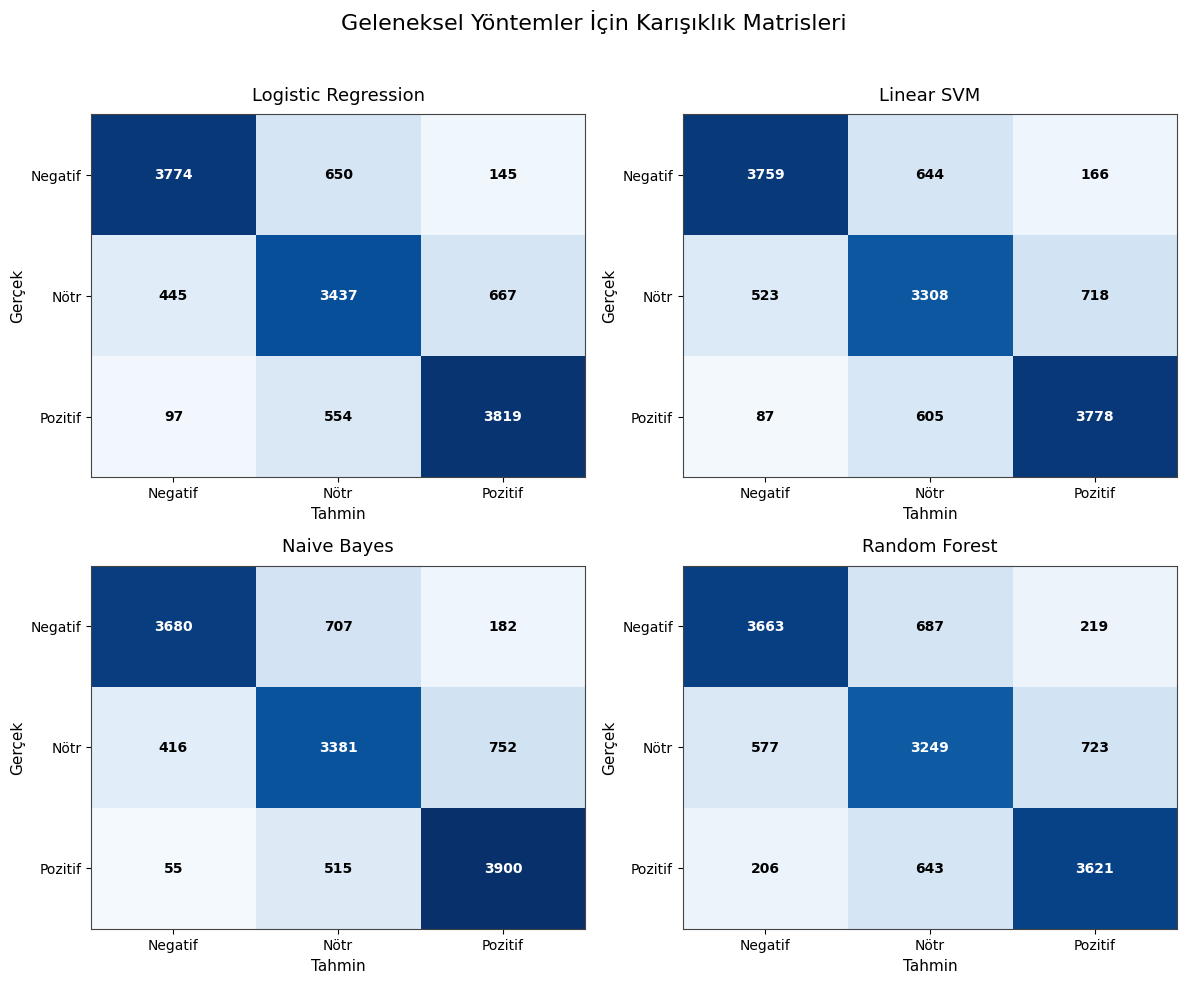

Kaydedildi: /content/drive_new/MyDrive/model_outputs_backup_20260421_200327/traditional_ml_results/traditional_confusion_matrix_visuals_no_colorbar/traditional_models_confusion_matrices_combined_no_colorbar.png


In [ ]:
import os
import glob
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1) DOSYALARI OTOMATİK BUL
# ============================================================

SEARCH_ROOTS = [
    "/content/drive_new/MyDrive",
    "/content/gdrive/MyDrive",
    "/content/drive/MyDrive",
    "/content"
]

def find_first_file(filename):
    for root in SEARCH_ROOTS:
        if os.path.exists(root):
            matches = glob.glob(os.path.join(root, "**", filename), recursive=True)
            if matches:
                return matches[0]
    return None

cm_files = {
    "Logistic Regression": find_first_file("Logistic_Regression_confusion_matrix.csv"),
    "Linear SVM": find_first_file("Linear_SVM_confusion_matrix.csv"),
    "Naive Bayes": find_first_file("Naive_Bayes_confusion_matrix.csv"),
    "Random Forest": find_first_file("Random_Forest_confusion_matrix.csv"),
}

available_files = {k: v for k, v in cm_files.items() if v is not None}
if not available_files:
    raise FileNotFoundError("Hiçbir geleneksel yöntem confusion_matrix.csv dosyası bulunamadı.")

first_path = list(available_files.values())[0]
OUTPUT_DIR = os.path.join(os.path.dirname(first_path), "traditional_confusion_matrix_visuals_no_colorbar")
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ============================================================
# 2) LABEL DÜZENLEME
# ============================================================

def normalize_label(x):
    x = str(x).strip().lower()
    mapping = {
        "0": "Negatif",
        "1": "Nötr",
        "2": "Pozitif",
        "negative": "Negatif",
        "neutral": "Nötr",
        "positive": "Pozitif",
        "negatif": "Negatif",
        "nötr": "Nötr",
        "notr": "Nötr",
        "pozitif": "Pozitif"
    }
    return mapping.get(x, str(x))

# ============================================================
# 3) GÖRSEL STİL
# ============================================================

plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["axes.edgecolor"] = "#444444"
plt.rcParams["axes.linewidth"] = 0.8
plt.rcParams["font.size"] = 11

CMAP_NAME = "Blues"

# ============================================================
# 4) MATRİSLERİ YÜKLE
# ============================================================

loaded_matrices = {}

for model_name, file_path in available_files.items():
    df_cm = pd.read_csv(file_path, index_col=0)

    df_cm.index = [normalize_label(x) for x in df_cm.index]
    df_cm.columns = [normalize_label(x) for x in df_cm.columns]

    desired_order = ["Negatif", "Nötr", "Pozitif"]
    existing_rows = [x for x in desired_order if x in df_cm.index]
    existing_cols = [x for x in desired_order if x in df_cm.columns]

    if len(existing_rows) == len(df_cm.index):
        df_cm = df_cm.loc[existing_rows, existing_cols]

    loaded_matrices[model_name] = df_cm

# ============================================================
# 5) TÜM MODELLERİ TEK FIGURE'DA GÖSTER (COLORBAR YOK)
# ============================================================

n_models = len(loaded_matrices)
ncols = 2
nrows = math.ceil(n_models / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(12, 5 * nrows))
axes = np.array(axes).reshape(-1)

global_max = max(df.values.max() for df in loaded_matrices.values())

for ax, (model_name, df_cm) in zip(axes, loaded_matrices.items()):
    ax.imshow(
        df_cm.values,
        cmap=CMAP_NAME,
        aspect="auto",
        vmin=0,
        vmax=global_max
    )

    ax.set_xticks(np.arange(len(df_cm.columns)))
    ax.set_xticklabels(df_cm.columns, fontsize=10)

    ax.set_yticks(np.arange(len(df_cm.index)))
    ax.set_yticklabels(df_cm.index, fontsize=10)

    ax.set_title(model_name, fontsize=13, pad=10)
    ax.set_xlabel("Tahmin", fontsize=11)
    ax.set_ylabel("Gerçek", fontsize=11)

    threshold = global_max / 2 if global_max > 0 else 0

    for i in range(df_cm.shape[0]):
        for j in range(df_cm.shape[1]):
            val = int(df_cm.iloc[i, j])
            txt_color = "white" if val > threshold else "black"
            ax.text(
                j, i, str(val),
                ha="center", va="center",
                color=txt_color,
                fontsize=10,
                fontweight="bold"
            )

for k in range(len(loaded_matrices), len(axes)):
    axes[k].axis("off")

fig.suptitle("Geleneksel Yöntemler İçin Karışıklık Matrisleri", fontsize=16, y=0.98)

plt.tight_layout(rect=[0, 0, 1, 0.96])

combined_path = os.path.join(OUTPUT_DIR, "traditional_models_confusion_matrices_combined_no_colorbar.png")
plt.savefig(combined_path, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

print("Kaydedildi:", combined_path)

In [ ]:
import pandas as pd

df = pd.read_csv("/content/berturk_test_predictions.csv")

print("İLK 10 DOĞRU ÖRNEK")
display(df[df["correct"] == 1][["text", "label_name", "pred_name"]].head(10))

print("İLK 10 YANLIŞ ÖRNEK")
display(df[df["correct"] == 0][["text", "label_name", "pred_name"]].head(10))

İLK 10 DOĞRU ÖRNEK


,text,label_name,pred_name
0,Kaç yıldır eyeliner kullanıyorum fakat bu asla...,Nötr,Nötr
1,"Bu ikinci alışım, ilki çok güzel bir taştı.Ona...",Nötr,Nötr
2,2 tane aldım 1nin dikişleri açık geldi kumaşı ...,Negatif,Negatif
3,Sabah aksam severek kullanıyorum performansını...,Pozitif,Pozitif
4,böyle bir krem olamaz saçlarınıza vazelin sürü...,Negatif,Negatif
5,cildime yaramadı,Nötr,Nötr
8,Kokusu biraz agir..ama kullanilabilir..,Nötr,Nötr
9,kumaşı güzel beğendim. ama aldigim anda ip kıs...,Negatif,Negatif
12,akiyor bulaşıyor,Negatif,Negatif
13,10 gündür kullanıyorum bir işe yaramadı. Gerek...,Negatif,Negatif


İLK 10 YANLIŞ ÖRNEK


,text,label_name,pred_name
6,çok güzel saçın yağlı görünümünü engelliyor,Nötr,Pozitif
7,Ürün gerçekten bayağı küçük geldi gözüme ama e...,Pozitif,Nötr
10,nemlendirmedi ve kabık yapdı,Negatif,Nötr
11,henüz kullanmadım paketleme iyi fiyatı da uygun.,Pozitif,Nötr
24,çok güzel bir ürün ❤️,Nötr,Pozitif
26,1 seneye yakın bu ürünü kullanıyorum sacı sara...,Pozitif,Nötr
35,Ebatı gerçekten küçük cep boy ama etkisi iyi,Pozitif,Nötr
37,Benim sivilcelerimde bir işe yaramadı maalesef. 😔,Nötr,Negatif
40,Evde kullanmak için gayet yeterli👍🏻,Negatif,Nötr
59,"Ekşi bir kokusu var hiç beğenmedim, türünçgil ...",Nötr,Negatif


In [ ]:
import pandas as pd

df = pd.read_csv("/content/berturk_test_predictions.csv")

print("RASTGELE 10 DOĞRU ÖRNEK")
display(df[df["correct"] == 1][["text", "label_name", "pred_name"]].sample(10, random_state=42))

print("RASTGELE 10 YANLIŞ ÖRNEK")
display(df[df["correct"] == 0][["text", "label_name", "pred_name"]].sample(10, random_state=42))

RASTGELE 10 DOĞRU ÖRNEK


,text,label_name,pred_name
9598,Tüm saçlar için çok uygun özellikle çok ama ço...,Pozitif,Pozitif
2681,Severek kullanıyorum düzenli olarak uygulandığ...,Pozitif,Pozitif
10878,Kötü ürün kalitesiz,Negatif,Negatif
8783,Çok kısa. Büyük göğüslüler asla almasın.,Negatif,Negatif
4126,Çok kalıtesiz.,Negatif,Negatif
2330,İndirimden almıştım küçük ama tam ele oturuyor...,Pozitif,Pozitif
5716,Akneli sıvılceye meyıllı cılter dusunmeden sıp...,Pozitif,Pozitif
10579,"Harika, sıfır binada prizlerin çalışmıyor olma...",Negatif,Negatif
10234,Eczanedense indirimdeyken burdan daha uyguna a...,Pozitif,Pozitif
5927,Benim yüzümü kuruttu açıkçası tabi yüzümün kur...,Negatif,Negatif


RASTGELE 10 YANLIŞ ÖRNEK


,text,label_name,pred_name
8715,fiyat çoğu yere göre çok uygun,Nötr,Pozitif
12930,Boyutu iyi işlevide iyi ama benimki çabuk bozu...,Negatif,Nötr
8717,Bir şey övülünce fiyatı hemen iki katına çıkıy...,Nötr,Pozitif
8664,saçları keçe gibi yapmak için ideal bir ürün://,Negatif,Nötr
212,Ürün renk tonu ne olursa olsun türüncu bir yap...,Negatif,Nötr
9075,Edp olmasına rağmen kalıcılığı çok az koku hem...,Negatif,Nötr
11010,Beğendim sarji uzun gidiyor,Pozitif,Nötr
6464,Kullanışlı ve uygun fiyatlı,Nötr,Pozitif
3879,Terletmemeli dısında gayet güzel,Nötr,Negatif
4933,Rengi dudakta güzel durmuyo,Nötr,Negatif


In [ ]:
!pip install -q pandas scikit-learn openpyxl
import re
import warnings
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier

warnings.filterwarnings("ignore")

In [ ]:
interesting = merged[
    (merged["BERTurk_correct"] == False) &
    (merged["XLM-R_correct"] == True)
]

display(interesting[[
    "text", "label_name",
    "BERTurk_pred", "BERTurk_correct",
    "mBERT_pred", "mBERT_correct",
    "XLM-R_pred", "XLM-R_correct"
]].head(10))

,text,label_name,BERTurk_pred,BERTurk_correct,mBERT_pred,mBERT_correct,XLM-R_pred,XLM-R_correct
11,henüz kullanmadım paketleme iyi fiyatı da uygun.,Pozitif,Nötr,0,Nötr,0,Pozitif,1
26,1 seneye yakın bu ürünü kullanıyorum sacı sara...,Pozitif,Nötr,0,Pozitif,1,Pozitif,1
80,Sivilce yaptığı için kullanmadım,Negatif,Nötr,0,Negatif,1,Negatif,1
112,Mevcut caltak icin en ufak bir faydasi olmuyor...,Negatif,Nötr,0,Nötr,0,Negatif,1
127,fiyatına göre iyi bir krem. yüzde yapış yapış ...,Nötr,Pozitif,0,Nötr,1,Nötr,1
146,Ürün gözüktüğü gibi büyük değil.,Negatif,Nötr,0,Negatif,1,Negatif,1
204,"Ufak tüyler vardı üzerinde, steril bulmadım👎",Negatif,Nötr,0,Nötr,0,Negatif,1
215,fazla beğenmedim sivilceli yüzlerde kötü bir g...,Negatif,Nötr,0,Negatif,1,Negatif,1
239,koyu lekelerim için almştım ama bir faydasını ...,Nötr,Negatif,0,Negatif,0,Nötr,1
261,Makinesinin alt düzeyi çok iyi değil ilk kulla...,Nötr,Negatif,0,Nötr,1,Nötr,1


In [ ]:
# ============================================================
# CLEAN TRADITIONAL ML SENTIMENT PIPELINE
# TRSAv1 + Golden Dataset
# 3-class sentiment only
# Sadece geleneksel yöntemler:
# TF-IDF + Logistic Regression / SVM / Naive Bayes / Random Forest
# ============================================================

!pip install -q -U scikit-learn openpyxl datasets

import os
import re
import gc
import json
import time
import random
import warnings
import numpy as np
import pandas as pd

from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report,
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier

warnings.filterwarnings("ignore")

# ============================================================
# 0) SETTINGS
# ============================================================

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

GOLDEN_PATH = "/content/golden_dataset.xlsx"

TRSA_SAMPLE_PER_CLASS = 20000
TEST_SIZE = 0.20
VAL_SIZE_WITHIN_TRAIN = 0.10

RESULTS_DIR = "/content/traditional_ml_results"
os.makedirs(RESULTS_DIR, exist_ok=True)

LABEL_MAP_3 = {
    "Negative": 0, "negative": 0, "Olumsuz": 0, "olumsuz": 0,
    "Neutral": 1, "neutral": 1, "Nötr": 1, "nötr": 1, "Notr": 1, "notr": 1,
    "Positive": 2, "positive": 2, "Olumlu": 2, "olumlu": 2,
    0: 0, 1: 1, 2: 2,
}

CLASS_NAMES = ["Negatif", "Nötr", "Pozitif"]

# ============================================================
# 1) TEXT CLEANING
# ============================================================

def normalize_text(text):
    text = str(text)
    text = text.replace("\u200b", " ")
    text = text.replace("\xa0", " ")
    text = re.sub(r"\s+", " ", text).strip()
    return text

def is_bad_text(text):
    if text is None:
        return True

    t = normalize_text(text)

    if t == "":
        return True
    if t.lower() in {"nan", "none", "null"}:
        return True
    if len(t) < 3:
        return True
    if re.fullmatch(r"[\d\W_]+", t):
        return True
    if t.lower().startswith("lorem ipsum"):
        return True

    return False

def make_text_norm(series):
    return (
        series.astype(str)
        .str.lower()
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
    )

def ml_clean_text(text):
    text = str(text).lower()
    text = text.replace("\u200b", " ")
    text = text.replace("\xa0", " ")
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)
    text = re.sub(r"#\w+", " ", text)
    text = re.sub(r"\d+", " ", text)
    text = re.sub(r"[^\w\sçğıöşü]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

# ============================================================
# 2) DATA CLEANING / AUDIT
# ============================================================

def clean_standard_df(df, text_col, label_col, source_name, drop_conflicts=True):
    df = df.copy()

    df[text_col] = df[text_col].astype(str).map(normalize_text)
    df = df[~df[text_col].map(is_bad_text)].copy()

    df[label_col] = df[label_col].map(LABEL_MAP_3)
    df = df.dropna(subset=[label_col]).copy()
    df[label_col] = df[label_col].astype(int)

    df = df.rename(columns={text_col: "text", label_col: "label"})
    df["source"] = source_name
    df["text_norm"] = make_text_norm(df["text"])

    df = df.drop_duplicates(subset=["text_norm", "label"]).reset_index(drop=True)

    if drop_conflicts:
        label_counts = df.groupby("text_norm")["label"].nunique()
        conflict_keys = set(label_counts[label_counts > 1].index)

        if conflict_keys:
            conflict_df = df[df["text_norm"].isin(conflict_keys)].copy()
            conflict_path = f"{RESULTS_DIR}/flagged_conflicts_{source_name.lower()}.csv"
            conflict_df.to_csv(conflict_path, index=False, encoding="utf-8-sig")
            print(f"{source_name}: conflicting texts removed = {len(conflict_df)}")
            print(f"Saved: {conflict_path}")

            df = df[~df["text_norm"].isin(conflict_keys)].copy()

    return df[["text", "label", "source", "text_norm"]].reset_index(drop=True)

def audit_dataset(df, name):
    print(f"\n{'='*70}")
    print(f"AUDIT | {name}")
    print(f"{'='*70}")
    print(f"Total: {len(df)}")
    print(f"Label dist: {df['label'].value_counts().sort_index().to_dict()}")

    dup_count = df["text_norm"].duplicated().sum()
    print(f"Exact duplicate text: {dup_count}")

    conflict = (
        df.groupby("text_norm")["label"]
        .nunique()
        .reset_index(name="n_labels")
    )
    conflict = conflict[conflict["n_labels"] > 1]
    print(f"Conflicting duplicate text: {len(conflict)}")

def remove_cross_source_duplicates(df):
    df = df.copy()
    df["source_priority"] = df["source"].map({"golden": 0, "trsa": 1}).fillna(9)
    df = df.sort_values(["text_norm", "source_priority"]).reset_index(drop=True)

    before = len(df)
    df = df.drop_duplicates(subset=["text_norm"], keep="first").reset_index(drop=True)
    after = len(df)

    print(f"Cross-source duplicates removed: {before - after}")
    return df.drop(columns=["source_priority"])

# ============================================================
# 3) LOAD DATASETS
# ============================================================

def load_golden(path):
    df = pd.read_excel(path)
    df.columns = df.columns.str.strip()

    required = {"Review", "Sentiment"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Golden dataset missing columns: {missing}")

    df = clean_standard_df(
        df=df,
        text_col="Review",
        label_col="Sentiment",
        source_name="golden",
        drop_conflicts=True
    )

    print(f"Golden loaded: {len(df)} | {df['label'].value_counts().sort_index().to_dict()}")
    return df

def load_trsa(sample_per_class=20000):
    print(f"TRSAv1 loading... sample_per_class={sample_per_class}")
    ds = load_dataset("maydogan/Turkish_SentimentAnalysis_TRSAv1", split="train")
    df = ds.to_pandas()

    print(f"TRSAv1 columns: {df.columns.tolist()}")

    required = {"review", "score"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"TRSAv1 expected columns missing: {missing}")

    df = clean_standard_df(
        df=df,
        text_col="review",
        label_col="score",
        source_name="trsa",
        drop_conflicts=True
    )

    if sample_per_class is not None:
        sampled_parts = []
        for label_value, group in df.groupby("label"):
            sampled_group = group.sample(
                n=min(len(group), sample_per_class),
                random_state=SEED
            )
            sampled_parts.append(sampled_group)
        df = pd.concat(sampled_parts, ignore_index=True)

    print(f"TRSAv1 loaded: {len(df)} | {df['label'].value_counts().sort_index().to_dict()}")
    return df

# ============================================================
# 4) BUILD CLEAN DATASET
# ============================================================

def build_sentiment_dataset(golden_path, sample_per_class=20000):
    print("\n--- Loading datasets ---")
    df_golden = load_golden(golden_path)
    df_trsa = load_trsa(sample_per_class=sample_per_class)

    audit_dataset(df_golden, "GOLDEN")
    audit_dataset(df_trsa, "TRSA")

    df_combined = pd.concat([df_golden, df_trsa], ignore_index=True)
    df_combined = remove_cross_source_duplicates(df_combined)

    print(f"\nCombined total: {len(df_combined)}")
    print(f"Combined label dist: {df_combined['label'].value_counts().sort_index().to_dict()}")
    print(f"Sources: {df_combined['source'].value_counts().to_dict()}")

    return df_combined

# ============================================================
# 5) TRAIN / VAL / TEST SPLIT
# ============================================================

def split_train_val_test(df):
    df_train_full, df_test = train_test_split(
        df,
        test_size=TEST_SIZE,
        random_state=SEED,
        stratify=df["label"],
    )

    df_train, df_val = train_test_split(
        df_train_full,
        test_size=VAL_SIZE_WITHIN_TRAIN,
        random_state=SEED,
        stratify=df_train_full["label"],
    )

    overlap_train_test = set(df_train["text_norm"]) & set(df_test["text_norm"])
    overlap_train_val = set(df_train["text_norm"]) & set(df_val["text_norm"])
    overlap_val_test = set(df_val["text_norm"]) & set(df_test["text_norm"])

    print("\n--- Split summary ---")
    print(f"Train: {len(df_train)}")
    print(f"Val  : {len(df_val)}")
    print(f"Test : {len(df_test)}")
    print(f"Train label dist: {df_train['label'].value_counts().sort_index().to_dict()}")
    print(f"Val   label dist: {df_val['label'].value_counts().sort_index().to_dict()}")
    print(f"Test  label dist: {df_test['label'].value_counts().sort_index().to_dict()}")

    assert len(overlap_train_test) == 0, f"Leakage train-test: {len(overlap_train_test)}"
    assert len(overlap_train_val) == 0, f"Leakage train-val: {len(overlap_train_val)}"
    assert len(overlap_val_test) == 0, f"Leakage val-test: {len(overlap_val_test)}"
    print("Leakage check: OK")

    return (
        df_train.reset_index(drop=True),
        df_val.reset_index(drop=True),
        df_test.reset_index(drop=True),
    )

# ============================================================
# 6) CLASSICAL MODELS
# ============================================================

def build_models():
    models = {
        "Logistic_Regression": Pipeline([
            ("tfidf", TfidfVectorizer(
                preprocessor=ml_clean_text,
                ngram_range=(1, 2),
                max_features=50000,
                min_df=2,
                sublinear_tf=True
            )),
            ("clf", LogisticRegression(
                max_iter=3000,
                class_weight="balanced",
                random_state=SEED
            ))
        ]),

        "Linear_SVM": Pipeline([
            ("tfidf", TfidfVectorizer(
                preprocessor=ml_clean_text,
                ngram_range=(1, 2),
                max_features=50000,
                min_df=2,
                sublinear_tf=True
            )),
            ("clf", LinearSVC(
                class_weight="balanced",
                random_state=SEED
            ))
        ]),

        "Naive_Bayes": Pipeline([
            ("tfidf", TfidfVectorizer(
                preprocessor=ml_clean_text,
                ngram_range=(1, 2),
                max_features=50000,
                min_df=2,
                sublinear_tf=True
            )),
            ("clf", MultinomialNB())
        ]),

        "Random_Forest": Pipeline([
            ("tfidf", TfidfVectorizer(
                preprocessor=ml_clean_text,
                ngram_range=(1, 2),
                max_features=20000,
                min_df=2,
                sublinear_tf=True
            )),
            ("clf", RandomForestClassifier(
                n_estimators=300,
                random_state=SEED,
                n_jobs=-1
            ))
        ]),
    }
    return models

# ============================================================
# 7) METRICS
# ============================================================

def compute_metrics(y_true, y_pred):
    return {
        "accuracy": round(accuracy_score(y_true, y_pred) * 100, 2),
        "f1": round(f1_score(y_true, y_pred, average="macro", zero_division=0) * 100, 2),
        "precision": round(precision_score(y_true, y_pred, average="macro", zero_division=0) * 100, 2),
        "recall": round(recall_score(y_true, y_pred, average="macro", zero_division=0) * 100, 2),
    }

def evaluate_model(model_name, model, df_train, df_val, df_test):
    print(f"\n--- Training {model_name} ---")

    X_train = df_train["text"].tolist()
    y_train = df_train["label"].tolist()

    X_val = df_val["text"].tolist()
    y_val = df_val["label"].tolist()

    X_test = df_test["text"].tolist()
    y_test = df_test["label"].tolist()

    start = time.time()
    model.fit(X_train, y_train)
    train_seconds = round(time.time() - start, 1)

    val_pred = model.predict(X_val)
    val_metrics = compute_metrics(y_val, val_pred)

    t0 = time.time()
    test_pred = model.predict(X_test)
    total_inf_time = time.time() - t0
    inf_ms = round((total_inf_time / max(len(X_test), 1)) * 1000, 2)

    test_metrics = compute_metrics(y_test, test_pred)

    print(f"Validation -> {json.dumps(val_metrics, ensure_ascii=False)}")
    print(f"Test       -> {json.dumps(test_metrics, ensure_ascii=False)}")
    print(f"Train sec  -> {train_seconds}")
    print(f"Infer ms   -> {inf_ms}")

    result_df = pd.DataFrame({
        "text": df_test["text"].values,
        "label": y_test,
        "pred": test_pred,
    })
    result_df["label_name"] = result_df["label"].map({0: "Negatif", 1: "Nötr", 2: "Pozitif"})
    result_df["pred_name"] = result_df["pred"].map({0: "Negatif", 1: "Nötr", 2: "Pozitif"})
    result_df["correct"] = (result_df["label"] == result_df["pred"]).astype(int)

    pred_path = f"{RESULTS_DIR}/{model_name}_test_predictions.csv"
    result_df.to_csv(pred_path, index=False, encoding="utf-8-sig")

    wrong_df = result_df[result_df["correct"] == 0].copy()
    wrong_path = f"{RESULTS_DIR}/{model_name}_errors.csv"
    wrong_df.to_csv(wrong_path, index=False, encoding="utf-8-sig")

    cm = confusion_matrix(y_test, test_pred, labels=[0, 1, 2])
    cm_df = pd.DataFrame(cm, index=CLASS_NAMES, columns=CLASS_NAMES)
    cm_path = f"{RESULTS_DIR}/{model_name}_confusion_matrix.csv"
    cm_df.to_csv(cm_path, encoding="utf-8-sig")

    report = classification_report(
        y_test,
        test_pred,
        target_names=CLASS_NAMES,
        zero_division=0
    )
    with open(f"{RESULTS_DIR}/{model_name}_classification_report.txt", "w", encoding="utf-8") as f:
        f.write(report)

    summary_row = {
        "Model": model_name,
        "Task": "Sentiment",
        "Accuracy": test_metrics["accuracy"],
        "F1": test_metrics["f1"],
        "Precision": test_metrics["precision"],
        "Recall": test_metrics["recall"],
        "Inference(ms)": inf_ms,
        "TrainSeconds": train_seconds,
        "TrainSize": len(df_train),
        "ValSize": len(df_val),
        "TestSize": len(df_test),
    }

    return summary_row, report, val_metrics, test_metrics

# ============================================================
# 8) RUN ALL
# ============================================================

df_combined = build_sentiment_dataset(
    golden_path=GOLDEN_PATH,
    sample_per_class=TRSA_SAMPLE_PER_CLASS
)

df_combined.drop(columns=["text_norm"]).to_csv(
    f"{RESULTS_DIR}/combined_clean_sentiment.csv",
    index=False,
    encoding="utf-8-sig"
)
print(f"Saved: {RESULTS_DIR}/combined_clean_sentiment.csv")

df_train, df_val, df_test = split_train_val_test(df_combined)

df_train.drop(columns=["text_norm"]).to_csv(f"{RESULTS_DIR}/sentiment_train_clean.csv", index=False, encoding="utf-8-sig")
df_val.drop(columns=["text_norm"]).to_csv(f"{RESULTS_DIR}/sentiment_val_clean.csv", index=False, encoding="utf-8-sig")
df_test.drop(columns=["text_norm"]).to_csv(f"{RESULTS_DIR}/sentiment_test_clean.csv", index=False, encoding="utf-8-sig")

print(f"Saved: {RESULTS_DIR}/sentiment_train_clean.csv")
print(f"Saved: {RESULTS_DIR}/sentiment_val_clean.csv")
print(f"Saved: {RESULTS_DIR}/sentiment_test_clean.csv")

models = build_models()

all_summary = []
all_reports = []
all_val_metrics = []

for model_name, model in models.items():
    summary_row, report, val_metrics, test_metrics = evaluate_model(
        model_name=model_name,
        model=model,
        df_train=df_train,
        df_val=df_val,
        df_test=df_test
    )

    all_summary.append(summary_row)

    all_reports.append({
        "Model": model_name,
        "ClassificationReport": report
    })

    all_val_metrics.append({
        "Model": model_name,
        "Val_Accuracy": val_metrics["accuracy"],
        "Val_F1": val_metrics["f1"],
        "Val_Precision": val_metrics["precision"],
        "Val_Recall": val_metrics["recall"],
        "Test_Accuracy": test_metrics["accuracy"],
        "Test_F1": test_metrics["f1"],
        "Test_Precision": test_metrics["precision"],
        "Test_Recall": test_metrics["recall"],
    })

summary_df = pd.DataFrame(all_summary).sort_values(by="F1", ascending=False).reset_index(drop=True)
reports_df = pd.DataFrame(all_reports)
val_test_df = pd.DataFrame(all_val_metrics)

summary_csv = f"{RESULTS_DIR}/traditional_ml_results.csv"
summary_xlsx = f"{RESULTS_DIR}/traditional_ml_results.xlsx"

summary_df.to_csv(summary_csv, index=False, encoding="utf-8-sig")

with pd.ExcelWriter(summary_xlsx, engine="openpyxl") as writer:
    summary_df.to_excel(writer, sheet_name="summary", index=False)
    val_test_df.to_excel(writer, sheet_name="val_test_metrics", index=False)
    reports_df.to_excel(writer, sheet_name="classification_reports", index=False)

print("\nFINAL SUMMARY")
print(summary_df.to_string(index=False))
print(f"\nSaved: {summary_csv}")
print(f"Saved: {summary_xlsx}")

gc.collect()


--- Loading datasets ---
Golden loaded: 7940 | {0: 2844, 1: 2747, 2: 2349}
TRSAv1 loading... sample_per_class=20000
TRSAv1 columns: ['id', 'score', 'review']
trsa: conflicting texts removed = 1966
Saved: /content/traditional_ml_results/flagged_conflicts_trsa.csv
TRSAv1 loaded: 60000 | {0: 20000, 1: 20000, 2: 20000}

AUDIT | GOLDEN
Total: 7940
Label dist: {0: 2844, 1: 2747, 2: 2349}
Exact duplicate text: 0
Conflicting duplicate text: 0

AUDIT | TRSA
Total: 60000
Label dist: {0: 20000, 1: 20000, 2: 20000}
Exact duplicate text: 0
Conflicting duplicate text: 0
Cross-source duplicates removed: 1

Combined total: 67939
Combined label dist: {0: 22843, 1: 22747, 2: 22349}
Sources: {'trsa': 59999, 'golden': 7940}
Saved: /content/traditional_ml_results/combined_clean_sentiment.csv

--- Split summary ---
Train: 48915
Val  : 5436
Test : 13588
Train label dist: {0: 16446, 1: 16378, 2: 16091}
Val   label dist: {0: 1828, 1: 1820, 2: 1788}
Test  label dist: {0: 4569, 1: 4549, 2: 4470}
Leakage check: 

227

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

import os
import shutil
import glob
from datetime import datetime

RUN_TAG = datetime.now().strftime("%Y%m%d_%H%M%S")
DRIVE_ROOT = f"/content/gdrive/MyDrive/model_outputs_backup_{RUN_TAG}"
os.makedirs(DRIVE_ROOT, exist_ok=True)

print("Drive hedef klasörü:", DRIVE_ROOT)

def copy_file_if_exists(src, dst_dir):
    if os.path.isfile(src):
        os.makedirs(dst_dir, exist_ok=True)
        dst = os.path.join(dst_dir, os.path.basename(src))
        shutil.copy2(src, dst)
        print("Kopyalandı:", src, "->", dst)
    else:
        print("Yok:", src)

def copy_dir_if_exists(src, dst_dir):
    if os.path.isdir(src):
        os.makedirs(dst_dir, exist_ok=True)
        final_dst = os.path.join(dst_dir, os.path.basename(src))
        if os.path.exists(final_dst):
            shutil.rmtree(final_dst)
        shutil.copytree(src, final_dst)
        print("Klasör kopyalandı:", src, "->", final_dst)
    else:
        print("Klasör yok:", src)

single_files = [
    "/content/xlmr_test_predictions.csv",
    "/content/xlmr_errors.csv",
    "/content/xlmr_confusion_matrix.png",
    "/content/xlmr_loss_curve.png",
    "/content/xlmr_results.csv",

    "/content/berturk_test_predictions.csv",
    "/content/berturk_errors.csv",
    "/content/berturk_confusion_matrix.png",
    "/content/berturk_loss_curve.png",
    "/content/berturk_results.csv",

    "/content/mbert_test_predictions.csv",
    "/content/mbert_errors.csv",
    "/content/mbert_confusion_matrix.png",
    "/content/mbert_loss_curve.png",
    "/content/mbert_results.csv",

    "/content/combined_clean_sentiment.csv",
    "/content/sentiment_train_clean.csv",
    "/content/sentiment_val_clean.csv",
    "/content/sentiment_test_clean.csv",
    "/content/golden_dataset.xlsx",
]

directories = [
    "/content/xlmr_sentiment_run",
    "/content/xlmr_sentiment_best",
    "/content/berturk_sentiment_run",
    "/content/berturk_sentiment_best",
    "/content/mbert_sentiment_run",
    "/content/mbert_sentiment_best",
    "/content/traditional_ml_results",
]

for path in single_files:
    copy_file_if_exists(path, DRIVE_ROOT)

for path in directories:
    copy_dir_if_exists(path, DRIVE_ROOT)

patterns = [
    "/content/*xlmr*",
    "/content/*berturk*",
    "/content/*mbert*",
    "/content/*traditional_ml*",
]

auto_found_dir = os.path.join(DRIVE_ROOT, "auto_found")
os.makedirs(auto_found_dir, exist_ok=True)

seen = set()

for pattern in patterns:
    for path in glob.glob(pattern):
        if path in seen:
            continue
        seen.add(path)

        if os.path.isfile(path):
            copy_file_if_exists(path, auto_found_dir)
        elif os.path.isdir(path):
            copy_dir_if_exists(path, auto_found_dir)

zip_base = DRIVE_ROOT
shutil.make_archive(zip_base, "zip", DRIVE_ROOT)
print("ZIP oluşturuldu:", zip_base + ".zip")

print("\nDrive'a kaydedilenler:")
for root, dirs, files in os.walk(DRIVE_ROOT):
    level = root.replace(DRIVE_ROOT, "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")
    subindent = "  " * (level + 1)
    for f in files:
        print(f"{subindent}{f}")

print("\nBİTTİ.")

Mounted at /content/gdrive
Drive hedef klasörü: /content/gdrive/MyDrive/model_outputs_backup_20260421_200327
Kopyalandı: /content/xlmr_test_predictions.csv -> /content/gdrive/MyDrive/model_outputs_backup_20260421_200327/xlmr_test_predictions.csv
Kopyalandı: /content/xlmr_errors.csv -> /content/gdrive/MyDrive/model_outputs_backup_20260421_200327/xlmr_errors.csv
Kopyalandı: /content/xlmr_confusion_matrix.png -> /content/gdrive/MyDrive/model_outputs_backup_20260421_200327/xlmr_confusion_matrix.png
Kopyalandı: /content/xlmr_loss_curve.png -> /content/gdrive/MyDrive/model_outputs_backup_20260421_200327/xlmr_loss_curve.png
Kopyalandı: /content/xlmr_results.csv -> /content/gdrive/MyDrive/model_outputs_backup_20260421_200327/xlmr_results.csv
Kopyalandı: /content/berturk_test_predictions.csv -> /content/gdrive/MyDrive/model_outputs_backup_20260421_200327/berturk_test_predictions.csv
Kopyalandı: /content/berturk_errors.csv -> /content/gdrive/MyDrive/model_outputs_backup_20260421_200327/berturk_e

In [ ]:
# ============================================================
# ERROR ANALYSIS / TOKEN ANALYSIS
# mevcut test_predictions dosyalarından çalışır
# ============================================================

import os
import re
import pandas as pd
from collections import Counter

# ------------------------------------------------------------
# 1) KLASÖR
# ------------------------------------------------------------
DRIVE_ROOT = "/content/gdrive/MyDrive/model_outputs_backup_20260421_200327"
OUTPUT_DIR = os.path.join(DRIVE_ROOT, "error_analysis_outputs")
os.makedirs(OUTPUT_DIR, exist_ok=True)

prediction_files = {
    "BERTurk": os.path.join(DRIVE_ROOT, "berturk_test_predictions.csv"),
    "mBERT": os.path.join(DRIVE_ROOT, "mbert_test_predictions.csv"),
    "XLM-R": os.path.join(DRIVE_ROOT, "xlmr_test_predictions.csv"),
}

# ------------------------------------------------------------
# 2) BASİT TÜRKÇE TEMİZLEME / STOPWORD
# ------------------------------------------------------------
stopwords_tr = {
    "ve", "veya", "ile", "de", "da", "ki", "bu", "şu", "o", "bir", "çok", "az",
    "ama", "fakat", "ancak", "gibi", "için", "mi", "mı", "mu", "mü", "ya", "hem",
    "ben", "sen", "o", "biz", "siz", "onlar", "beni", "seni", "onu", "bana", "sana",
    "diye", "daha", "en", "her", "hiç", "var", "yok", "olan", "olarak", "sonra",
    "önce", "kadar", "kez", "hala", "ise", "ise de", "bile", "çünkü", "ya da",
    "the", "a", "an", "to", "of", "in", "on", "for", "and", "is", "are"
}

def clean_text(text):
    text = str(text).lower()
    text = text.replace("\u200b", " ").replace("\xa0", " ")
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)
    text = re.sub(r"#\w+", " ", text)
    text = re.sub(r"[^\w\sçğıöşü]", " ", text)
    text = re.sub(r"\d+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def tokenize(text):
    tokens = clean_text(text).split()
    tokens = [t for t in tokens if len(t) > 2 and t not in stopwords_tr]
    return tokens

label_map = {
    0: "Negative",
    1: "Neutral",
    2: "Positive"
}

# ------------------------------------------------------------
# 3) ANALİZ FONKSİYONU
# ------------------------------------------------------------
all_top_wrong = []
all_top_correct = []
all_confusions = []
all_examples = []

for model_name, file_path in prediction_files.items():
    if not os.path.exists(file_path):
        print(f"[UYARI] Dosya yok: {file_path}")
        continue

    df = pd.read_csv(file_path)

    needed_cols = {"text", "label", "pred"}
    if not needed_cols.issubset(df.columns):
        print(f"[UYARI] {model_name} dosyasında gerekli kolonlar eksik: {needed_cols - set(df.columns)}")
        continue

    df["label"] = df["label"].astype(int)
    df["pred"] = df["pred"].astype(int)
    df["correct"] = (df["label"] == df["pred"]).astype(int)

    correct_df = df[df["correct"] == 1].copy()
    wrong_df = df[df["correct"] == 0].copy()

    # ------------------------
    # A) doğru/yanlış token sayımı
    # ------------------------
    correct_counter = Counter()
    wrong_counter = Counter()

    for text in correct_df["text"].astype(str):
        correct_counter.update(tokenize(text))

    for text in wrong_df["text"].astype(str):
        wrong_counter.update(tokenize(text))

    top_correct = pd.DataFrame(correct_counter.most_common(30), columns=["Token", "Count"])
    top_correct["Model"] = model_name
    top_correct = top_correct[["Model", "Token", "Count"]]

    top_wrong = pd.DataFrame(wrong_counter.most_common(30), columns=["Token", "Count"])
    top_wrong["Model"] = model_name
    top_wrong = top_wrong[["Model", "Token", "Count"]]

    all_top_correct.append(top_correct)
    all_top_wrong.append(top_wrong)

    # ------------------------
    # B) en çok karıştırılan sınıflar
    # ------------------------
    confusion_rows = []
    for (true_lbl, pred_lbl), subdf in wrong_df.groupby(["label", "pred"]):
        confusion_rows.append({
            "Model": model_name,
            "TrueLabelID": true_lbl,
            "PredLabelID": pred_lbl,
            "TrueLabel": label_map.get(true_lbl, str(true_lbl)),
            "PredLabel": label_map.get(pred_lbl, str(pred_lbl)),
            "Count": len(subdf)
        })

    confusion_df = pd.DataFrame(confusion_rows).sort_values("Count", ascending=False)
    all_confusions.append(confusion_df)

    # ------------------------
    # C) örnek yanlış tahminler
    # ------------------------
    example_parts = []
    for (true_lbl, pred_lbl), subdf in wrong_df.groupby(["label", "pred"]):
        subdf = subdf.copy().head(10)
        subdf["Model"] = model_name
        subdf["TrueLabel"] = subdf["label"].map(label_map)
        subdf["PredLabel"] = subdf["pred"].map(label_map)
        example_parts.append(subdf[["Model", "text", "TrueLabel", "PredLabel"]])

    if example_parts:
        examples_df = pd.concat(example_parts, ignore_index=True)
    else:
        examples_df = pd.DataFrame(columns=["Model", "text", "TrueLabel", "PredLabel"])

    all_examples.append(examples_df)

# ------------------------------------------------------------
# 4) BİRLEŞTİR VE KAYDET
# ------------------------------------------------------------
top_correct_all = pd.concat(all_top_correct, ignore_index=True) if all_top_correct else pd.DataFrame()
top_wrong_all = pd.concat(all_top_wrong, ignore_index=True) if all_top_wrong else pd.DataFrame()
confusions_all = pd.concat(all_confusions, ignore_index=True) if all_confusions else pd.DataFrame()
examples_all = pd.concat(all_examples, ignore_index=True) if all_examples else pd.DataFrame()

top_correct_path = os.path.join(OUTPUT_DIR, "top_tokens_correct_predictions.csv")
top_wrong_path = os.path.join(OUTPUT_DIR, "top_tokens_wrong_predictions.csv")
confusions_path = os.path.join(OUTPUT_DIR, "most_confused_class_pairs.csv")
examples_path = os.path.join(OUTPUT_DIR, "sample_misclassified_examples.csv")
excel_path = os.path.join(OUTPUT_DIR, "error_analysis_tables.xlsx")

if not top_correct_all.empty:
    top_correct_all.to_csv(top_correct_path, index=False, encoding="utf-8-sig")
if not top_wrong_all.empty:
    top_wrong_all.to_csv(top_wrong_path, index=False, encoding="utf-8-sig")
if not confusions_all.empty:
    confusions_all.to_csv(confusions_path, index=False, encoding="utf-8-sig")
if not examples_all.empty:
    examples_all.to_csv(examples_path, index=False, encoding="utf-8-sig")

with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
    if not top_correct_all.empty:
        top_correct_all.to_excel(writer, sheet_name="top_correct_tokens", index=False)
    if not top_wrong_all.empty:
        top_wrong_all.to_excel(writer, sheet_name="top_wrong_tokens", index=False)
    if not confusions_all.empty:
        confusions_all.to_excel(writer, sheet_name="confusion_pairs", index=False)
    if not examples_all.empty:
        examples_all.to_excel(writer, sheet_name="misclassified_examples", index=False)

# ------------------------------------------------------------
# 5) EKRANA ÖZET BAS
# ------------------------------------------------------------
print("\n=== EN SIK YANLIŞ TOKENLER ===")
if not top_wrong_all.empty:
    for model in top_wrong_all["Model"].unique():
        print(f"\n{model}")
        print(top_wrong_all[top_wrong_all["Model"] == model].head(10).to_string(index=False))

print("\n=== EN ÇOK KARIŞTIRILAN SINIFLAR ===")
if not confusions_all.empty:
    for model in confusions_all["Model"].unique():
        print(f"\n{model}")
        print(confusions_all[confusions_all["Model"] == model].head(10).to_string(index=False))

print("\n=== ÖRNEK YANLIŞ TAHSİNLER ===")
if not examples_all.empty:
    print(examples_all.head(20).to_string(index=False))

print("\nKaydedilenler:")
for p in [top_correct_path, top_wrong_path, confusions_path, examples_path, excel_path]:
    if os.path.exists(p):
        print(p)

print("\nBİTTİ.")


=== EN SIK YANLIŞ TOKENLER ===

BERTurk
  Model        Token  Count
BERTurk        güzel    491
BERTurk         ürün    398
BERTurk        değil    223
BERTurk          iyi    217
BERTurk       kokusu    191
BERTurk        geldi    157
BERTurk        aldım    140
BERTurk        uygun    120
BERTurk kullanıyorum    111
BERTurk        küçük    100

mBERT
Model  Token  Count
mBERT  güzel    571
mBERT   ürün    490
mBERT  değil    267
mBERT    iyi    245
mBERT kokusu    218
mBERT  geldi    180
mBERT  aldım    154
mBERT  uygun    134
mBERT  küçük    127
mBERT   göre    112

XLM-R
Model        Token  Count
XLM-R        güzel    513
XLM-R         ürün    394
XLM-R        değil    237
XLM-R          iyi    221
XLM-R       kokusu    211
XLM-R        geldi    145
XLM-R        aldım    139
XLM-R        uygun    128
XLM-R        küçük    107
XLM-R kullanıyorum    100

=== EN ÇOK KARIŞTIRILAN SINIFLAR ===

BERTurk
  Model  TrueLabelID  PredLabelID TrueLabel PredLabel  Count
BERTurk            0   

Input file: /content/gdrive/MyDrive/model_outputs_backup_20260421_200327/error_analysis_outputs/top_tokens_wrong_predictions.csv
Exists? True
     Model   Token  Count
0  BERTurk   güzel    491
1  BERTurk    ürün    398
2  BERTurk   değil    223
3  BERTurk     iyi    217
4  BERTurk  kokusu    191


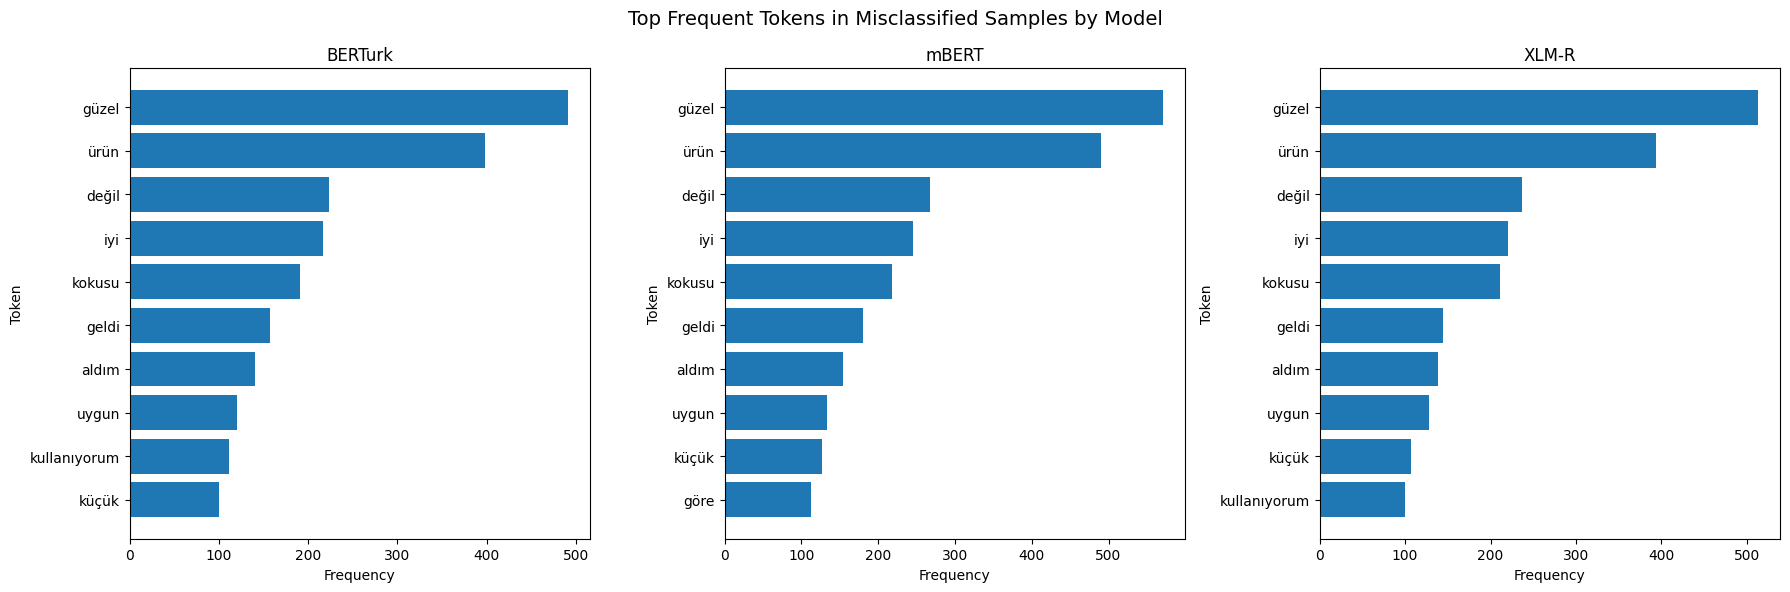

Kaydedildi: /content/gdrive/MyDrive/model_outputs_backup_20260421_200327/token_visualizations/top_wrong_tokens_barplots.png


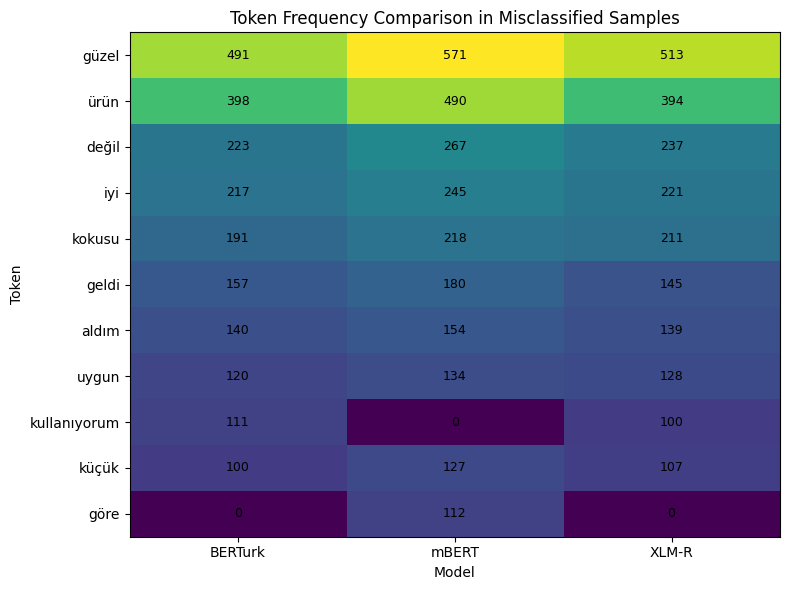

Kaydedildi: /content/gdrive/MyDrive/model_outputs_backup_20260421_200327/token_visualizations/top_wrong_tokens_heatmap.png
Kaydedildi: /content/gdrive/MyDrive/model_outputs_backup_20260421_200327/token_visualizations/top_wrong_tokens_pivot.csv

BİTTİ.


In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1) DOSYA YOLU
# ============================================================

DRIVE_ROOT = "/content/gdrive/MyDrive/model_outputs_backup_20260421_200327"
INPUT_FILE = os.path.join(DRIVE_ROOT, "error_analysis_outputs", "top_tokens_wrong_predictions.csv")
OUTPUT_DIR = os.path.join(DRIVE_ROOT, "token_visualizations")
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Input file:", INPUT_FILE)
print("Exists?", os.path.exists(INPUT_FILE))

df = pd.read_csv(INPUT_FILE)
print(df.head())

# ============================================================
# 2) HER MODEL İÇİN AYRI BAR CHART
# ============================================================

models = ["BERTurk", "mBERT", "XLM-R"]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, model in zip(axes, models):
    sub = df[df["Model"] == model].copy().head(10)
    sub = sub.sort_values("Count", ascending=True)

    ax.barh(sub["Token"], sub["Count"])
    ax.set_title(model)
    ax.set_xlabel("Frequency")
    ax.set_ylabel("Token")

plt.suptitle("Top Frequent Tokens in Misclassified Samples by Model", fontsize=14)
plt.tight_layout()

barplot_path = os.path.join(OUTPUT_DIR, "top_wrong_tokens_barplots.png")
plt.savefig(barplot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Kaydedildi:", barplot_path)

# ============================================================
# 3) HEATMAP BENZERİ GÖRSEL
# ortak tokenlar üzerinden model karşılaştırması
# ============================================================

# Her modelin top 10 tokenını al
top_df = df.groupby("Model").head(10).copy()

# Tüm tokenların birleşimi
tokens = list(dict.fromkeys(top_df["Token"].tolist()))

# Pivot table
pivot = top_df.pivot_table(
    index="Token",
    columns="Model",
    values="Count",
    aggfunc="sum",
    fill_value=0
)

# Token sırasını korumak için
pivot = pivot.reindex(tokens)

# Sütun sırasını sabitle
for m in models:
    if m not in pivot.columns:
        pivot[m] = 0
pivot = pivot[models]

plt.figure(figsize=(8, max(6, len(pivot) * 0.45)))
plt.imshow(pivot.values, aspect="auto")

plt.xticks(range(len(pivot.columns)), pivot.columns)
plt.yticks(range(len(pivot.index)), pivot.index)

# Hücre içi değerleri yaz
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        plt.text(j, i, int(pivot.iloc[i, j]), ha="center", va="center", fontsize=9)

plt.title("Token Frequency Comparison in Misclassified Samples")
plt.xlabel("Model")
plt.ylabel("Token")
plt.tight_layout()

heatmap_path = os.path.join(OUTPUT_DIR, "top_wrong_tokens_heatmap.png")
plt.savefig(heatmap_path, dpi=300, bbox_inches="tight")
plt.show()

print("Kaydedildi:", heatmap_path)

# ============================================================
# 4) İSTERSEN TABLOYU DA KAYDET
# ============================================================

pivot_reset = pivot.reset_index()
pivot_csv_path = os.path.join(OUTPUT_DIR, "top_wrong_tokens_pivot.csv")
pivot_reset.to_csv(pivot_csv_path, index=False, encoding="utf-8-sig")

print("Kaydedildi:", pivot_csv_path)
print("\nBİTTİ.")

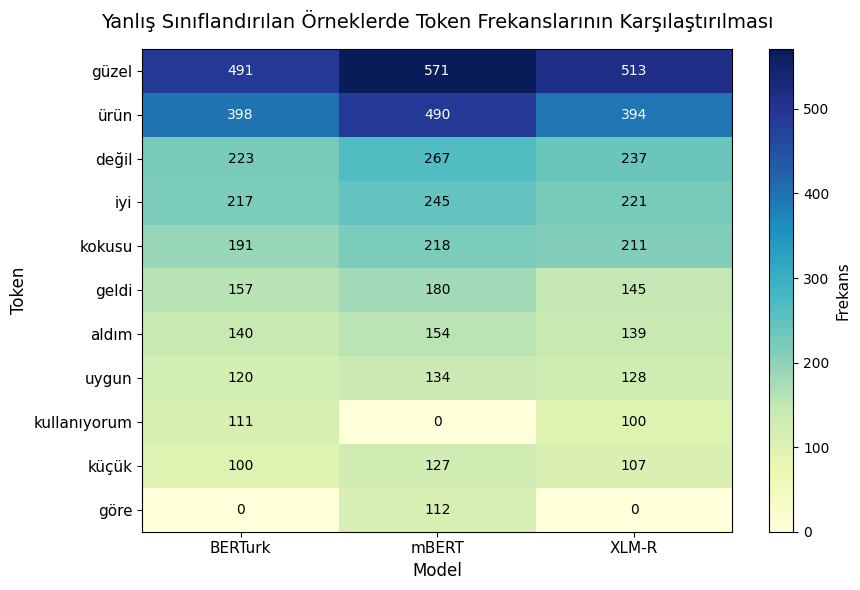

Kaydedildi: /content/gdrive/MyDrive/model_outputs_backup_20260421_200327/token_visualizations/top_wrong_tokens_heatmap_tr.png


In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# DOSYA YOLU
# ============================================================

DRIVE_ROOT = "/content/gdrive/MyDrive/model_outputs_backup_20260421_200327"
INPUT_FILE = os.path.join(DRIVE_ROOT, "error_analysis_outputs", "top_tokens_wrong_predictions.csv")
OUTPUT_DIR = os.path.join(DRIVE_ROOT, "token_visualizations")
os.makedirs(OUTPUT_DIR, exist_ok=True)

df = pd.read_csv(INPUT_FILE)

# ============================================================
# TOP 10 TOKENLARDAN PIVOT TABLO
# ============================================================

models = ["BERTurk", "mBERT", "XLM-R"]

top_df = df.groupby("Model").head(10).copy()

tokens = list(dict.fromkeys(top_df["Token"].tolist()))

pivot = top_df.pivot_table(
    index="Token",
    columns="Model",
    values="Count",
    aggfunc="sum",
    fill_value=0
)

pivot = pivot.reindex(tokens)

for m in models:
    if m not in pivot.columns:
        pivot[m] = 0

pivot = pivot[models]

# ============================================================
# HEATMAP
# ============================================================

fig, ax = plt.subplots(figsize=(9, max(6, len(pivot) * 0.5)))

im = ax.imshow(pivot.values, aspect="auto", cmap="YlGnBu")

ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, fontsize=11)

ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index, fontsize=11)

ax.set_title("Yanlış Sınıflandırılan Örneklerde Token Frekanslarının Karşılaştırılması", fontsize=14, pad=15)
ax.set_xlabel("Model", fontsize=12)
ax.set_ylabel("Token", fontsize=12)

# Colorbar
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Frekans", fontsize=11)

# Hücre içi sayı renklerini kontrasta göre ayarla
threshold = pivot.values.max() / 2.0

for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        value = int(pivot.iloc[i, j])
        text_color = "white" if value > threshold else "black"
        ax.text(j, i, value, ha="center", va="center", color=text_color, fontsize=10)

plt.tight_layout()

heatmap_path = os.path.join(OUTPUT_DIR, "top_wrong_tokens_heatmap_tr.png")
plt.savefig(heatmap_path, dpi=300, bbox_inches="tight")
plt.show()

print("Kaydedildi:", heatmap_path)

combined_path: /content/drive_new/MyDrive/model_outputs_backup_20260421_200327/combined_clean_sentiment.csv
train_path   : /content/drive_new/MyDrive/model_outputs_backup_20260421_200327/sentiment_train_clean.csv
val_path     : /content/drive_new/MyDrive/model_outputs_backup_20260421_200327/sentiment_val_clean.csv
test_path    : /content/drive_new/MyDrive/model_outputs_backup_20260421_200327/sentiment_test_clean.csv

=== Genel Sınıf Dağılımı ===
     Sınıf   Sayı
0  Negatif  22843
1     Nötr  22747
2  Pozitif  22349


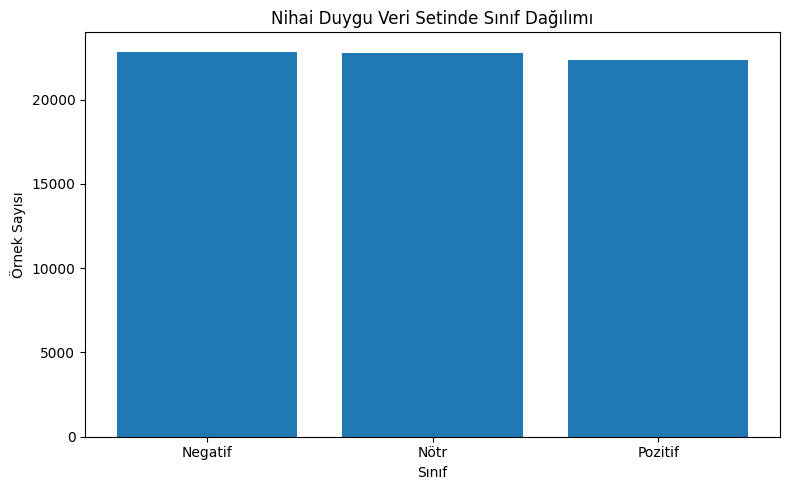


=== Kaynak Dağılımı ===
   Kaynak   Sayı
0    trsa  59999
1  golden   7940


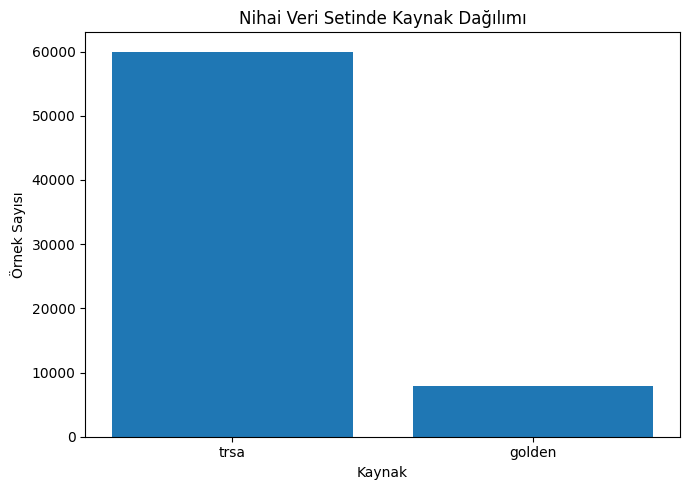

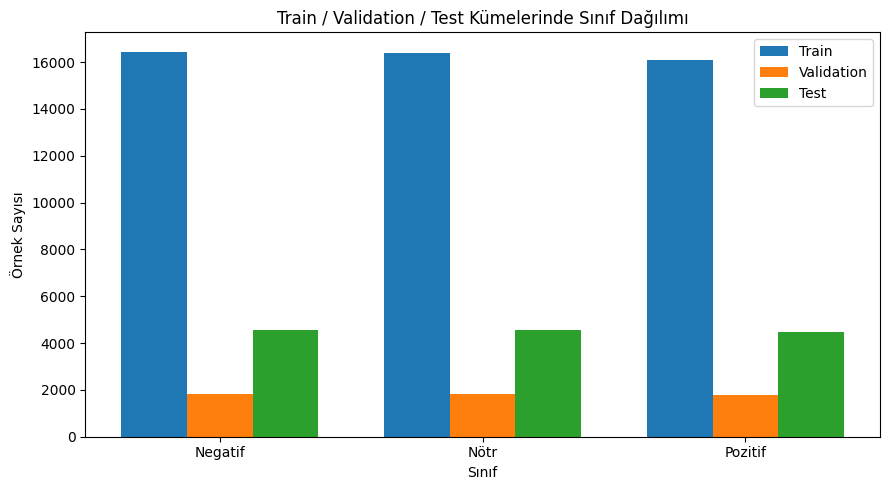


Kaydedildi: /content/drive_new/MyDrive/model_outputs_backup_20260421_200327/dataset_visualizations
Oluşan dosyalar:
- genel_sinif_dagilimi.csv
- genel_sinif_dagilimi.png
- kaynak_dagilimi.csv
- kaynak_dagilimi.png
- split_sinif_dagilimi.csv
- split_sinif_dagilimi.png
- veri_dagilimi_tablolari.xlsx


In [ ]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1) DOSYA BULUCU
# ============================================================

SEARCH_ROOT = "/content/drive_new/MyDrive"

def find_first_file(filename):
    matches = glob.glob(os.path.join(SEARCH_ROOT, "**", filename), recursive=True)
    return matches[0] if matches else None

combined_path = find_first_file("combined_clean_sentiment.csv")
train_path = find_first_file("sentiment_train_clean.csv")
val_path = find_first_file("sentiment_val_clean.csv")
test_path = find_first_file("sentiment_test_clean.csv")

print("combined_path:", combined_path)
print("train_path   :", train_path)
print("val_path     :", val_path)
print("test_path    :", test_path)

if combined_path is None:
    raise FileNotFoundError("combined_clean_sentiment.csv bulunamadı.")

OUTPUT_DIR = os.path.join(os.path.dirname(combined_path), "dataset_visualizations")
os.makedirs(OUTPUT_DIR, exist_ok=True)

label_map = {
    0: "Negatif",
    1: "Nötr",
    2: "Pozitif"
}

# ============================================================
# 2) COMBINED DATASET
# ============================================================

df_combined = pd.read_csv(combined_path)
df_combined["label"] = df_combined["label"].astype(int)
df_combined["label_name"] = df_combined["label"].map(label_map)

combined_counts = (
    df_combined["label_name"]
    .value_counts()
    .reindex(["Negatif", "Nötr", "Pozitif"])
    .fillna(0)
    .astype(int)
    .reset_index()
)
combined_counts.columns = ["Sınıf", "Sayı"]

print("\n=== Genel Sınıf Dağılımı ===")
print(combined_counts)

combined_counts.to_csv(
    os.path.join(OUTPUT_DIR, "genel_sinif_dagilimi.csv"),
    index=False,
    encoding="utf-8-sig"
)

plt.figure(figsize=(8, 5))
plt.bar(combined_counts["Sınıf"], combined_counts["Sayı"])
plt.xlabel("Sınıf")
plt.ylabel("Örnek Sayısı")
plt.title("Nihai Duygu Veri Setinde Sınıf Dağılımı")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "genel_sinif_dagilimi.png"), dpi=300, bbox_inches="tight")
plt.show()

# ============================================================
# 3) KAYNAK DAĞILIMI
# ============================================================

if "source" in df_combined.columns:
    source_counts = (
        df_combined["source"]
        .value_counts()
        .reset_index()
    )
    source_counts.columns = ["Kaynak", "Sayı"]

    print("\n=== Kaynak Dağılımı ===")
    print(source_counts)

    source_counts.to_csv(
        os.path.join(OUTPUT_DIR, "kaynak_dagilimi.csv"),
        index=False,
        encoding="utf-8-sig"
    )

    plt.figure(figsize=(7, 5))
    plt.bar(source_counts["Kaynak"], source_counts["Sayı"])
    plt.xlabel("Kaynak")
    plt.ylabel("Örnek Sayısı")
    plt.title("Nihai Veri Setinde Kaynak Dağılımı")
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "kaynak_dagilimi.png"), dpi=300, bbox_inches="tight")
    plt.show()

# ============================================================
# 4) TRAIN / VAL / TEST VARSA SPLIT GRAFİĞİ
# ============================================================

if all([train_path, val_path, test_path]):
    df_train = pd.read_csv(train_path)
    df_val = pd.read_csv(val_path)
    df_test = pd.read_csv(test_path)

    for df in [df_train, df_val, df_test]:
        df["label"] = df["label"].astype(int)
        df["label_name"] = df["label"].map(label_map)

    def get_split_counts(df, split_name):
        counts = (
            df["label_name"]
            .value_counts()
            .reindex(["Negatif", "Nötr", "Pozitif"])
            .fillna(0)
            .astype(int)
            .reset_index()
        )
        counts.columns = ["Sınıf", "Sayı"]
        counts["Bölüm"] = split_name
        return counts

    split_counts = pd.concat([
        get_split_counts(df_train, "Train"),
        get_split_counts(df_val, "Validation"),
        get_split_counts(df_test, "Test")
    ], ignore_index=True)

    split_counts.to_csv(
        os.path.join(OUTPUT_DIR, "split_sinif_dagilimi.csv"),
        index=False,
        encoding="utf-8-sig"
    )

    pivot = split_counts.pivot(index="Sınıf", columns="Bölüm", values="Sayı").reindex(
        ["Negatif", "Nötr", "Pozitif"]
    )[["Train", "Validation", "Test"]]

    x = np.arange(len(pivot.index))
    width = 0.25

    plt.figure(figsize=(9, 5))
    for i, split in enumerate(["Train", "Validation", "Test"]):
        plt.bar(x + i * width, pivot[split].values, width=width, label=split)

    plt.xticks(x + width, pivot.index)
    plt.xlabel("Sınıf")
    plt.ylabel("Örnek Sayısı")
    plt.title("Train / Validation / Test Kümelerinde Sınıf Dağılımı")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "split_sinif_dagilimi.png"), dpi=300, bbox_inches="tight")
    plt.show()

else:
    print("\n[Bilgi] sentiment_train/val/test_clean dosyaları bulunamadı. Split grafiği atlandı.")

# ============================================================
# 5) EXCEL
# ============================================================

excel_path = os.path.join(OUTPUT_DIR, "veri_dagilimi_tablolari.xlsx")
with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
    combined_counts.to_excel(writer, sheet_name="genel_sinif_dagilimi", index=False)
    if "source" in df_combined.columns:
        source_counts.to_excel(writer, sheet_name="kaynak_dagilimi", index=False)

print("\nKaydedildi:", OUTPUT_DIR)
print("Oluşan dosyalar:")
for f in sorted(os.listdir(OUTPUT_DIR)):
    print("-", f)

Bulunan dosya: /content/drive_new/MyDrive/model_outputs_backup_20260421_200327/combined_clean_sentiment.csv


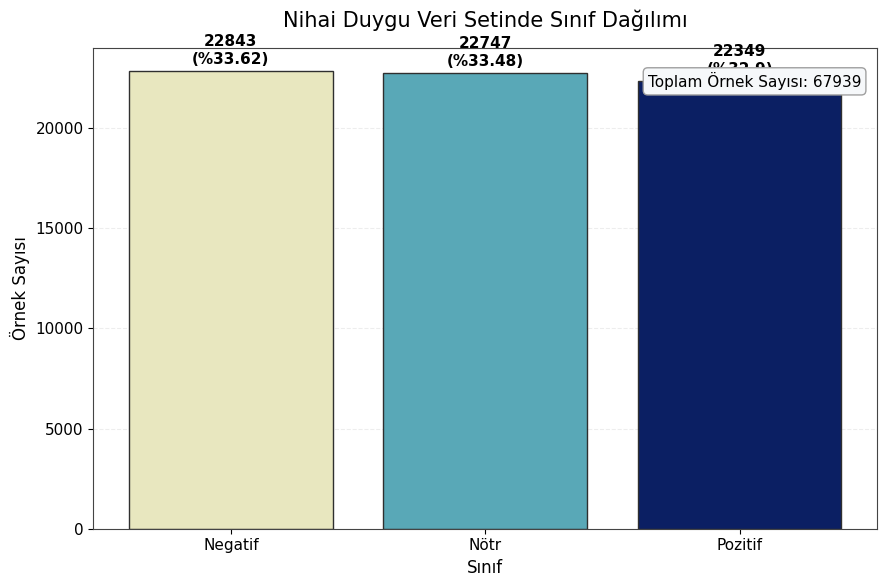

Kaydedildi: /content/drive_new/MyDrive/model_outputs_backup_20260421_200327/dataset_visualizations_same_palette/genel_sinif_dagilimi_detayli.png


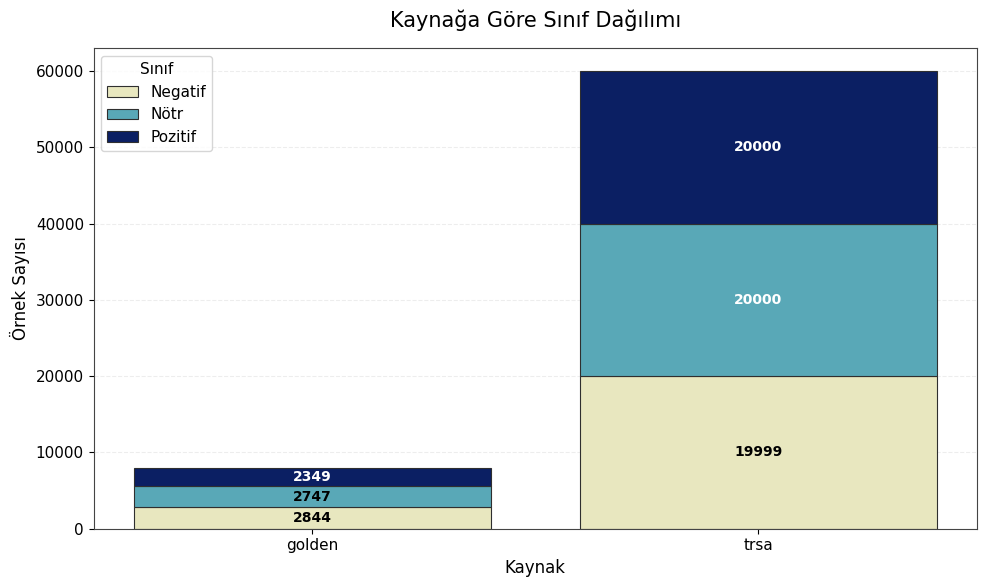

Kaydedildi: /content/drive_new/MyDrive/model_outputs_backup_20260421_200327/dataset_visualizations_same_palette/kaynaga_gore_sinif_dagilimi_yiginli.png


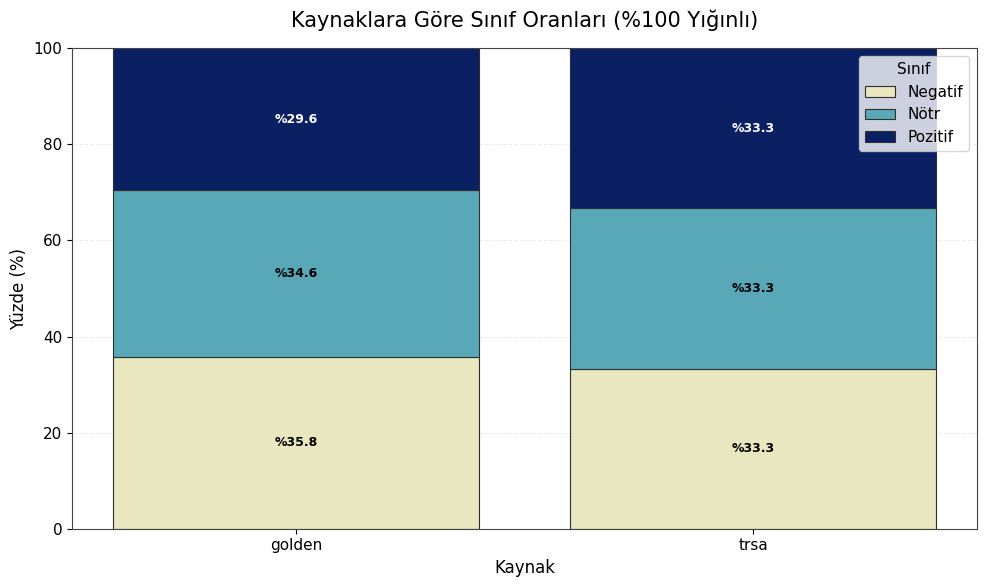

Kaydedildi: /content/drive_new/MyDrive/model_outputs_backup_20260421_200327/dataset_visualizations_same_palette/kaynaga_gore_sinif_oranlari_yuzde.png


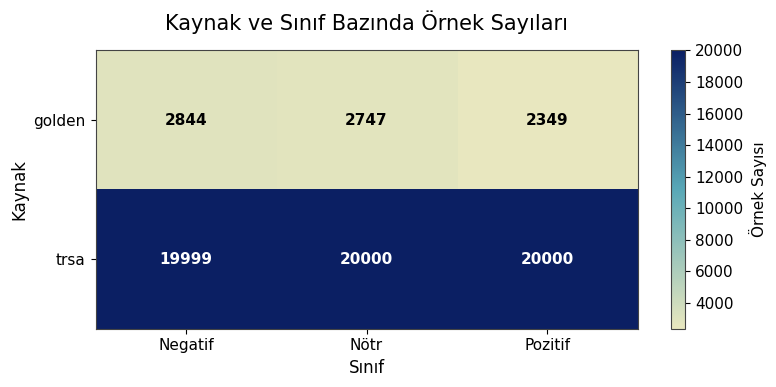

Kaydedildi: /content/drive_new/MyDrive/model_outputs_backup_20260421_200327/dataset_visualizations_same_palette/kaynak_sinif_heatmap.png

Kaydedildi: /content/drive_new/MyDrive/model_outputs_backup_20260421_200327/dataset_visualizations_same_palette/veri_dagilimi_detayli_tablolar.xlsx

Oluşan dosyalar:
- genel_sinif_dagilimi_detayli.csv
- genel_sinif_dagilimi_detayli.png
- kaynaga_gore_sinif_dagilimi.csv
- kaynaga_gore_sinif_dagilimi_yiginli.png
- kaynaga_gore_sinif_oranlari.csv
- kaynaga_gore_sinif_oranlari_yuzde.png
- kaynak_sinif_heatmap.png
- veri_dagilimi_detayli_tablolar.xlsx

BİTTİ.


In [ ]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# ============================================================
# 1) DOSYAYI OTOMATİK BUL
# ============================================================

SEARCH_ROOTS = [
    "/content/drive_new/MyDrive",
    "/content/gdrive/MyDrive",
    "/content/drive/MyDrive",
    "/content"
]

def find_first_file(filename):
    for root in SEARCH_ROOTS:
        if os.path.exists(root):
            matches = glob.glob(os.path.join(root, "**", filename), recursive=True)
            if matches:
                return matches[0]
    return None

combined_path = find_first_file("combined_clean_sentiment.csv")
print("Bulunan dosya:", combined_path)

if combined_path is None:
    raise FileNotFoundError("combined_clean_sentiment.csv bulunamadı.")

OUTPUT_DIR = os.path.join(os.path.dirname(combined_path), "dataset_visualizations_same_palette")
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ============================================================
# 2) VERİYİ OKU
# ============================================================

df = pd.read_csv(combined_path)

label_map = {
    0: "Negatif",
    1: "Nötr",
    2: "Pozitif"
}

df["label"] = df["label"].astype(int)
df["Sınıf"] = df["label"].map(label_map)

class_order = ["Negatif", "Nötr", "Pozitif"]
total_n = len(df)

# ============================================================
# 3) TEK RENK PALETİ
# Aynı heatmap hissi: bej -> ara ton -> lacivert
# ============================================================

LIGHT_BEIGE = "#e8e7bf"
MID_BLUEGREEN = "#59a8b7"
DARK_NAVY = "#0b1f63"

class_colors = {
    "Negatif": LIGHT_BEIGE,
    "Nötr": MID_BLUEGREEN,
    "Pozitif": DARK_NAVY
}

custom_cmap = LinearSegmentedColormap.from_list(
    "custom_beige_teal_navy",
    [LIGHT_BEIGE, MID_BLUEGREEN, DARK_NAVY]
)

plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["axes.edgecolor"] = "#444444"
plt.rcParams["axes.linewidth"] = 0.8
plt.rcParams["grid.color"] = "#D9D9D9"
plt.rcParams["grid.linestyle"] = "--"
plt.rcParams["grid.alpha"] = 0.45
plt.rcParams["font.size"] = 11

# ============================================================
# 4) GENEL SINIF DAĞILIMI
# ============================================================

class_counts = (
    df["Sınıf"]
    .value_counts()
    .reindex(class_order)
    .fillna(0)
    .astype(int)
)

class_percent = (class_counts / class_counts.sum() * 100).round(2)

fig, ax = plt.subplots(figsize=(9, 6))

bars = ax.bar(
    class_counts.index,
    class_counts.values,
    color=[class_colors[c] for c in class_counts.index],
    edgecolor="#2F2F2F",
    linewidth=1.0
)

ax.set_title("Nihai Duygu Veri Setinde Sınıf Dağılımı", fontsize=15, pad=15)
ax.set_xlabel("Sınıf", fontsize=12)
ax.set_ylabel("Örnek Sayısı", fontsize=12)
ax.grid(axis="y")
ax.set_axisbelow(True)

max_val = max(class_counts.values)

for bar, cls in zip(bars, class_counts.index):
    value = class_counts[cls]
    pct = class_percent[cls]
    txt_color = "white" if cls == "Pozitif" else "black"
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max_val * 0.01,
        f"{value}\n(%{pct})",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
        color="black"
    )

ax.text(
    0.98, 0.95,
    f"Toplam Örnek Sayısı: {total_n}",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=11,
    bbox=dict(boxstyle="round,pad=0.3", facecolor="#F6F8FA", edgecolor="#A0A0A0")
)

plt.tight_layout()
save_path = os.path.join(OUTPUT_DIR, "genel_sinif_dagilimi_detayli.png")
plt.savefig(save_path, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
print("Kaydedildi:", save_path)

# ============================================================
# 5) KAYNAK VARSA: KAYNAĞA GÖRE SINIF DAĞILIMI
# ============================================================

if "source" in df.columns:
    ctab = pd.crosstab(df["source"], df["Sınıf"]).reindex(columns=class_order, fill_value=0)

    # --------------------------------------------------------
    # 5A) YIĞINLI BAR
    # --------------------------------------------------------
    fig, ax = plt.subplots(figsize=(10, 6))

    bottom = np.zeros(len(ctab))
    x = np.arange(len(ctab.index))

    for cls in class_order:
        vals = ctab[cls].values
        ax.bar(
            x,
            vals,
            bottom=bottom,
            label=cls,
            color=class_colors[cls],
            edgecolor="#2F2F2F",
            linewidth=0.8
        )

        for i, (b, v) in enumerate(zip(bottom, vals)):
            if v > 0:
                if cls == "Pozitif" or (cls == "Nötr" and v > ctab.values.max() * 0.35):
                    txt_color = "white"
                else:
                    txt_color = "black"

                ax.text(
                    i,
                    b + v / 2,
                    str(v),
                    ha="center",
                    va="center",
                    fontsize=10,
                    color=txt_color,
                    fontweight="bold"
                )
        bottom += vals

    ax.set_title("Kaynağa Göre Sınıf Dağılımı", fontsize=15, pad=15)
    ax.set_xlabel("Kaynak", fontsize=12)
    ax.set_ylabel("Örnek Sayısı", fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels(ctab.index)
    ax.legend(title="Sınıf")
    ax.grid(axis="y")
    ax.set_axisbelow(True)

    plt.tight_layout()
    save_path = os.path.join(OUTPUT_DIR, "kaynaga_gore_sinif_dagilimi_yiginli.png")
    plt.savefig(save_path, dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()
    print("Kaydedildi:", save_path)

    # --------------------------------------------------------
    # 5B) %100 YIĞINLI BAR
    # --------------------------------------------------------
    ctab_pct = ctab.div(ctab.sum(axis=1), axis=0) * 100

    fig, ax = plt.subplots(figsize=(10, 6))

    bottom = np.zeros(len(ctab_pct))
    x = np.arange(len(ctab_pct.index))

    for cls in class_order:
        vals = ctab_pct[cls].values
        ax.bar(
            x,
            vals,
            bottom=bottom,
            label=cls,
            color=class_colors[cls],
            edgecolor="#2F2F2F",
            linewidth=0.8
        )

        for i, (b, v) in enumerate(zip(bottom, vals)):
            if v > 4:
                txt_color = "white" if cls == "Pozitif" else "black"
                ax.text(
                    i,
                    b + v / 2,
                    f"%{v:.1f}",
                    ha="center",
                    va="center",
                    fontsize=9,
                    color=txt_color,
                    fontweight="bold"
                )
        bottom += vals

    ax.set_title("Kaynaklara Göre Sınıf Oranları (%100 Yığınlı)", fontsize=15, pad=15)
    ax.set_xlabel("Kaynak", fontsize=12)
    ax.set_ylabel("Yüzde (%)", fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels(ctab_pct.index)
    ax.set_ylim(0, 100)
    ax.legend(title="Sınıf")
    ax.grid(axis="y")
    ax.set_axisbelow(True)

    plt.tight_layout()
    save_path = os.path.join(OUTPUT_DIR, "kaynaga_gore_sinif_oranlari_yuzde.png")
    plt.savefig(save_path, dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()
    print("Kaydedildi:", save_path)

    # --------------------------------------------------------
    # 5C) HEATMAP
    # --------------------------------------------------------
    fig, ax = plt.subplots(figsize=(8, max(4, len(ctab.index) * 0.8)))

    im = ax.imshow(ctab.values, aspect="auto", cmap=custom_cmap)

    ax.set_xticks(np.arange(len(ctab.columns)))
    ax.set_xticklabels(ctab.columns, fontsize=11)

    ax.set_yticks(np.arange(len(ctab.index)))
    ax.set_yticklabels(ctab.index, fontsize=11)

    ax.set_title("Kaynak ve Sınıf Bazında Örnek Sayıları", fontsize=15, pad=15)
    ax.set_xlabel("Sınıf", fontsize=12)
    ax.set_ylabel("Kaynak", fontsize=12)

    threshold = ctab.values.max() / 2 if ctab.values.max() > 0 else 0

    for i in range(ctab.shape[0]):
        for j in range(ctab.shape[1]):
            val = int(ctab.iloc[i, j])
            txt_color = "white" if val > threshold else "black"
            ax.text(
                j, i, str(val),
                ha="center", va="center",
                color=txt_color,
                fontsize=11, fontweight="bold"
            )

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("Örnek Sayısı", fontsize=11)

    plt.tight_layout()
    save_path = os.path.join(OUTPUT_DIR, "kaynak_sinif_heatmap.png")
    plt.savefig(save_path, dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()
    print("Kaydedildi:", save_path)

else:
    print("[Bilgi] 'source' kolonu bulunamadı. Kaynak bazlı grafikler atlandı.")

# ============================================================
# 6) TABLOLARI KAYDET
# ============================================================

class_dist_df = pd.DataFrame({
    "Sınıf": class_counts.index,
    "Sayı": class_counts.values,
    "Yüzde": class_percent.values
})
class_dist_df.to_csv(
    os.path.join(OUTPUT_DIR, "genel_sinif_dagilimi_detayli.csv"),
    index=False,
    encoding="utf-8-sig"
)

if "source" in df.columns:
    ctab.to_csv(
        os.path.join(OUTPUT_DIR, "kaynaga_gore_sinif_dagilimi.csv"),
        encoding="utf-8-sig"
    )
    ctab_pct.round(2).to_csv(
        os.path.join(OUTPUT_DIR, "kaynaga_gore_sinif_oranlari.csv"),
        encoding="utf-8-sig"
    )

excel_path = os.path.join(OUTPUT_DIR, "veri_dagilimi_detayli_tablolar.xlsx")
with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
    class_dist_df.to_excel(writer, sheet_name="genel_sinif_dagilimi", index=False)
    if "source" in df.columns:
        ctab.reset_index().to_excel(writer, sheet_name="kaynak_sinif_sayilari", index=False)
        ctab_pct.reset_index().to_excel(writer, sheet_name="kaynak_sinif_oranlari", index=False)

print("\nKaydedildi:", excel_path)

print("\nOluşan dosyalar:")
for f in sorted(os.listdir(OUTPUT_DIR)):
    print("-", f)

print("\nBİTTİ.")

In [ ]:
import pandas as pd

bert = pd.read_csv("/content/berturk_test_predictions.csv")
mbert = pd.read_csv("/content/mbert_test_predictions.csv")
xlmr = pd.read_csv("/content/xlmr_test_predictions.csv")

bert = bert[["text", "label_name", "pred_name", "correct"]].rename(columns={
    "pred_name": "BERTurk_pred",
    "correct": "BERTurk_correct"
})

mbert = mbert[["text", "pred_name", "correct"]].rename(columns={
    "pred_name": "mBERT_pred",
    "correct": "mBERT_correct"
})

xlmr = xlmr[["text", "pred_name", "correct"]].rename(columns={
    "pred_name": "XLM-R_pred",
    "correct": "XLM-R_correct"
})

merged = bert.merge(mbert, on="text").merge(xlmr, on="text")

print("ÜÇ MODELİN AYNI TEST CÜMLELERİNDEKİ DURUMU")
display(merged.head(10))

ÜÇ MODELİN AYNI TEST CÜMLELERİNDEKİ DURUMU


,text,label_name,BERTurk_pred,BERTurk_correct,mBERT_pred,mBERT_correct,XLM-R_pred,XLM-R_correct
0,Kaç yıldır eyeliner kullanıyorum fakat bu asla...,Nötr,Nötr,1,Nötr,1,Nötr,1
1,"Bu ikinci alışım, ilki çok güzel bir taştı.Ona...",Nötr,Nötr,1,Nötr,1,Nötr,1
2,2 tane aldım 1nin dikişleri açık geldi kumaşı ...,Negatif,Negatif,1,Negatif,1,Negatif,1
3,Sabah aksam severek kullanıyorum performansını...,Pozitif,Pozitif,1,Pozitif,1,Pozitif,1
4,böyle bir krem olamaz saçlarınıza vazelin sürü...,Negatif,Negatif,1,Nötr,0,Negatif,1
5,cildime yaramadı,Nötr,Nötr,1,Negatif,0,Negatif,0
6,çok güzel saçın yağlı görünümünü engelliyor,Nötr,Pozitif,0,Pozitif,0,Pozitif,0
7,Ürün gerçekten bayağı küçük geldi gözüme ama e...,Pozitif,Nötr,0,Pozitif,1,Nötr,0
8,Kokusu biraz agir..ama kullanilabilir..,Nötr,Nötr,1,Nötr,1,Nötr,1
9,kumaşı güzel beğendim. ama aldigim anda ip kıs...,Negatif,Negatif,1,Negatif,1,Negatif,1


In [ ]:
# =====================================================
# RANDOM EXAMPLES EVERY RUN
# =====================================================

print("MODELS GAVE DIFFERENT PREDICTIONS:")
display(different_preds.sample(10))

# =====================================================
# ONLY XLM-R CORRECT
# =====================================================
print("ONLY XLM-R CORRECT:")
display(only_xlmr.sample(min(20, len(only_xlmr))))

# =====================================================
# ONLY BERTurk CORRECT
# =====================================================
print("ONLY BERTurk CORRECT:")
display(only_bert.sample(min(20, len(only_bert))))

# =====================================================
# ALL THREE WRONG
# =====================================================
print("ALL THREE WRONG:")
display(all_wrong.sample(min(20, len(all_wrong))))

MODELS GAVE DIFFERENT PREDICTIONS:


,text,label_name,BERTurk_pred,BERTurk_correct,mBERT_pred,mBERT_correct,XLM-R_pred,XLM-R_correct
12981,hediyeniz için teşekkür ediyorum.kullanmak için sabirsizlaniyorum,Nötr,Nötr,1,Nötr,1,Pozitif,0
9663,Çok beğendiğimi söyleyemem özellikle külotunu çok kalitesiz buldum,Negatif,Negatif,1,Nötr,0,Negatif,1
8857,Göründüğü kadar güzel değil. Çok memnun kalmadım.,Negatif,Nötr,0,Negatif,1,Nötr,0
190,Pek etksini göremedim,Nötr,Nötr,1,Negatif,0,Nötr,1
3280,hrika bir ürün tavsiye ederm,Pozitif,Negatif,0,Nötr,0,Nötr,0
12782,"Kapağı paramparça oldu ama beati severim, indirimde kaçırmayın",Nötr,Pozitif,0,Nötr,1,Pozitif,0
11248,Bisküvi gibi kokuyo ... Cildi çok güzel yumuşatıyor ve iki günde lekelerim açıldı sanki,Pozitif,Nötr,0,Pozitif,1,Pozitif,1
8812,Tek bir renk geliyor ve fiyatı çok pahalı. Böyle bir süreçte bu kadar pahalıya satmak biraz hoş değil. İhtiyaç halinde ürün fiyatını artırmak ...,Negatif,Nötr,0,Nötr,0,Negatif,1
3678,ben pek bir fark göremedim zaten yaydığı titreşimler de başımı ağrıttı,Negatif,Negatif,1,Nötr,0,Negatif,1
4683,Daha önce de kullanıyordum. Kullandığım beyaz gibiydi burdan sipariş verdiğim şeffaf. Sanırım önceki daha güzeldi.,Negatif,Nötr,0,Pozitif,0,Nötr,0


ONLY XLM-R CORRECT:


,text,label_name,BERTurk_pred,BERTurk_correct,mBERT_pred,mBERT_correct,XLM-R_pred,XLM-R_correct
3013,ekonomik güzel bence,Nötr,Pozitif,0,Pozitif,0,Nötr,1
5552,Ürün yakıyor,Nötr,Negatif,0,Negatif,0,Nötr,1
3750,"Çok bir işe yaradığını düşünmüyorum, elimle yıkamaktan bir farkı yok.",Nötr,Negatif,0,Negatif,0,Nötr,1
6897,kargolama iyiydi.elime bir sorun yaşamadan ulaştı.daha kullanmaya yeni başladım.ürün için yorum şuan yapamıyorum.kokusu filan çok güzel uzun süre kullandıktan sonra yorumumu güncellicem.,Pozitif,Nötr,0,Nötr,0,Pozitif,1
239,koyu lekelerim için almştım ama bir faydasını görmedim malesef,Nötr,Negatif,0,Negatif,0,Nötr,1
963,Kokusunu daha yoğun bekliyordum nerdeyse hiç kokmuyor gibi,Nötr,Negatif,0,Negatif,0,Nötr,1
6522,Kokusu çok agır.,Negatif,Nötr,0,Nötr,0,Negatif,1
7626,Mükemmel bir kokusu var. Saça canlı bir parlaklık kazandırıyor ama onarma gibi bir durumunu göremedim. Kokusu için kullanılır.,Pozitif,Nötr,0,Nötr,0,Pozitif,1
5490,Çantada taşımak için pratik bir ürün.Yalnızca yüzümde kullanıyorum.Yağlı bir cilde sahip olmama rağmen parlama vs yaptırmadı.,Pozitif,Nötr,0,Nötr,0,Pozitif,1
6786,kokusu kötü saç yağlı duruyor çıkarması zor,Nötr,Negatif,0,Negatif,0,Nötr,1


ONLY BERTurk CORRECT:


,text,label_name,BERTurk_pred,BERTurk_correct,mBERT_pred,mBERT_correct,XLM-R_pred,XLM-R_correct
9125,çok kalıcı bir boya,Nötr,Nötr,1,Pozitif,0,Negatif,0
12384,hayir heykellerin yıkıldı hiç 3tkisi yok 3 kere denedim saçım kahve rengi,Negatif,Negatif,1,Pozitif,0,Pozitif,0
1390,rengi burda gözüktüğü gibi değil çok pembe bir nude,Nötr,Nötr,1,Negatif,0,Negatif,0
10060,İçeriği değişmiş dikkat edin,Negatif,Negatif,1,Nötr,0,Nötr,0
7275,bir kez kullandim yuzume cildime surdugumde çok hafif bir yanma tarzi bisey oldu katlisiz oldugunu dusunuyorum cunki parfumlu değilkokusu kullandikca gorcez kargolama çok güzel sarilip paketlenmis saticiya teşekkürler,Nötr,Nötr,1,Pozitif,0,Pozitif,0
1148,"Boyutu küçük, ben fark göremedim ve tırnaklarımı boyadı",Negatif,Negatif,1,Nötr,0,Nötr,0
7013,"birkaç kez kullandım, umarım iyi sonuç alirim",Nötr,Nötr,1,Pozitif,0,Pozitif,0
3124,Gğzellllllll,Nötr,Nötr,1,Negatif,0,Pozitif,0
11419,ter kokusunu önlüyor ama doğal olup olmadığını biraz daha kullanınca göreceğiz,Pozitif,Pozitif,1,Nötr,0,Nötr,0
2251,ilk başta beklentim düşüktü ama üŕün gayet iyi ve ince kullanışĺı,Pozitif,Pozitif,1,Nötr,0,Nötr,0


ALL THREE WRONG:


,text,label_name,BERTurk_pred,BERTurk_correct,mBERT_pred,mBERT_correct,XLM-R_pred,XLM-R_correct
5037,"İndirimden alın çok para vermenize gerek yok ,ml olarak küçük onu da dikkate alarak alın",Nötr,Pozitif,0,Pozitif,0,Pozitif,0
8784,Fiyat uygun. Edp oluşundan kokusu ağır. Ağır koku sevmeyenler almasın boşuna. İlk defa denedim yorumlara bakıp aldım ama sevmedim. Yaz için hiç uygun değil.,Nötr,Negatif,0,Negatif,0,Negatif,0
11039,ürün çok harika,Negatif,Pozitif,0,Pozitif,0,Pozitif,0
9051,çok uygun fiyata aldım. henüz denemedim ama görünüşü kaliteli denediğimde yazacağım,Nötr,Pozitif,0,Pozitif,0,Pozitif,0
11347,Benim gibi gozalti morlugu probleminiz varsa ve acik bugday tenliyseniz teninize uygun olabilir fakat tek basina gozaltina yeterli olmuyor kapatici olarak bu yuzden ben Nude rengini kullanrak ilk notrluyorum sonrasinda bunu aydinlatmak icin kullaniyorum. Nude rengi tenime koyu geldigini dusunddugum icin light rengini aldim kullandikca yorumu gunceleyyebilirim 😇,Pozitif,Nötr,0,Nötr,0,Nötr,0
5795,Arkadaşlar bir etkisi uok killanma yapıyor,Negatif,Nötr,0,Nötr,0,Nötr,0
5598,daha kullanmadık. kullanınca yorum yazacağım,Negatif,Nötr,0,Nötr,0,Nötr,0
2087,Çok etkileyici bir ürün değil,Negatif,Nötr,0,Nötr,0,Nötr,0
3847,Renk beklediğim gibi değildi,Nötr,Negatif,0,Negatif,0,Negatif,0
5412,Spor ve diyet yaptığım halde benimle inatlaşan karın bölgemdeki yağlar için aldım. 3 haftadır kullanıyorum sadece 1 cm inceldi. Kullanmasaydım da o kadar incelirdi zaten. Bu sıcaklarda kendimi daha fazla yaktığımla kaldım.,Negatif,Pozitif,0,Nötr,0,Nötr,0


In [ ]:
import pandas as pd
import re

def ironi_adaylarini_bul(df, metin_sutunu='text', etiket_sutunu='label'):
    """
    Verilen DataFrame içindeki ironi potansiyeli taşıyan metinleri bulur ve puanlar.
    Özellikle tüm modellerin yanıldığı 'all_wrong' DataFrame'inde çok iyi çalışır.
    """
    # Orijinal veriyi bozmamak için kopyasını alıyoruz
    df_irony = df.copy()

    # --- 1. KURAL TABANLI FİLTRELER (HEURISTICS) ---

    # Kural 1: Parantez içi ünlem (!) veya doğrudan "ironi" kelimesi
    df_irony['k_unlem'] = df_irony[metin_sutunu].str.contains(r"\(!\)|ironi", case=False, regex=True, na=False).astype(int)

    # Kural 2: Abartılı pozitif kelimeler (Genelde laf sokarken kullanılır)
    abarti_kelimeler = "maşallah|harika|mükemmel|süper|çok zekice|bravo|alkış|muazzam"
    df_irony['k_abarti'] = df_irony[metin_sutunu].str.contains(abarti_kelimeler, case=False, na=False).astype(int)

    # Kural 3: Şüpheli ve agresif noktalama işaretleri (Üç nokta, !?!?)
    df_irony['k_noktalama'] = df_irony[metin_sutunu].str.contains(r"\.{3,}|\?!\?|!\?!", regex=True, na=False).astype(int)

    # Kural 4: Anlamı tersine çeviren sinsi kelimeler
    df_irony['k_tersine_cevirici'] = df_irony[metin_sutunu].str.contains(r"\bsözde\b|\bgüya\b", case=False, na=False).astype(int)

    # --- 2. DUYGU ZITLIĞI (SENTIMENT MISMATCH) ---
    # Not: Etiketlerin 0=Negatif olduğunu varsayıyoruz.
    # Etiket Negatif olup içinde pozitif kelime geçenleri yakalar.
    pozitif_kelimeler = "iyi|güzel|teşekkür|harika|süper|muazzam"
    if etiket_sutunu in df_irony.columns:
        df_irony['k_duygu_zitligi'] = ((df_irony[etiket_sutunu] == 0) &
                                       (df_irony[metin_sutunu].str.contains(pozitif_kelimeler, case=False, na=False))).astype(int)
    else:
        df_irony['k_duygu_zitligi'] = 0

    # --- 3. İRONİ SKORU HESAPLAMA ---
    # Yakalanan her kuraldan 1 puan gelir. Maksimum skor 5'tir.
    skor_sutunlari = ['k_unlem', 'k_abarti', 'k_noktalama', 'k_tersine_cevirici', 'k_duygu_zitligi']
    df_irony['ironi_skoru'] = df_irony[skor_sutunlari].sum(axis=1)

    # Hiçbir kurala uymayanları (skoru 0 olanları) ele ve büyükten küçüğe sırala
    ironi_adaylari = df_irony[df_irony['ironi_skoru'] > 0].sort_values(by='ironi_skoru', ascending=False)

    return ironi_adaylari

# =====================================================
# 1. AŞAMA: HEURISTIC ARAMA VE SKORLAMA
# =====================================================
print("Tüm modellerin yanıldığı veri setinde ironi aranıyor...")
ironi_adaylari = ironi_adaylarini_bul(all_wrong, metin_sutunu='text', etiket_sutunu='label')

print(f"Toplam {len(ironi_adaylari)} potansiyel ironi bulundu.")
display(ironi_adaylari[['text', 'ironi_skoru']].head(15))


# =====================================================
# 2. AŞAMA (OPSİYONEL): ZERO-SHOT TEYİDİ
# Sadece skoru en yüksek (örneğin skoru >= 2) olanlara
# HuggingFace Zero-Shot uygulayarak kesinleştirme yapabilirsiniz.
# =====================================================
"""
from transformers import pipeline

# Türkçe destekleyen iyi bir model
classifier = pipeline("zero-shot-classification", model="MoritzLaurer/mDeBERTa-v3-base-mnli-xnli")

def check_irony_zeroshot(text):
    sonuc = classifier(text, ["ironi", "ciddi", "şikayet"])
    return sonuc['labels'][0] # En yüksek ihtimalli etiketi döndürür

# Sadece skoru en yüksek olan şüpheli örneklere zero-shot uygula (zaman tasarrufu)
supheliler = ironi_adaylari[ironi_adaylari['ironi_skoru'] >= 2].copy()

if not supheliler.empty:
    print("\nŞüpheliler Zero-Shot modeli ile teyit ediliyor...")
    supheliler['zero_shot_tahmini'] = supheliler['text'].apply(check_irony_zeroshot)

    # Gerçekten "ironi" olarak etiketlenenleri göster
    kesin_ironiler = supheliler[supheliler['zero_shot_tahmini'] == 'ironi']
    display(kesin_ironiler[['text', 'ironi_skoru', 'zero_shot_tahmini']])
"""

Tüm modellerin yanıldığı veri setinde ironi aranıyor...
Toplam 70 potansiyel ironi bulundu.


,text,ironi_skoru
8284,Yağ güzel ama kokusu berbat arkadaşlar harika diyenlere aldandım bildiğiniz bir hacı missi kokusu o kadar ağır ve kötü kii sakın almayın...,2
3920,süper çok kullanışlı ......................,2
12099,ürün bugün elime ulaştı..alıyor almıyor diyemem süper değil şu karantina zamanı idare eder.yay güzel ...metal ( demir )olan kısım paslı ..ilçede olmasaydım iade edecektim bu süreçte merkeze git gel yapamam....,2
630,iyi fiyat ...,1
327,anında beyazlatma etkisi var. nemlendirmiyor.leke giderme özelliği hakkında bir şey diyemiycem kullandıkça görcez. merhaba yine ben bir iki gündür kullanıyorum cildi aydınlık veriyor ve ben aşırı beğendim daha yeni almama rağmen yine sipariş verdim....,1
442,Harika bir ürün kalıcı değil yalnız,1
1289,harika ve kalıcı,1
848,Fiyatına göre başarılı bir ürün kokusu harika,1
844,"Tavsiye üzerine aldım, kullanan arkadaşlarım çok memnun... Kullanım sonrası yine yorum atarım.",1
2091,Bayıldım harika ürün,1


'\nfrom transformers import pipeline\n\n# Türkçe destekleyen iyi bir model\nclassifier = pipeline("zero-shot-classification", model="MoritzLaurer/mDeBERTa-v3-base-mnli-xnli")\n\ndef check_irony_zeroshot(text):\n    sonuc = classifier(text, ["ironi", "ciddi", "şikayet"])\n    return sonuc[\'labels\'][0] # En yüksek ihtimalli etiketi döndürür\n\n# Sadece skoru en yüksek olan şüpheli örneklere zero-shot uygula (zaman tasarrufu)\nsupheliler = ironi_adaylari[ironi_adaylari[\'ironi_skoru\'] >= 2].copy()\n\nif not supheliler.empty:\n    print("\nŞüpheliler Zero-Shot modeli ile teyit ediliyor...")\n    supheliler[\'zero_shot_tahmini\'] = supheliler[\'text\'].apply(check_irony_zeroshot)\n    \n    # Gerçekten "ironi" olarak etiketlenenleri göster\n    kesin_ironiler = supheliler[supheliler[\'zero_shot_tahmini\'] == \'ironi\']\n    display(kesin_ironiler[[\'text\', \'ironi_skoru\', \'zero_shot_tahmini\']])\n'

In [ ]:
import pandas as pd
import re

def ironi_adaylarini_getir(df, metin_sutunu='text', etiket_sutunu='label'):
    # Orijinal veriyi bozmamak için kopyasını alıyoruz
    df_irony = df.copy()

    # --- 1. KURAL TABANLI FİLTRELER ---
    df_irony['k_unlem'] = df_irony[metin_sutunu].str.contains(r"\(!\)|ironi", case=False, regex=True, na=False).astype(int)
    abarti_kelimeler = "maşallah|harika|mükemmel|süper|çok zekice|bravo|alkış|muazzam"
    df_irony['k_abarti'] = df_irony[metin_sutunu].str.contains(abarti_kelimeler, case=False, na=False).astype(int)
    df_irony['k_noktalama'] = df_irony[metin_sutunu].str.contains(r"\.{3,}|\?!\?|!\?!", regex=True, na=False).astype(int)
    df_irony['k_tersine_cevirici'] = df_irony[metin_sutunu].str.contains(r"\bsözde\b|\bgüya\b", case=False, na=False).astype(int)

    # --- 2. DUYGU ZITLIĞI ---
    pozitif_kelimeler = "iyi|güzel|teşekkür|harika|süper|muazzam"
    if etiket_sutunu in df_irony.columns:
        df_irony['k_duygu_zitligi'] = ((df_irony[etiket_sutunu] == 0) &
                                       (df_irony[metin_sutunu].str.contains(pozitif_kelimeler, case=False, na=False))).astype(int)
    else:
        df_irony['k_duygu_zitligi'] = 0

    # --- 3. İRONİ SKORU HESAPLAMA ---
    skor_sutunlari = ['k_unlem', 'k_abarti', 'k_noktalama', 'k_tersine_cevirici', 'k_duygu_zitligi']
    df_irony['ironi_skoru'] = df_irony[skor_sutunlari].sum(axis=1)

    # Hiçbir kurala uymayanları ele ve skora göre sırala
    ironi_adaylari = df_irony[df_irony['ironi_skoru'] > 0].sort_values(by='ironi_skoru', ascending=False)

    return ironi_adaylari

# =====================================================
# UYGULAMA VE GÖSTERİM AŞAMASI
# =====================================================

# Fonksiyonu all_wrong dataframe'ine uygula
ironi_adaylari = ironi_adaylarini_getir(all_wrong, metin_sutunu='text', etiket_sutunu='label')

# LÜTFEN DİKKAT: Aşağıdaki listede yer alan 'xlmr_pred', 'bert_pred', 'model3_pred'
# isimlerini kendi veri setindeki sütun adlarıyla değiştir.
gosterilecek_sutunlar = [
    'text',
    'label',           # Gerçek Etiket
    'xlmr_pred',       # 1. Modelin Tahmini (Burayı kendi sütun adınla değiştir)
    'bert_pred',       # 2. Modelin Tahmini (Burayı kendi sütun adınla değiştir)
    'model3_pred',     # 3. Modelin Tahmini (Varsa değiştir, yoksa sil)
    'ironi_skoru'      # Bizim hesapladığımız skor
]

# Sadece DataFrame'inde gerçekten var olan sütunları seç (hata almamak için)
mevcut_sutunlar = [col for col in gosterilecek_sutunlar if col in ironi_adaylari.columns]

print(f"Toplam {len(ironi_adaylari)} potansiyel ironi bulundu. İşte sonuçlar:")
display(ironi_adaylari[mevcut_sutunlar].head(20))

Toplam 70 potansiyel ironi bulundu. İşte sonuçlar:


,text,ironi_skoru
8284,Yağ güzel ama kokusu berbat arkadaşlar harika diyenlere aldandım bildiğiniz bir hacı missi kokusu o kadar ağır ve kötü kii sakın almayın...,2
3920,süper çok kullanışlı ......................,2
12099,ürün bugün elime ulaştı..alıyor almıyor diyemem süper değil şu karantina zamanı idare eder.yay güzel ...metal ( demir )olan kısım paslı ..ilçede olmasaydım iade edecektim bu süreçte merkeze git gel yapamam....,2
630,iyi fiyat ...,1
327,anında beyazlatma etkisi var. nemlendirmiyor.leke giderme özelliği hakkında bir şey diyemiycem kullandıkça görcez. merhaba yine ben bir iki gündür kullanıyorum cildi aydınlık veriyor ve ben aşırı beğendim daha yeni almama rağmen yine sipariş verdim....,1
442,Harika bir ürün kalıcı değil yalnız,1
1289,harika ve kalıcı,1
848,Fiyatına göre başarılı bir ürün kokusu harika,1
844,"Tavsiye üzerine aldım, kullanan arkadaşlarım çok memnun... Kullanım sonrası yine yorum atarım.",1
2091,Bayıldım harika ürün,1


In [ ]:
import pandas as pd
import re

def ironi_adaylarini_getir(df, metin_sutunu='text', etiket_sutunu='label'):
    # Orijinal veriyi bozmamak için kopyasını alıyoruz
    df_irony = df.copy()

    # --- 1. KURAL TABANLI FİLTRELER ---
    df_irony['k_unlem'] = df_irony[metin_sutunu].str.contains(r"\(!\)|ironi", case=False, regex=True, na=False).astype(int)
    abarti_kelimeler = "maşallah|harika|mükemmel|süper|çok zekice|bravo|alkış|muazzam"
    df_irony['k_abarti'] = df_irony[metin_sutunu].str.contains(abarti_kelimeler, case=False, na=False).astype(int)
    df_irony['k_noktalama'] = df_irony[metin_sutunu].str.contains(r"\.{3,}|\?!\?|!\?!", regex=True, na=False).astype(int)
    df_irony['k_tersine_cevirici'] = df_irony[metin_sutunu].str.contains(r"\bsözde\b|\bgüya\b", case=False, na=False).astype(int)

    # --- 2. DUYGU ZITLIĞI ---
    pozitif_kelimeler = "iyi|güzel|teşekkür|harika|süper|muazzam"
    if etiket_sutunu in df_irony.columns:
        df_irony['k_duygu_zitligi'] = ((df_irony[etiket_sutunu] == 0) &
                                       (df_irony[metin_sutunu].str.contains(pozitif_kelimeler, case=False, na=False))).astype(int)
    else:
        df_irony['k_duygu_zitligi'] = 0

    # --- 3. İRONİ SKORU HESAPLAMA ---
    skor_sutunlari = ['k_unlem', 'k_abarti', 'k_noktalama', 'k_tersine_cevirici', 'k_duygu_zitligi']
    df_irony['ironi_skoru'] = df_irony[skor_sutunlari].sum(axis=1)

    # Hiçbir kurala uymayanları ele ve skora göre sırala
    ironi_adaylari = df_irony[df_irony['ironi_skoru'] > 0].sort_values(by='ironi_skoru', ascending=False)

    return ironi_adaylari

# =====================================================
# UYGULAMA VE GÖSTERİM AŞAMASI
# =====================================================

# Fonksiyonu all_wrong dataframe'ine uygula
ironi_adaylari = ironi_adaylarini_getir(all_wrong, metin_sutunu='text', etiket_sutunu='label')

# LÜTFEN DİKKAT: Aşağıdaki listede yer alan 'xlmr_pred', 'bert_pred', 'model3_pred'
# isimlerini kendi veri setindeki sütun adlarıyla değiştir.
gosterilecek_sutunlar = [
    'text',
    'label',           # Gerçek Etiket
    'xlmr_pred',       # 1. Modelin Tahmini (Burayı kendi sütun adınla değiştir)
    'bert_pred',       # 2. Modelin Tahmini (Burayı kendi sütun adınla değiştir)
    'model3_pred',     # 3. Modelin Tahmini (Varsa değiştir, yoksa sil)
    'ironi_skoru'      # Bizim hesapladığımız skor
]

# Sadece DataFrame'inde gerçekten var olan sütunları seç (hata almamak için)
mevcut_sutunlar = [col for col in gosterilecek_sutunlar if col in ironi_adaylari.columns]

print(f"Toplam {len(ironi_adaylari)} potansiyel ironi bulundu. İşte sonuçlar:")
display(ironi_adaylari[mevcut_sutunlar].head(20))

Toplam 70 potansiyel ironi bulundu. İşte sonuçlar:


,text,ironi_skoru
8284,Yağ güzel ama kokusu berbat arkadaşlar harika diyenlere aldandım bildiğiniz bir hacı missi kokusu o kadar ağır ve kötü kii sakın almayın...,2
3920,süper çok kullanışlı ......................,2
12099,ürün bugün elime ulaştı..alıyor almıyor diyemem süper değil şu karantina zamanı idare eder.yay güzel ...metal ( demir )olan kısım paslı ..ilçede olmasaydım iade edecektim bu süreçte merkeze git gel yapamam....,2
630,iyi fiyat ...,1
327,anında beyazlatma etkisi var. nemlendirmiyor.leke giderme özelliği hakkında bir şey diyemiycem kullandıkça görcez. merhaba yine ben bir iki gündür kullanıyorum cildi aydınlık veriyor ve ben aşırı beğendim daha yeni almama rağmen yine sipariş verdim....,1
442,Harika bir ürün kalıcı değil yalnız,1
1289,harika ve kalıcı,1
848,Fiyatına göre başarılı bir ürün kokusu harika,1
844,"Tavsiye üzerine aldım, kullanan arkadaşlarım çok memnun... Kullanım sonrası yine yorum atarım.",1
2091,Bayıldım harika ürün,1


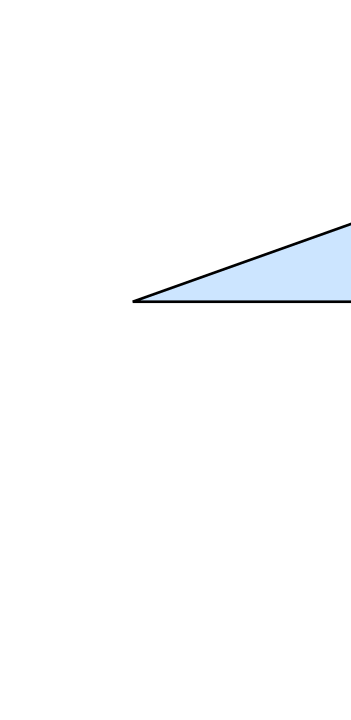


✅ Akış şeması başarıyla oluşturuldu ve 'mbert_akis_semasi.png' adıyla kaydedildi!


In [ ]:
import graphviz
from IPython.display import display

# Şema nesnesini oluştur (Yukarıdan aşağıya doğru akış: TB)
dot = graphviz.Digraph(comment='mBERT Sentiment Analysis Pipeline')
dot.attr(rankdir='TB', size='8,10', dpi='300') # Tez için yüksek çözünürlük (300 dpi)

# --- DÜĞÜMLERİN (NODES) TANIMLANMASI ---
# Başlangıç ve Bitiş (Elips)
dot.node('Start', 'Başlangıç', shape='oval', style='filled', fillcolor='#e0e0e0')
dot.node('End', 'Bitiş', shape='oval', style='filled', fillcolor='#e0e0e0')

# Veri Giriş/Çıkış (Paralelkenar)
dot.node('Data', 'Golden ve TRSA Veri Setlerinin Yüklenmesi', shape='parallelogram', style='filled', fillcolor='#cce5ff')
dot.node('Metrics', 'Accuracy, F1, Precision, Recall Hesaplanması', shape='parallelogram', style='filled', fillcolor='#cce5ff')

# İşlem Adımları (Dikdörtgen)
dot.node('Clean', 'Veri Temizleme & Çakışan Kopyaların Silinmesi', shape='box')
dot.node('Split', 'Train (%72), Validation (%8), Test (%20) Bölünmesi', shape='box')
dot.node('Tokenize', 'mBERT Tokenizer ile Verilerin Kodlanması', shape='box')
dot.node('Setup', 'Model ve Optimizasyon Parametrelerinin Kurulması', shape='box')
dot.node('Train', 'Eğitim Verisi ile İleri/Geri Yayılım', shape='box')
dot.node('Eval', 'Validation Seti ile Değerlendirme', shape='box')
dot.node('Test', 'Test Verisi Üzerinde Final Tahminleri', shape='box')

# Karar ve Döngü Yapıları (Eşkenar Dörtgen / Diamond)
dot.node('Epoch', 'Epoch < 4 mü?', shape='diamond', style='filled', fillcolor='#fff2cc')
dot.node('CheckF1', 'Yeni F1 > En İyi F1?', shape='diamond', style='filled', fillcolor='#fff2cc')
dot.node('CheckPat', 'Patience == 2 mi?', shape='diamond', style='filled', fillcolor='#fff2cc')

# Özel Durum Adımları
dot.node('Save', 'Modeli Kaydet\nSayacı Sıfırla', shape='box', style='filled', fillcolor='#d4edda')
dot.node('Patience', 'Patience Sayacını 1 Artır', shape='box', style='filled', fillcolor='#f8d7da')

# --- BAĞLANTILARIN (EDGES) TANIMLANMASI ---
dot.edge('Start', 'Data')
dot.edge('Data', 'Clean')
dot.edge('Clean', 'Split')
dot.edge('Split', 'Tokenize')
dot.edge('Tokenize', 'Setup')
dot.edge('Setup', 'Epoch')

dot.edge('Epoch', 'Train', label=' Evet')
dot.edge('Train', 'Eval')
dot.edge('Eval', 'CheckF1')

dot.edge('CheckF1', 'Save', label=' Evet')
dot.edge('CheckF1', 'Patience', label=' Hayır')

dot.edge('Save', 'Epoch')
dot.edge('Patience', 'CheckPat')

dot.edge('CheckPat', 'Epoch', label=' Hayır')
dot.edge('CheckPat', 'Test', label=' Evet')

dot.edge('Epoch', 'Test', label=' Hayır')

dot.edge('Test', 'Metrics')
dot.edge('Metrics', 'End')

# Şemayı Colab ekranında göster
display(dot)

# PNG formatında yüksek çözünürlüklü olarak kaydet
dosya_yolu = 'mbert_akis_semasi'
dot.render(dosya_yolu, format='png', cleanup=True)
print(f"\n✅ Akış şeması başarıyla oluşturuldu ve '{dosya_yolu}.png' adıyla kaydedildi!")

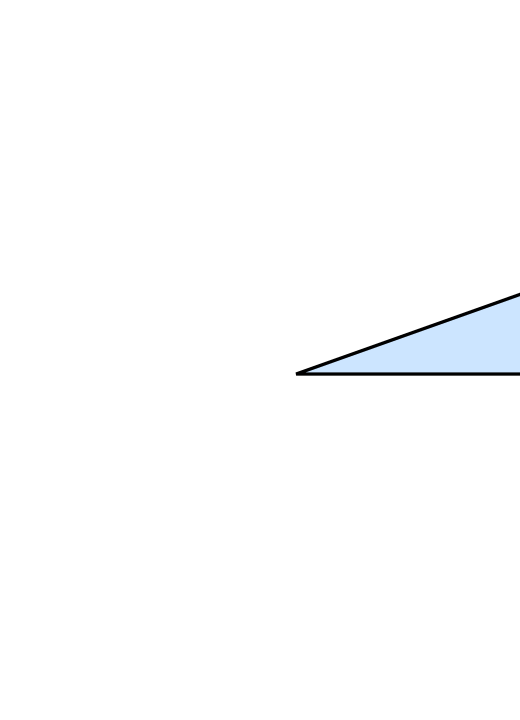


✅ Akış şeması başarıyla oluşturuldu ve 'geleneksel_ml_akis_semasi.png' adıyla kaydedildi!


In [ ]:
import graphviz
from IPython.display import display

# Şema nesnesini oluştur
dot = graphviz.Digraph(comment='Traditional ML Sentiment Pipeline')
dot.attr(rankdir='TB', size='8,10', dpi='300') # Yüksek çözünürlük

# Başlangıç ve Bitiş
dot.node('Start', 'Başlangıç', shape='oval', style='filled', fillcolor='#e0e0e0')
dot.node('End', 'Bitiş', shape='oval', style='filled', fillcolor='#e0e0e0')

# Veri Hazırlığı
dot.node('Data', 'Golden ve TRSA Veri Setlerinin Yüklenmesi', shape='parallelogram', style='filled', fillcolor='#cce5ff')
dot.node('Clean', 'Metin Temizliği\n(URL, Etiket ve Noktalama Silinmesi)', shape='box')
dot.node('Split', 'Train (%72), Validation (%8), Test (%20) Bölünmesi', shape='box')

# Model Döngüsü
dot.node('LoopStart', 'Her Bir Model İçin:\n(LR, SVM, NB, RF)', shape='hexagon', style='filled', fillcolor='#fff2cc')

# Pipeline Adımları
dot.node('TFIDF', 'TF-IDF Vektörizasyonu\n(n-gram: 1-2, sublinear_tf: True)', shape='box')
dot.node('Train', 'Modelin Eğitilmesi (Fit)', shape='box')
dot.node('Predict', 'Validation ve Test Setlerinde Tahmin', shape='box')
dot.node('Eval', 'Performans Metriklerinin Hesaplanması', shape='box')

# Döngü Bitişi ve Raporlama
dot.node('LoopEnd', 'Sonraki Modele Geç', shape='hexagon', style='filled', fillcolor='#fff2cc')
dot.node('Report', 'Modellerin F1 Skoruna Göre Sıralanması ve Raporlanması', shape='parallelogram', style='filled', fillcolor='#d4edda')

# Bağlantılar
dot.edge('Start', 'Data')
dot.edge('Data', 'Clean')
dot.edge('Clean', 'Split')
dot.edge('Split', 'LoopStart')

dot.edge('LoopStart', 'TFIDF')
dot.edge('TFIDF', 'Train')
dot.edge('Train', 'Predict')
dot.edge('Predict', 'Eval')
dot.edge('Eval', 'LoopEnd')

# Döngü geri dönüşü
dot.edge('LoopEnd', 'LoopStart', label=' Modeller bitmediyse')

# Tüm modeller bittikten sonra
dot.edge('LoopEnd', 'Report', label=' Tüm modeller bittiyse')
dot.edge('Report', 'End')

# Şemayı göster ve kaydet
display(dot)
dosya_yolu = 'geleneksel_ml_akis_semasi'
dot.render(dosya_yolu, format='png', cleanup=True)
print(f"\n✅ Akış şeması başarıyla oluşturuldu ve '{dosya_yolu}.png' adıyla kaydedildi!")

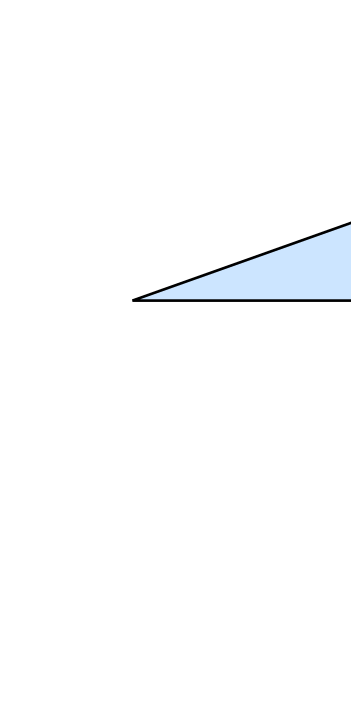


✅ Akış şeması başarıyla oluşturuldu ve 'berturk_akis_semasi.png' adıyla kaydedildi!


In [ ]:
import graphviz
from IPython.display import display

# Şema nesnesini oluştur (Yukarıdan aşağıya doğru akış: TB)
dot = graphviz.Digraph(comment='BERTurk Sentiment Analysis Pipeline')
dot.attr(rankdir='TB', size='8,10', dpi='300') # Tez için yüksek çözünürlük (300 dpi)

# --- DÜĞÜMLERİN (NODES) TANIMLANMASI ---
dot.node('Start', 'Başlangıç', shape='oval', style='filled', fillcolor='#e0e0e0')
dot.node('End', 'Bitiş', shape='oval', style='filled', fillcolor='#e0e0e0')

dot.node('Data', 'Golden ve TRSA Veri Setlerinin Yüklenmesi', shape='parallelogram', style='filled', fillcolor='#cce5ff')
dot.node('Metrics', 'Accuracy, F1, Precision, Recall Hesaplanması', shape='parallelogram', style='filled', fillcolor='#cce5ff')

dot.node('Clean', 'Veri Temizleme & Çakışan Kopyaların Silinmesi\n(Öncelik: Golden Dataset)', shape='box')
dot.node('Split', 'Train (%72), Validation (%8), Test (%20) Bölünmesi', shape='box')
dot.node('Tokenize', 'BERTurk Tokenizer ile Verilerin Kodlanması', shape='box')
dot.node('Setup', 'Model ve Optimizasyon Parametrelerinin Kurulması', shape='box')
dot.node('Train', 'Eğitim Verisi ile İleri/Geri Yayılım', shape='box')
dot.node('Eval', 'Validation Seti ile Değerlendirme', shape='box')
dot.node('Test', 'Test Verisi Üzerinde Final Tahminleri', shape='box')

dot.node('Epoch', 'Epoch < 4 mü?', shape='diamond', style='filled', fillcolor='#fff2cc')
dot.node('CheckF1', 'Yeni F1 > En İyi F1?', shape='diamond', style='filled', fillcolor='#fff2cc')
dot.node('CheckPat', 'Patience == 2 mi?', shape='diamond', style='filled', fillcolor='#fff2cc')

dot.node('Save', 'Modeli Kaydet\nSayacı Sıfırla', shape='box', style='filled', fillcolor='#d4edda')
dot.node('Patience', 'Patience Sayacını 1 Artır', shape='box', style='filled', fillcolor='#f8d7da')

# --- BAĞLANTILARIN (EDGES) TANIMLANMASI ---
dot.edge('Start', 'Data')
dot.edge('Data', 'Clean')
dot.edge('Clean', 'Split')
dot.edge('Split', 'Tokenize')
dot.edge('Tokenize', 'Setup')
dot.edge('Setup', 'Epoch')

dot.edge('Epoch', 'Train', label=' Evet')
dot.edge('Train', 'Eval')
dot.edge('Eval', 'CheckF1')

dot.edge('CheckF1', 'Save', label=' Evet')
dot.edge('CheckF1', 'Patience', label=' Hayır')

dot.edge('Save', 'Epoch')
dot.edge('Patience', 'CheckPat')

dot.edge('CheckPat', 'Epoch', label=' Hayır')
dot.edge('CheckPat', 'Test', label=' Evet')

dot.edge('Epoch', 'Test', label=' Hayır')

dot.edge('Test', 'Metrics')
dot.edge('Metrics', 'End')

# Şemayı Colab ekranında göster
display(dot)

# PNG formatında yüksek çözünürlüklü olarak kaydet
dosya_yolu = 'berturk_akis_semasi'
dot.render(dosya_yolu, format='png', cleanup=True)
print(f"\n✅ Akış şeması başarıyla oluşturuldu ve '{dosya_yolu}.png' adıyla kaydedildi!")

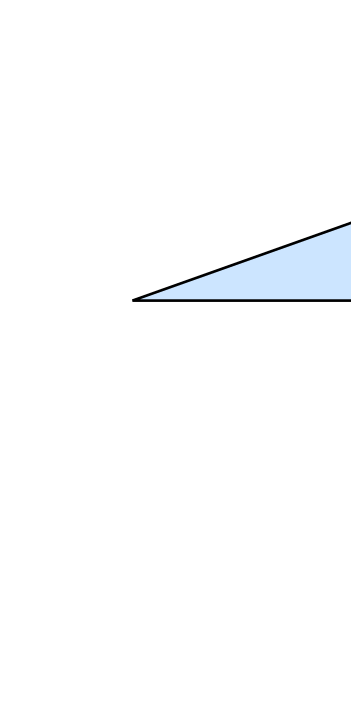


✅ Akış şeması başarıyla oluşturuldu ve 'xlmr_akis_semasi.png' adıyla kaydedildi!


In [ ]:
import graphviz
from IPython.display import display

# Şema nesnesini oluştur (Yukarıdan aşağıya doğru akış: TB)
dot = graphviz.Digraph(comment='XLM-RoBERTa Sentiment Analysis Pipeline')
dot.attr(rankdir='TB', size='8,10', dpi='300') # Tez için yüksek çözünürlük (300 dpi)

# --- DÜĞÜMLERİN (NODES) TANIMLANMASI ---
dot.node('Start', 'Başlangıç', shape='oval', style='filled', fillcolor='#e0e0e0')
dot.node('End', 'Bitiş', shape='oval', style='filled', fillcolor='#e0e0e0')

dot.node('Data', 'Golden ve TRSA Veri Setlerinin Yüklenmesi', shape='parallelogram', style='filled', fillcolor='#cce5ff')
dot.node('Metrics', 'Accuracy, F1, Precision, Recall Hesaplanması', shape='parallelogram', style='filled', fillcolor='#cce5ff')

dot.node('Clean', 'Veri Temizleme & Çakışan Kopyaların Silinmesi\n(Öncelik: Golden Dataset)', shape='box')
dot.node('Split', 'Train (%72), Validation (%8), Test (%20) Bölünmesi', shape='box')
dot.node('Tokenize', 'XLM-R Tokenizer ile Verilerin Kodlanması', shape='box')
dot.node('Setup', 'Model ve Optimizasyon Parametrelerinin Kurulması', shape='box')
dot.node('Train', 'Eğitim Verisi ile İleri/Geri Yayılım', shape='box')
dot.node('Eval', 'Validation Seti ile Değerlendirme', shape='box')
dot.node('Test', 'Test Verisi Üzerinde Final Tahminleri', shape='box')

dot.node('Epoch', 'Epoch < 4 mü?', shape='diamond', style='filled', fillcolor='#fff2cc')
dot.node('CheckF1', 'Yeni F1 > En İyi F1?', shape='diamond', style='filled', fillcolor='#fff2cc')
dot.node('CheckPat', 'Patience == 2 mi?', shape='diamond', style='filled', fillcolor='#fff2cc')

dot.node('Save', 'Modeli Kaydet\nSayacı Sıfırla', shape='box', style='filled', fillcolor='#d4edda')
dot.node('Patience', 'Patience Sayacını 1 Artır', shape='box', style='filled', fillcolor='#f8d7da')

# --- BAĞLANTILARIN (EDGES) TANIMLANMASI ---
dot.edge('Start', 'Data')
dot.edge('Data', 'Clean')
dot.edge('Clean', 'Split')
dot.edge('Split', 'Tokenize')
dot.edge('Tokenize', 'Setup')
dot.edge('Setup', 'Epoch')

dot.edge('Epoch', 'Train', label=' Evet')
dot.edge('Train', 'Eval')
dot.edge('Eval', 'CheckF1')

dot.edge('CheckF1', 'Save', label=' Evet')
dot.edge('CheckF1', 'Patience', label=' Hayır')

dot.edge('Save', 'Epoch')
dot.edge('Patience', 'CheckPat')

dot.edge('CheckPat', 'Epoch', label=' Hayır')
dot.edge('CheckPat', 'Test', label=' Evet')

dot.edge('Epoch', 'Test', label=' Hayır')

dot.edge('Test', 'Metrics')
dot.edge('Metrics', 'End')

# Şemayı Colab ekranında göster
display(dot)

# PNG formatında yüksek çözünürlüklü olarak kaydet
dosya_yolu = 'xlmr_akis_semasi'
dot.render(dosya_yolu, format='png', cleanup=True)
print(f"\n✅ Akış şeması başarıyla oluşturuldu ve '{dosya_yolu}.png' adıyla kaydedildi!")